# 08 Recommendation System - Personalized Recommendation System

## Project Overview

This project builds a personalized recommendation system for an e-commerce platform by combining collaborative filtering and content-based recommendation methods. The system is designed not only to suggest relevant products, but also to support broader business goals such as retention improvement, value growth, and more efficient product exposure.

Unlike a single-algorithm recommendation pipeline, this project develops a hybrid strategy that adapts to different user conditions. It integrates historical interactions, product attributes, user segmentation, churn risk, and predicted customer lifetime value to generate more context-aware recommendations.

## Project Objectives

The main objectives of this project are:

- Build a **user-item rating matrix** using both explicit and implicit feedback
- Implement three recommendation approaches:
  - **User-Based Collaborative Filtering**
  - **Item-Based Collaborative Filtering**
  - **Content-Based Recommendation**
- Design a **hybrid recommendation strategy** for different user types
- Integrate **RFM segmentation**, **churn prediction**, and **CLV prediction**
- Evaluate recommendation quality using offline ranking metrics
- Estimate the potential **business impact** of the recommendation system

## Business Value

A recommendation system can improve the relevance of product exposure and reduce the gap between user demand and platform supply. In business terms, this may contribute to higher click-through rates, better conversion efficiency, stronger repeat purchase behavior, and more balanced traffic allocation across products.

More importantly, recommendation should not be treated as a purely technical ranking problem. Different users carry different business meanings. A high-value user, a churn-risk user, and a cold-start user may require different recommendation logic. This project therefore frames recommendation as both a **modeling task** and a **decision-support task**.

## Technical Challenges

This project addresses several common challenges in recommendation modeling:

- **Data sparsity** in the user-item interaction matrix
- **Cold-start problems** for new users and new products
- The trade-off between **accuracy** and **diversity**
- The limitation of relying on a **single recommendation method**
- The difficulty of aligning algorithm outputs with **business strategy**

These challenges motivate the use of a hybrid recommendation framework rather than a static recommendation pipeline.

## Key Outputs

The final outputs of this project include:

- User-item rating matrix
- User similarity matrix
- Item similarity matrix
- Content feature matrix
- Recommendation results from different algorithms
- Hybrid and personalized recommendation outputs
- Offline evaluation results
- Recommendation analysis visualizations
- Business impact estimation

## Project Position in the Full Analytics System

This project extends the machine learning layer of the broader e-commerce analytics framework. It follows previous modules on user segmentation, churn prediction, and CLV prediction, and transforms those analytical outputs into actionable recommendation decisions.

In this sense, the recommendation system is not an isolated model. It is part of a larger customer intelligence workflow that connects descriptive analysis, predictive modeling, and business intervention.

# 1. Project Overview and Data Preparation

This chapter introduces the recommendation problem and prepares the data foundation for later modeling. In e-commerce, recommendation is not only a ranking task, but also a business decision task, because different users may require different recommendation strategies.

This project builds a recommendation system by combining **User-Based Collaborative Filtering**, **Item-Based Collaborative Filtering**, and **Content-Based Recommendation**. A hybrid strategy is used to better handle **user heterogeneity**, **data sparsity**, and **cold-start scenarios**.

The main objectives of this project are:

- Build a **user-item rating matrix** from explicit and implicit feedback
- Implement and compare three recommendation algorithms
- Design a **hybrid recommendation strategy**
- Integrate **RFM**, **churn prediction**, and **CLV prediction**
- Evaluate recommendation quality and estimate business value

## 1.1 Environment Setup and Library Imports

This section prepares the notebook environment for data loading, matrix construction, similarity calculation, visualization, and recommendation evaluation. Since recommendation data is usually sparse and high-dimensional, the project uses libraries that support efficient computation and reproducible analysis.

In [1]:
# =========================================================
# 1.1 Environment Setup and Library Imports
# =========================================================

import os
import warnings
from datetime import datetime

import numpy as np
import pandas as pd

from scipy.sparse import csr_matrix
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import StandardScaler

import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['axes.labelsize'] = 11

print("Libraries imported successfully.")

Libraries imported successfully.


## 1.2 Data Loading

This section loads the core datasets from the existing database schema. Instead of querying raw CSV-style table names, the project uses the current warehouse tables and analytical views to ensure consistency with previous modules such as RFM, churn prediction, and CLV prediction.

In [2]:
# =========================================================
# 1.2.1 Define Paths and Connect to Database
# =========================================================

project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
output_root = os.path.join(project_root, "output", "08_recommendation_system")

data_dir = os.path.join(output_root, "data")
rec_dir = os.path.join(output_root, "recommendations")
eval_dir = os.path.join(output_root, "evaluation")
viz_dir = os.path.join(output_root, "visualizations")

for folder in [output_root, data_dir, rec_dir, eval_dir, viz_dir]:
    os.makedirs(folder, exist_ok=True)

from src.utils.db import get_engine
engine = get_engine()

print("Project root:", project_root)
print("Output directory ready:", output_root)
print("Database connection created successfully.")

Project root: C:\Users\wangxinxin\Documents\GitHub\E-commerce_decision-making-_intelligence
Output directory ready: C:\Users\wangxinxin\Documents\GitHub\E-commerce_decision-making-_intelligence\output\08_recommendation_system
Database connection created successfully.


In [3]:
# =========================================================
# 1.2.2 Inspect Available Tables and Columns
# =========================================================

schema_query = """
SELECT
    table_name,
    column_name,
    data_type
FROM information_schema.columns
WHERE table_schema = DATABASE()
  AND table_name IN (
      'dim_user',
      'fact_order',
      'fact_order_item',
      'dim_product',
      'fact_review',
      'view_user_behavior',
      'view_product_sales'
  )
ORDER BY table_name, ordinal_position
"""

df_schema = pd.read_sql(schema_query, engine)
df_schema

,TABLE_NAME,COLUMN_NAME,DATA_TYPE
0,dim_product,product_id,varchar
1,dim_product,category,varchar
2,dim_product,weight_g,int
3,dim_product,length_cm,int
4,dim_product,height_cm,int
5,dim_product,width_cm,int
6,dim_user,user_id,varchar
7,dim_user,unique_user_id,varchar
8,dim_user,city,varchar
9,dim_user,state,varchar


In [4]:
# =========================================================
# 1.2.2 Inspect Available Tables and Columns
# =========================================================

schema_query = """
SELECT
    table_name,
    column_name,
    data_type
FROM information_schema.columns
WHERE table_schema = DATABASE()
  AND table_name IN (
      'dim_user',
      'fact_order',
      'fact_order_item',
      'dim_product',
      'fact_review',
      'view_user_behavior',
      'view_product_sales'
  )
ORDER BY table_name, ordinal_position
"""

df_schema = pd.read_sql(schema_query, engine)
df_schema

,TABLE_NAME,COLUMN_NAME,DATA_TYPE
0,dim_product,product_id,varchar
1,dim_product,category,varchar
2,dim_product,weight_g,int
3,dim_product,length_cm,int
4,dim_product,height_cm,int
5,dim_product,width_cm,int
6,dim_user,user_id,varchar
7,dim_user,unique_user_id,varchar
8,dim_user,city,varchar
9,dim_user,state,varchar


In [5]:
# =========================================================
# 1.2.3 Load Interaction Base Data
# =========================================================

query_interactions = """
SELECT
    oi.order_id,
    oi.order_item_id,
    oi.product_id,
    oi.price,
    oi.freight_value,
    oi.gmv,
    o.user_id,
    u.unique_user_id,
    o.order_status,
    o.purchase_ts,
    p.category
FROM fact_order_item oi
JOIN fact_order o
    ON oi.order_id = o.order_id
JOIN dim_user u
    ON o.user_id = u.user_id
LEFT JOIN dim_product p
    ON oi.product_id = p.product_id
WHERE o.order_status = 'delivered'
  AND u.unique_user_id IS NOT NULL
  AND oi.product_id IS NOT NULL
"""

df_interactions = pd.read_sql(query_interactions, engine)
df_interactions['purchase_ts'] = pd.to_datetime(df_interactions['purchase_ts'], errors='coerce')

print("df_interactions shape:", df_interactions.shape)
df_interactions.head()

df_interactions shape: (110197, 11)


,order_id,order_item_id,product_id,price,freight_value,gmv,user_id,unique_user_id,order_status,purchase_ts,category
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,58.90,13.29,72.19,3ce436f183e68e07877b285a838db11a,871766c5855e863f6eccc05f988b23cb,delivered,2017-09-13 08:59:02,cool_stuff
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,239.90,19.93,259.83,f6dd3ec061db4e3987629fe6b26e5cce,eb28e67c4c0b83846050ddfb8a35d051,delivered,2017-04-26 10:53:06,pet_shop
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,199.00,17.87,216.87,6489ae5e4333f3693df5ad4372dab6d3,3818d81c6709e39d06b2738a8d3a2474,delivered,2018-01-14 14:33:31,moveis_decoracao
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,12.99,12.79,25.78,d4eb9395c8c0431ee92fce09860c5a06,af861d436cfc08b2c2ddefd0ba074622,delivered,2018-08-08 10:00:35,perfumaria
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,199.90,18.14,218.04,58dbd0b2d70206bf40e62cd34e84d795,64b576fb70d441e8f1b2d7d446e483c5,delivered,2017-02-04 13:57:51,ferramentas_jardim


In [6]:
# =========================================================
# 1.2.4 Load Product Dimension Data
# =========================================================

query_products = """
SELECT
    product_id,
    category,
    weight_g,
    length_cm,
    height_cm,
    width_cm
FROM dim_product
"""

df_products = pd.read_sql(query_products, engine)

print("df_products shape:", df_products.shape)
df_products.head()

df_products shape: (32951, 6)


,product_id,category,weight_g,length_cm,height_cm,width_cm
0,00066f42aeeb9f3007548bb9d3f33c38,perfumaria,300.0,20.0,16.0,16.0
1,00088930e925c41fd95ebfe695fd2655,automotivo,1225.0,55.0,10.0,26.0
2,0009406fd7479715e4bef61dd91f2462,cama_mesa_banho,300.0,45.0,15.0,35.0
3,000b8f95fcb9e0096488278317764d19,utilidades_domesticas,550.0,19.0,24.0,12.0
4,000d9be29b5207b54e86aa1b1ac54872,relogios_presentes,250.0,22.0,11.0,15.0


In [7]:
# =========================================================
# 1.2.5 Load Review Data
# =========================================================

query_reviews = """
SELECT
    review_id,
    order_id,
    review_score,
    review_comment_len
FROM fact_review
"""

df_reviews = pd.read_sql(query_reviews, engine)

print("df_reviews shape:", df_reviews.shape)
df_reviews.head()

df_reviews shape: (98410, 4)


,review_id,order_id,review_score,review_comment_len
0,0001239bc1de2e33cb583967c2ca4c67,fc046d7776171871436844218f817d7d,5,0
1,0001cc6860aeaf5b9017fe4131a52e62,d4665434b01caa9dc3e3e78b3eb3593e,5,0
2,00020c7512a52e92212f12d3e37513c0,e28abf2eb2f1fbcbdc2dd0cd9a561671,5,69
3,00032b0141443497c898b3093690af51,04fb47576993a3cb0c12d4b25eab6e4e,5,0
4,00034d88989f9a4c393bdcaec301537f,5f358d797a49fe2f24352f73426215f6,5,0


In [8]:
# =========================================================
# 1.2.6 Load Analytical Views and Previous Module Outputs
# =========================================================

query_user_behavior = "SELECT * FROM view_user_behavior"
query_product_sales = "SELECT * FROM view_product_sales"

df_user_behavior = pd.read_sql(query_user_behavior, engine)
df_product_sales = pd.read_sql(query_product_sales, engine)

rfm_path = os.path.join(project_root, "output", "user_segments_rfm.csv")
churn_path = os.path.join(project_root, "output", "06_churn_prediction", "user_churn_scores_latest_user_level.csv")
clv_path = os.path.join(project_root, "output", "07_clv_prediction", "clv_prediction_full_results.csv")

df_rfm = pd.read_csv(rfm_path)
df_churn = pd.read_csv(churn_path)
df_clv = pd.read_csv(clv_path)

print("df_user_behavior shape:", df_user_behavior.shape)
print("df_product_sales shape:", df_product_sales.shape)
print("df_rfm shape:", df_rfm.shape)
print("df_churn shape:", df_churn.shape)
print("df_clv shape:", df_clv.shape)

df_user_behavior shape: (96219, 10)
df_product_sales shape: (32951, 10)
df_rfm shape: (95539, 14)
df_churn shape: (830, 71)
df_clv shape: (13763, 25)


In [9]:
# =========================================================
# 1.2.7 Initial Data Check
# =========================================================

data_summary = pd.DataFrame({
    "dataset": [
        "df_interactions",
        "df_products",
        "df_reviews",
        "df_user_behavior",
        "df_product_sales",
        "df_rfm",
        "df_churn",
        "df_clv"
    ],
    "rows": [
        len(df_interactions),
        len(df_products),
        len(df_reviews),
        len(df_user_behavior),
        len(df_product_sales),
        len(df_rfm),
        len(df_churn),
        len(df_clv)
    ],
    "columns": [
        df_interactions.shape[1],
        df_products.shape[1],
        df_reviews.shape[1],
        df_user_behavior.shape[1],
        df_product_sales.shape[1],
        df_rfm.shape[1],
        df_churn.shape[1],
        df_clv.shape[1]
    ]
})

data_summary

,dataset,rows,columns
0,df_interactions,110197,11
1,df_products,32951,6
2,df_reviews,98410,4
3,df_user_behavior,96219,10
4,df_product_sales,32951,10
5,df_rfm,95539,14
6,df_churn,830,71
7,df_clv,13763,25


## 1.3 Initial Data Exploration

This section provides a first look at the size and structure of the recommendation dataset. The goal is to understand how many users, products, and interactions are available, and to examine the basic distributions that may affect later matrix construction and recommendation performance.

In [10]:
# =========================================================
# 1.3.1 Core Dataset Statistics
# =========================================================

total_users = df_interactions['unique_user_id'].nunique()
total_products = df_interactions['product_id'].nunique()
total_orders = df_interactions['order_id'].nunique()

avg_products_per_user = (
    df_interactions.groupby('unique_user_id')['product_id']
    .nunique()
    .mean()
)

avg_purchases_per_product = (
    df_interactions.groupby('product_id')['order_id']
    .count()
    .mean()
)

summary_stats = pd.DataFrame({
    'metric': [
        'Total users',
        'Total products',
        'Total orders',
        'Average unique products per user',
        'Average purchases per product'
    ],
    'value': [
        total_users,
        total_products,
        total_orders,
        round(avg_products_per_user, 2),
        round(avg_purchases_per_product, 2)
    ]
})

summary_stats

,metric,value
0,Total users,93358.00
1,Total products,32216.00
2,Total orders,96478.00
3,Average unique products per user,1.07
4,Average purchases per product,3.42


In [11]:
# =========================================================
# 1.3.2 Rating Distribution from Reviews
# =========================================================

rating_dist = (
    df_reviews['review_score']
    .value_counts(dropna=False)
    .sort_index()
    .reset_index()
)

rating_dist.columns = ['review_score', 'count']
rating_dist['share'] = rating_dist['count'] / rating_dist['count'].sum()

rating_dist

,review_score,count,share
0,1,11282,0.114643
1,2,3114,0.031643
2,3,8097,0.082278
3,4,19007,0.193141
4,5,56910,0.578295


In [12]:
# =========================================================
# 1.3.3 Purchase Frequency Distribution
# =========================================================

purchase_freq_dist = (
    df_user_behavior['order_count']
    .value_counts()
    .sort_index()
    .reset_index()
)

purchase_freq_dist.columns = ['order_count', 'user_count']
purchase_freq_dist['share'] = purchase_freq_dist['user_count'] / purchase_freq_dist['user_count'].sum()

purchase_freq_dist.head(15)

,order_count,user_count,share
0,1,93333,0.970006
1,2,2644,0.027479
2,3,195,0.002027
3,4,28,0.000291
4,5,8,0.000083
5,6,6,0.000062
6,7,3,0.000031
7,9,1,0.000010
8,17,1,0.000010


In [13]:
# =========================================================
# 1.3.4 Product Category Distribution
# =========================================================

category_dist = (
    df_interactions['category']
    .fillna('Unknown')
    .value_counts()
    .reset_index()
)

category_dist.columns = ['category', 'interaction_count']
category_dist['share'] = category_dist['interaction_count'] / category_dist['interaction_count'].sum()

category_dist.head(15)

,category,interaction_count,share
0,cama_mesa_banho,10953,0.099395
1,beleza_saude,9465,0.085892
2,esporte_lazer,8431,0.076508
3,moveis_decoracao,8160,0.074049
4,informatica_acessorios,7644,0.069367
5,utilidades_domesticas,6795,0.061662
6,relogios_presentes,5859,0.053168
7,telefonia,4430,0.040201
8,ferramentas_jardim,4268,0.038731
9,automotivo,4140,0.037569


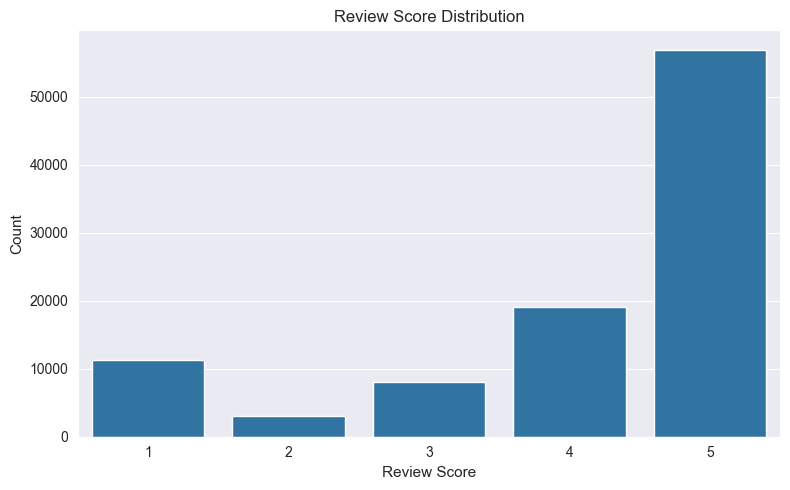

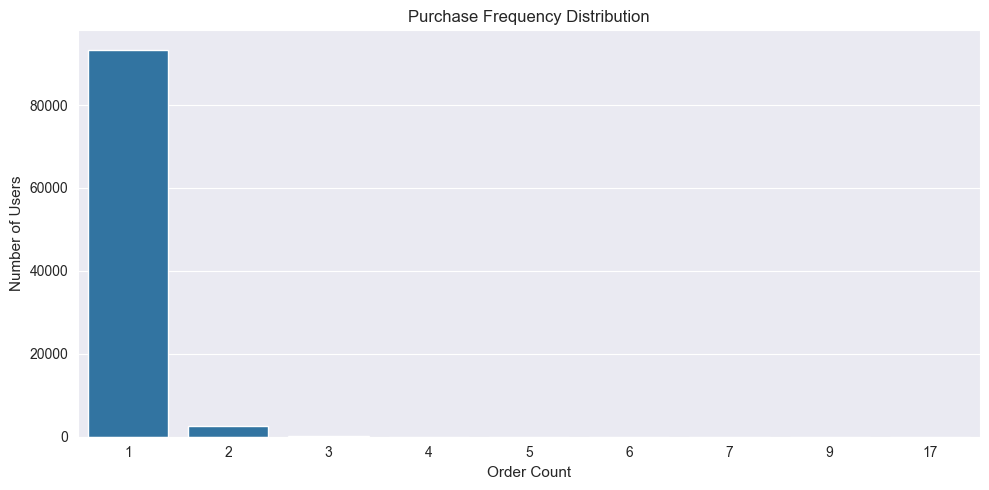

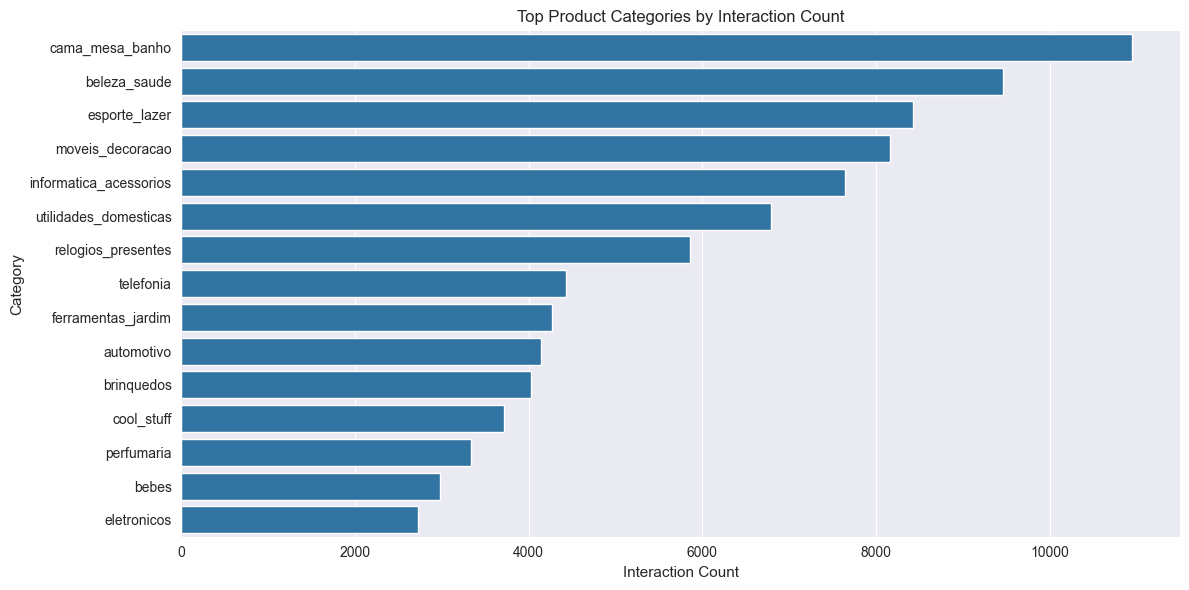

In [14]:
# =========================================================
# 1.3.5 Basic Distribution Plots
# =========================================================

# Review score distribution
plt.figure(figsize=(8, 5))
sns.barplot(data=rating_dist, x='review_score', y='count')
plt.title('Review Score Distribution')
plt.xlabel('Review Score')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig(os.path.join(viz_dir, '01_review_score_distribution.png'), dpi=300)
plt.show()

# Purchase frequency distribution (top 15 order_count values)
plot_purchase_freq = purchase_freq_dist.head(15)

plt.figure(figsize=(10, 5))
sns.barplot(data=plot_purchase_freq, x='order_count', y='user_count')
plt.title('Purchase Frequency Distribution')
plt.xlabel('Order Count')
plt.ylabel('Number of Users')
plt.tight_layout()
plt.savefig(os.path.join(viz_dir, '02_purchase_frequency_distribution.png'), dpi=300)
plt.show()

# Top 15 product categories by interaction count
plot_category_dist = category_dist.head(15)

plt.figure(figsize=(12, 6))
sns.barplot(data=plot_category_dist, x='interaction_count', y='category')
plt.title('Top Product Categories by Interaction Count')
plt.xlabel('Interaction Count')
plt.ylabel('Category')
plt.tight_layout()
plt.savefig(os.path.join(viz_dir, '03_category_distribution.png'), dpi=300)
plt.show()

In [15]:
# =========================================================
# 1.3.6 Missing Value Check for Key Fields
# =========================================================

missing_check = pd.DataFrame({
    'column': [
        'unique_user_id',
        'product_id',
        'purchase_ts',
        'category',
        'review_score'
    ],
    'missing_count': [
        df_interactions['unique_user_id'].isna().sum(),
        df_interactions['product_id'].isna().sum(),
        df_interactions['purchase_ts'].isna().sum(),
        df_interactions['category'].isna().sum(),
        df_reviews['review_score'].isna().sum()
    ]
})

missing_check['missing_rate'] = missing_check['missing_count'] / [
    len(df_interactions),
    len(df_interactions),
    len(df_interactions),
    len(df_interactions),
    len(df_reviews)
]

missing_check

,column,missing_count,missing_rate
0,unique_user_id,0,0.000000
1,product_id,0,0.000000
2,purchase_ts,0,0.000000
3,category,1537,0.013948
4,review_score,0,0.000000


## Initial Data Exploration Analysis and Summary

The exploratory results show that the recommendation dataset is large in scale but limited in interaction depth. Although the project includes **93,358 users** and **32,216 products**, the average number of unique products per user is only **1.07**, which suggests that most users have very limited purchase history.

The review distribution is highly concentrated at the positive end. Ratings of **4** and **5** dominate the dataset, especially **5-star reviews**, which indicates that explicit feedback is available but not highly balanced across rating levels.

The purchase frequency distribution confirms a strong sparsity problem. About **97%** of users placed only **one order**, which means collaborative filtering alone may be insufficient for many users and cold-start handling will be important.

Product interactions are also concentrated in several major categories, such as **cama_mesa_banho** and **beleza_saude**. In addition, missing values are minimal, with only a small proportion of missing category information.

Overall, the data is suitable for recommendation modeling, but the results suggest that a **hybrid strategy** will be more appropriate than relying on a single method.

# 2. User-Item Rating Matrix Construction

This chapter constructs the rating foundation for the recommendation system. Since user-product interactions are sparse, the project combines explicit and implicit signals to build a more informative user-item matrix for later recommendation modeling.

## 2.1 Explicit Rating Construction

This section uses `review_score` as the explicit feedback signal. Since reviews are recorded at the order level, the data needs to be matched back to user-product interactions before constructing user-item ratings.

In [16]:
# =========================================================
# 2.1.1 Merge Review Scores into Interaction Data
# =========================================================

df_explicit = df_interactions.merge(
    df_reviews[['order_id', 'review_score']],
    on='order_id',
    how='left'
)

print("df_explicit shape:", df_explicit.shape)
df_explicit.head()

df_explicit shape: (110570, 12)


,order_id,order_item_id,product_id,price,freight_value,gmv,user_id,unique_user_id,order_status,purchase_ts,category,review_score
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,58.90,13.29,72.19,3ce436f183e68e07877b285a838db11a,871766c5855e863f6eccc05f988b23cb,delivered,2017-09-13 08:59:02,cool_stuff,5.0
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,239.90,19.93,259.83,f6dd3ec061db4e3987629fe6b26e5cce,eb28e67c4c0b83846050ddfb8a35d051,delivered,2017-04-26 10:53:06,pet_shop,4.0
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,199.00,17.87,216.87,6489ae5e4333f3693df5ad4372dab6d3,3818d81c6709e39d06b2738a8d3a2474,delivered,2018-01-14 14:33:31,moveis_decoracao,5.0
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,12.99,12.79,25.78,d4eb9395c8c0431ee92fce09860c5a06,af861d436cfc08b2c2ddefd0ba074622,delivered,2018-08-08 10:00:35,perfumaria,4.0
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,199.90,18.14,218.04,58dbd0b2d70206bf40e62cd34e84d795,64b576fb70d441e8f1b2d7d446e483c5,delivered,2017-02-04 13:57:51,ferramentas_jardim,5.0


In [17]:
# =========================================================
# 2.1.2 Keep Valid Explicit Ratings
# =========================================================

df_explicit_valid = df_explicit[
    df_explicit['review_score'].notna()
].copy()

df_explicit_valid['review_score'] = df_explicit_valid['review_score'].astype(float)

print("df_explicit_valid shape:", df_explicit_valid.shape)
print("Unique users with explicit ratings:", df_explicit_valid['unique_user_id'].nunique())
print("Unique products with explicit ratings:", df_explicit_valid['product_id'].nunique())

df_explicit_valid shape: (109108, 12)
Unique users with explicit ratings: 92719
Unique products with explicit ratings: 31947


In [18]:
# =========================================================
# 2.1.3 Aggregate Repeated Purchases at User-Product Level
# =========================================================

explicit_user_product = (
    df_explicit_valid
    .groupby(['unique_user_id', 'product_id'], as_index=False)
    .agg(
        explicit_rating=('review_score', 'mean'),
        explicit_rating_count=('review_score', 'count')
    )
)

print("explicit_user_product shape:", explicit_user_product.shape)
explicit_user_product.head()

explicit_user_product shape: (98569, 4)


,unique_user_id,product_id,explicit_rating,explicit_rating_count
0,0000366f3b9a7992bf8c76cfdf3221e2,372645c7439f9661fbbacfd129aa92ec,5.0,1
1,0000b849f77a49e4a4ce2b2a4ca5be3f,5099f7000472b634fea8304448d20825,4.0,1
2,0000f46a3911fa3c0805444483337064,64b488de448a5324c4134ea39c28a34b,3.0,1
3,0000f6ccb0745a6a4b88665a16c9f078,2345a354a6f2033609bbf62bf5be9ef6,4.0,1
4,0004aac84e0df4da2b147fca70cf8255,c72e18b3fe2739b8d24ebf3102450f37,5.0,1


In [19]:
# =========================================================
# 2.1.4 Check Explicit Rating Distribution After Aggregation
# =========================================================

explicit_rating_dist = (
    explicit_user_product['explicit_rating']
    .round(2)
    .describe()
)

explicit_rating_dist

count    98569.000000
mean         4.127906
std          1.307397
min          1.000000
25%          4.000000
50%          5.000000
75%          5.000000
max          5.000000
Name: explicit_rating, dtype: float64

In [20]:
# =========================================================
# 2.1.5 Save Explicit Rating Table
# =========================================================

explicit_path = os.path.join(data_dir, "explicit_user_product_ratings.csv")
explicit_user_product.to_csv(explicit_path, index=False)

print("Saved:", explicit_path)

Saved: C:\Users\wangxinxin\Documents\GitHub\E-commerce_decision-making-_intelligence\output\08_recommendation_system\data\explicit_user_product_ratings.csv


## Explicit Rating Construction Analysis and Summary

Explicit ratings provide broad coverage across users and products, with **98,569** user-product pairs after aggregation. This means review-based feedback is usable as a direct preference signal.

However, the ratings are strongly concentrated at the high end, with an average of **4.13** and a median of **5.0**. This suggests that explicit feedback reflects satisfaction, but may be less effective for separating moderate preference from strong preference. For this reason, implicit signals should be added in the next step.

## 2.2 Implicit Rating Construction

This section builds implicit ratings from behavioral signals. Since many users do not provide explicit reviews, purchase frequency and spending amount are used to capture preference strength at the user-product level.

In [21]:
# =========================================================
# 2.2.1 Build User-Product Purchase Signals
# =========================================================

implicit_user_product = (
    df_interactions
    .groupby(['unique_user_id', 'product_id'], as_index=False)
    .agg(
        purchase_count=('order_id', 'count'),
        total_spent=('gmv', 'sum'),
        avg_price=('gmv', 'mean')
    )
)

print("implicit_user_product shape:", implicit_user_product.shape)
implicit_user_product.head()

implicit_user_product shape: (99785, 5)


,unique_user_id,product_id,purchase_count,total_spent,avg_price
0,0000366f3b9a7992bf8c76cfdf3221e2,372645c7439f9661fbbacfd129aa92ec,1,141.90,141.90
1,0000b849f77a49e4a4ce2b2a4ca5be3f,5099f7000472b634fea8304448d20825,1,27.19,27.19
2,0000f46a3911fa3c0805444483337064,64b488de448a5324c4134ea39c28a34b,1,86.22,86.22
3,0000f6ccb0745a6a4b88665a16c9f078,2345a354a6f2033609bbf62bf5be9ef6,1,43.62,43.62
4,0004aac84e0df4da2b147fca70cf8255,c72e18b3fe2739b8d24ebf3102450f37,1,196.89,196.89


In [22]:
# =========================================================
# 2.2.2 Normalize Purchase Count with Log Scaling
# =========================================================

implicit_user_product['purchase_count_log'] = np.log1p(implicit_user_product['purchase_count'])

count_log_min = implicit_user_product['purchase_count_log'].min()
count_log_max = implicit_user_product['purchase_count_log'].max()

if count_log_max == count_log_min:
    implicit_user_product['count_rating'] = 3.0
else:
    implicit_user_product['count_rating'] = 1 + 4 * (
        (implicit_user_product['purchase_count_log'] - count_log_min) /
        (count_log_max - count_log_min)
    )

implicit_user_product[['purchase_count', 'purchase_count_log', 'count_rating']].head()

,purchase_count,purchase_count_log,count_rating
0,1,0.693147,1.0
1,1,0.693147,1.0
2,1,0.693147,1.0
3,1,0.693147,1.0
4,1,0.693147,1.0


In [23]:
# =========================================================
# 2.2.3 Normalize Spending Amount with Log Scaling
# =========================================================

implicit_user_product['total_spent_log'] = np.log1p(implicit_user_product['total_spent'])

spend_log_min = implicit_user_product['total_spent_log'].min()
spend_log_max = implicit_user_product['total_spent_log'].max()

if spend_log_max == spend_log_min:
    implicit_user_product['spend_rating'] = 3.0
else:
    implicit_user_product['spend_rating'] = 1 + 4 * (
        (implicit_user_product['total_spent_log'] - spend_log_min) /
        (spend_log_max - spend_log_min)
    )

implicit_user_product[['total_spent', 'total_spent_log', 'spend_rating']].head()

,total_spent,total_spent_log,spend_rating
0,141.90,4.962145,2.537803
1,27.19,3.338967,1.661447
2,86.22,4.468434,2.271248
3,43.62,3.798182,1.909378
4,196.89,5.287711,2.713577


In [24]:
# =========================================================
# 2.2.4 Combine Implicit Signals
# =========================================================

implicit_user_product['implicit_rating'] = (
    0.4 * implicit_user_product['count_rating'] +
    0.6 * implicit_user_product['spend_rating']
)

implicit_rating_dist = implicit_user_product['implicit_rating'].describe()
implicit_rating_dist

count    99785.000000
mean         1.851745
std          0.290409
min          1.000000
25%          1.651298
50%          1.825276
75%          2.007603
max          4.651278
Name: implicit_rating, dtype: float64

In [25]:
# =========================================================
# 2.2.5 Save Implicit Rating Table
# =========================================================

implicit_path = os.path.join(data_dir, "implicit_user_product_ratings.csv")
implicit_user_product.to_csv(implicit_path, index=False)

print("Saved:", implicit_path)

Saved: C:\Users\wangxinxin\Documents\GitHub\E-commerce_decision-making-_intelligence\output\08_recommendation_system\data\implicit_user_product_ratings.csv


## Implicit Rating Construction Analysis and Summary

The implicit rating table covers **99,785** user-product pairs and extends the preference signal beyond review data. After log scaling, the score distribution becomes more informative and less compressed near the lower bound.

At the same time, the results also show that **purchase frequency contributes little variation**, because most users purchased only once. In this dataset, spending-based behavior is more useful than frequency for implicit preference construction.
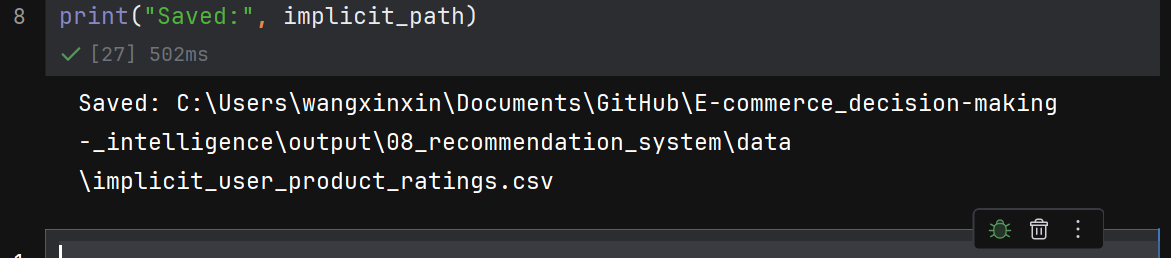
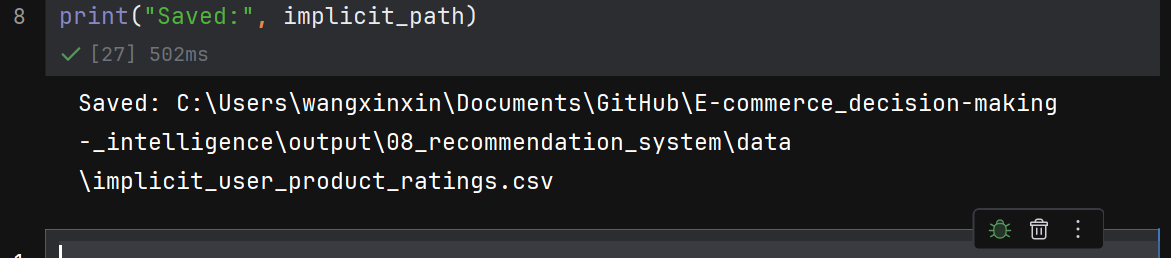

## 2.3 Combine Explicit and Implicit Ratings

This section combines explicit and implicit ratings into a unified user-product score. If both signals are available, explicit feedback is given higher weight because it directly reflects customer evaluation. If explicit feedback is missing, the model falls back on implicit behavior-based signals.

In [26]:
# =========================================================
# 2.3.1 Merge Explicit and Implicit Ratings
# =========================================================

df_ratings = implicit_user_product.merge(
    explicit_user_product[['unique_user_id', 'product_id', 'explicit_rating']],
    on=['unique_user_id', 'product_id'],
    how='left'
)

print("df_ratings shape:", df_ratings.shape)
df_ratings.head()

df_ratings shape: (99785, 11)


,unique_user_id,product_id,purchase_count,total_spent,avg_price,purchase_count_log,count_rating,total_spent_log,spend_rating,implicit_rating,explicit_rating
0,0000366f3b9a7992bf8c76cfdf3221e2,372645c7439f9661fbbacfd129aa92ec,1,141.90,141.90,0.693147,1.0,4.962145,2.537803,1.922682,5.0
1,0000b849f77a49e4a4ce2b2a4ca5be3f,5099f7000472b634fea8304448d20825,1,27.19,27.19,0.693147,1.0,3.338967,1.661447,1.396868,4.0
2,0000f46a3911fa3c0805444483337064,64b488de448a5324c4134ea39c28a34b,1,86.22,86.22,0.693147,1.0,4.468434,2.271248,1.762749,3.0
3,0000f6ccb0745a6a4b88665a16c9f078,2345a354a6f2033609bbf62bf5be9ef6,1,43.62,43.62,0.693147,1.0,3.798182,1.909378,1.545627,4.0
4,0004aac84e0df4da2b147fca70cf8255,c72e18b3fe2739b8d24ebf3102450f37,1,196.89,196.89,0.693147,1.0,5.287711,2.713577,2.028146,5.0


In [27]:
# =========================================================
# 2.3.2 Create Final Combined Rating
# =========================================================

df_ratings['final_rating'] = np.where(
    df_ratings['explicit_rating'].notna(),
    0.7 * df_ratings['explicit_rating'] + 0.3 * df_ratings['implicit_rating'],
    df_ratings['implicit_rating']
)

df_ratings[['explicit_rating', 'implicit_rating', 'final_rating']].head()

,explicit_rating,implicit_rating,final_rating
0,5.0,1.922682,4.076805
1,4.0,1.396868,3.219060
2,3.0,1.762749,2.628825
3,4.0,1.545627,3.263688
4,5.0,2.028146,4.108444


In [28]:
# =========================================================
# 2.3.3 Check Final Rating Distribution
# =========================================================

final_rating_dist = df_ratings['final_rating'].describe()
final_rating_dist

count    99785.000000
mean         3.425769
std          0.926164
min          1.042485
25%          3.255726
50%          3.963448
75%          4.059304
max          4.706749
Name: final_rating, dtype: float64

In [29]:
# =========================================================
# 2.3.4 Check Signal Coverage
# =========================================================

rating_coverage = pd.DataFrame({
    'metric': [
        'Total user-product pairs',
        'Pairs with explicit rating',
        'Pairs without explicit rating',
        'Explicit coverage rate'
    ],
    'value': [
        len(df_ratings),
        df_ratings['explicit_rating'].notna().sum(),
        df_ratings['explicit_rating'].isna().sum(),
        round(df_ratings['explicit_rating'].notna().mean(), 4)
    ]
})

rating_coverage

,metric,value
0,Total user-product pairs,99785.0000
1,Pairs with explicit rating,98569.0000
2,Pairs without explicit rating,1216.0000
3,Explicit coverage rate,0.9878


In [30]:
# =========================================================
# 2.3.5 Keep Final Rating Table
# =========================================================

rating_cols = [
    'unique_user_id',
    'product_id',
    'purchase_count',
    'total_spent',
    'implicit_rating',
    'explicit_rating',
    'final_rating'
]

df_ratings_final = df_ratings[rating_cols].copy()

print("df_ratings_final shape:", df_ratings_final.shape)
df_ratings_final.head()

df_ratings_final shape: (99785, 7)


,unique_user_id,product_id,purchase_count,total_spent,implicit_rating,explicit_rating,final_rating
0,0000366f3b9a7992bf8c76cfdf3221e2,372645c7439f9661fbbacfd129aa92ec,1,141.90,1.922682,5.0,4.076805
1,0000b849f77a49e4a4ce2b2a4ca5be3f,5099f7000472b634fea8304448d20825,1,27.19,1.396868,4.0,3.219060
2,0000f46a3911fa3c0805444483337064,64b488de448a5324c4134ea39c28a34b,1,86.22,1.762749,3.0,2.628825
3,0000f6ccb0745a6a4b88665a16c9f078,2345a354a6f2033609bbf62bf5be9ef6,1,43.62,1.545627,4.0,3.263688
4,0004aac84e0df4da2b147fca70cf8255,c72e18b3fe2739b8d24ebf3102450f37,1,196.89,2.028146,5.0,4.108444


In [31]:
# =========================================================
# 2.3.6 Save Final Rating Table
# =========================================================

final_rating_path = os.path.join(data_dir, "user_product_final_ratings.csv")
df_ratings_final.to_csv(final_rating_path, index=False)

print("Saved:", final_rating_path)

Saved: C:\Users\wangxinxin\Documents\GitHub\E-commerce_decision-making-_intelligence\output\08_recommendation_system\data\user_product_final_ratings.csv


## Combine Explicit and Implicit Ratings Analysis and Summary

The combined rating table contains **99,785** user-product pairs, and explicit feedback covers **98.78%** of them. This means the final rating matrix is still mainly anchored in review-based evaluation, while implicit signals fill a small but useful gap.

The final rating distribution is more balanced than the original explicit or implicit signals alone. This suggests that the fusion step improves score stability and makes the rating matrix more suitable for later similarity-based recommendation modeling.

## 2.4 Build User-Item Matrix

This section transforms the final rating table into a user-item matrix. This matrix is the core input for collaborative filtering and will later be converted into sparse format for more efficient computation.
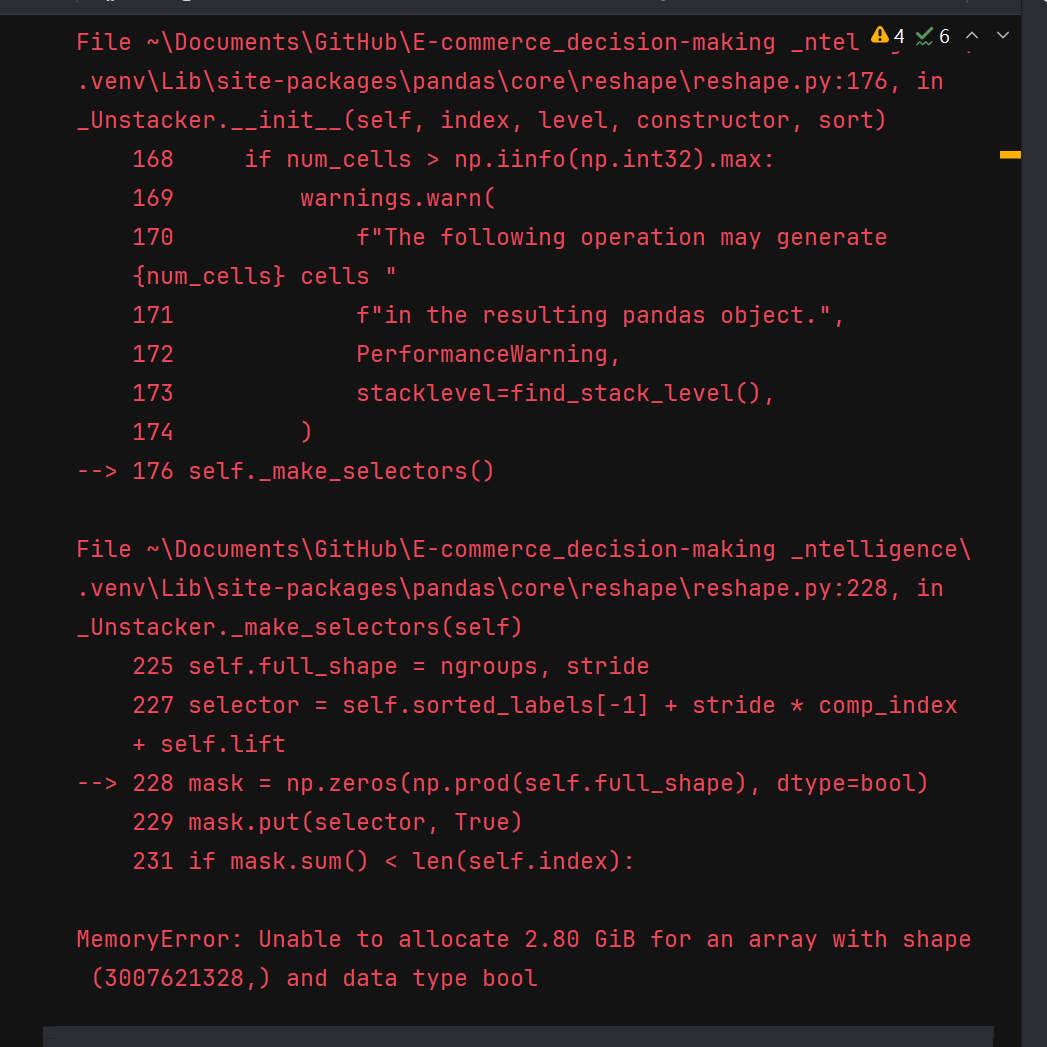
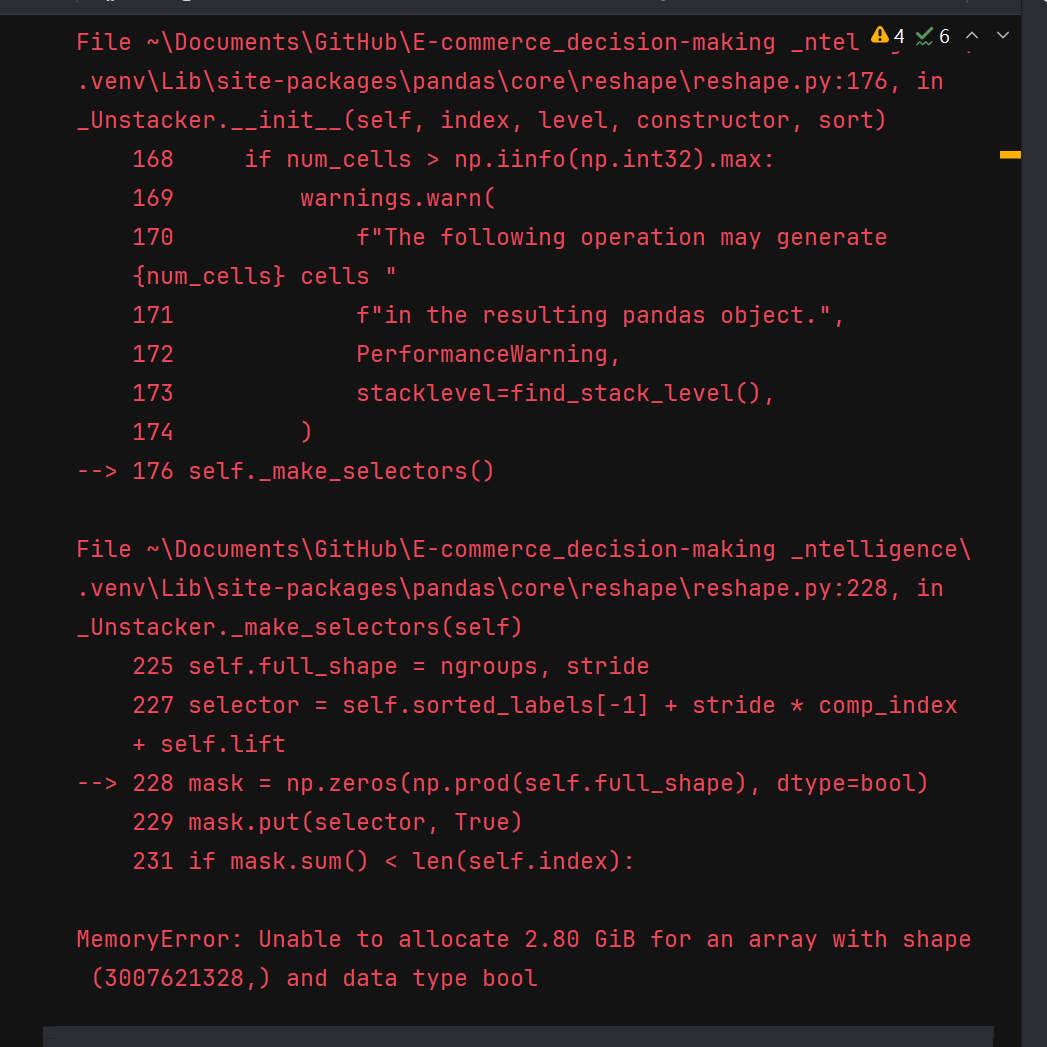
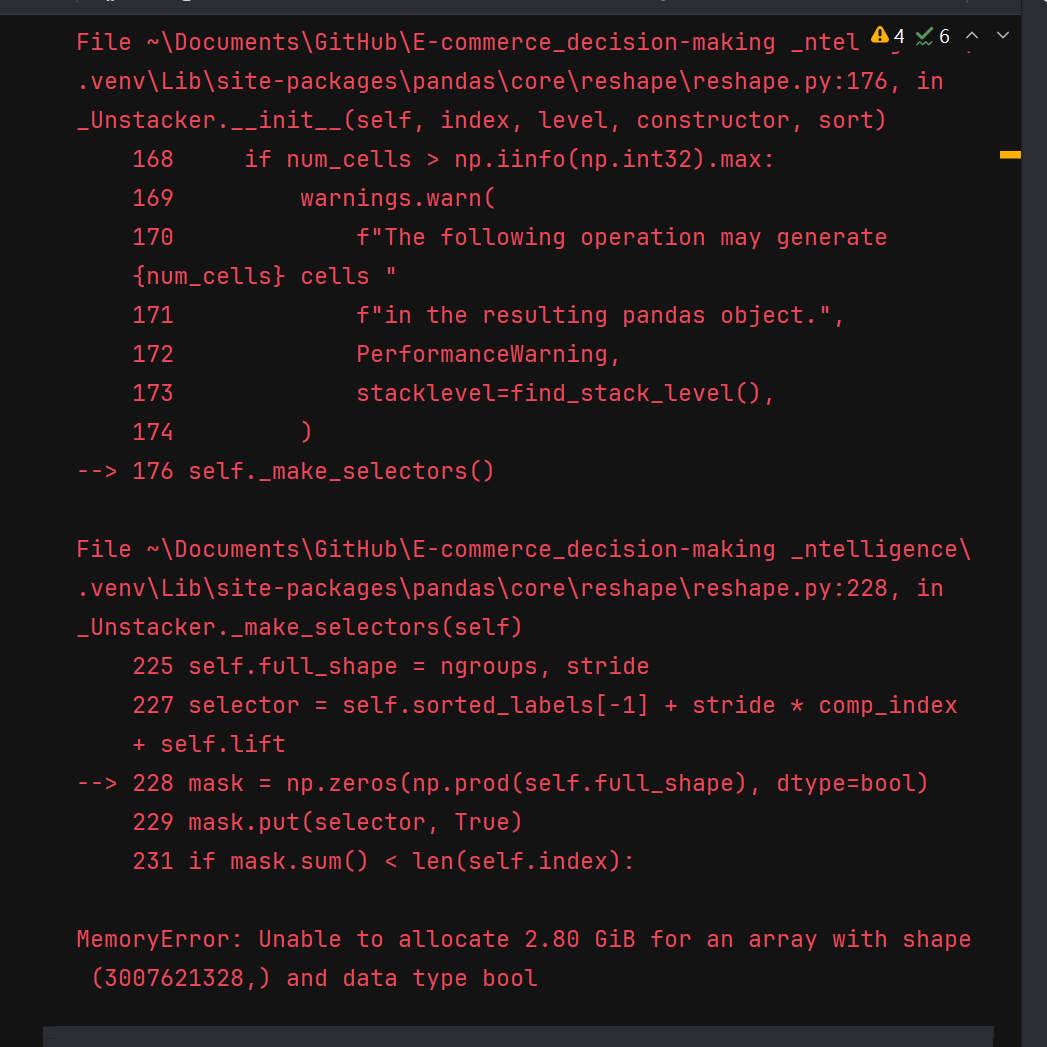
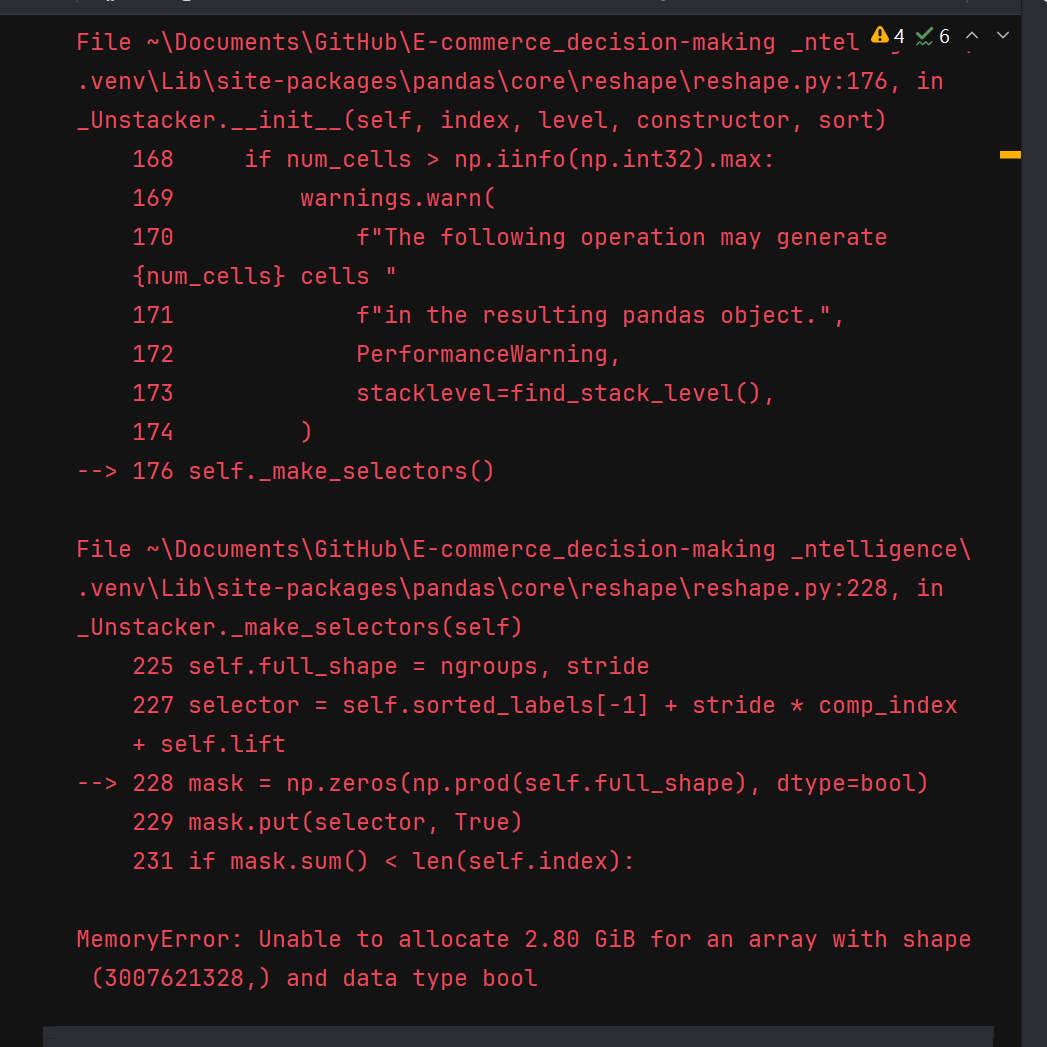

In [32]:
# =========================================================
# 2.4.1 Prepare Row and Column Indices
# =========================================================

df_sparse_input = df_ratings_final[['unique_user_id', 'product_id', 'final_rating']].copy()

df_sparse_input['user_idx'] = df_sparse_input['unique_user_id'].astype('category').cat.codes
df_sparse_input['item_idx'] = df_sparse_input['product_id'].astype('category').cat.codes

user_index = (
    df_sparse_input[['unique_user_id', 'user_idx']]
    .drop_duplicates()
    .sort_values('user_idx')
    .reset_index(drop=True)
)

item_index = (
    df_sparse_input[['product_id', 'item_idx']]
    .drop_duplicates()
    .sort_values('item_idx')
    .reset_index(drop=True)
)

num_users = user_index.shape[0]
num_items = item_index.shape[0]

print("Number of users:", num_users)
print("Number of items:", num_items)

df_sparse_input.head()

Number of users: 93358
Number of items: 32216


,unique_user_id,product_id,final_rating,user_idx,item_idx
0,0000366f3b9a7992bf8c76cfdf3221e2,372645c7439f9661fbbacfd129aa92ec,4.076805,0,7003
1,0000b849f77a49e4a4ce2b2a4ca5be3f,5099f7000472b634fea8304448d20825,3.219060,1,10224
2,0000f46a3911fa3c0805444483337064,64b488de448a5324c4134ea39c28a34b,2.628825,2,12712
3,0000f6ccb0745a6a4b88665a16c9f078,2345a354a6f2033609bbf62bf5be9ef6,3.263688,3,4576
4,0004aac84e0df4da2b147fca70cf8255,c72e18b3fe2739b8d24ebf3102450f37,4.108444,4,25060


In [33]:
# =========================================================
# 2.4.2 Build Sparse Matrix Directly
# =========================================================

user_item_sparse = csr_matrix(
    (
        df_sparse_input['final_rating'].values,
        (df_sparse_input['user_idx'].values, df_sparse_input['item_idx'].values)
    ),
    shape=(num_users, num_items)
)

print("Sparse matrix shape:", user_item_sparse.shape)
print("Number of non-zero entries:", user_item_sparse.nnz)

Sparse matrix shape: (93358, 32216)
Number of non-zero entries: 99785


In [34]:
from scipy.sparse import csr_matrix, save_npz

In [35]:
# =========================================================
# 2.4.3 Save Sparse Matrix and Index Mapping
# =========================================================

sparse_matrix_path = os.path.join(data_dir, "user_item_sparse_matrix.npz")
user_index_path = os.path.join(data_dir, "user_index_map.csv")
item_index_path = os.path.join(data_dir, "item_index_map.csv")

save_npz(sparse_matrix_path, user_item_sparse)
user_index.to_csv(user_index_path, index=False)
item_index.to_csv(item_index_path, index=False)

print("Saved sparse matrix:", sparse_matrix_path)
print("Saved user index map:", user_index_path)
print("Saved item index map:", item_index_path)

Saved sparse matrix: C:\Users\wangxinxin\Documents\GitHub\E-commerce_decision-making-_intelligence\output\08_recommendation_system\data\user_item_sparse_matrix.npz
Saved user index map: C:\Users\wangxinxin\Documents\GitHub\E-commerce_decision-making-_intelligence\output\08_recommendation_system\data\user_index_map.csv
Saved item index map: C:\Users\wangxinxin\Documents\GitHub\E-commerce_decision-making-_intelligence\output\08_recommendation_system\data\item_index_map.csv


## 2.5 Matrix Sparsity Analysis

This section evaluates the sparsity of the user-item matrix in sparse format. High sparsity is expected in recommendation systems and is an important reason for using hybrid recommendation instead of relying on a single collaborative filtering method.

In [36]:
# =========================================================
# 2.5.1 Calculate Sparsity
# =========================================================

total_cells = num_users * num_items
non_zero_cells = user_item_sparse.nnz
sparsity = 1 - (non_zero_cells / total_cells)

print(f"Number of users: {num_users:,}")
print(f"Number of items: {num_items:,}")
print(f"Non-zero entries: {non_zero_cells:,}")
print(f"Sparsity: {sparsity:.6f}")

Number of users: 93,358
Number of items: 32,216
Non-zero entries: 99,785
Sparsity: 0.999967


In [37]:
# =========================================================
# 2.5.2 User Interaction Count Distribution
# =========================================================

user_rated_count = pd.DataFrame({
    'user_idx': np.arange(num_users),
    'rated_product_count': user_item_sparse.getnnz(axis=1)
})

user_rated_count['rated_product_count'].describe()

count    93358.000000
mean         1.068843
std          0.316919
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max         14.000000
Name: rated_product_count, dtype: float64

In [38]:
# =========================================================
# 2.5.3 Item Interaction Count Distribution
# =========================================================

item_rated_count = pd.DataFrame({
    'item_idx': np.arange(num_items),
    'rated_user_count': user_item_sparse.getnnz(axis=0)
})

item_rated_count['rated_user_count'].describe()

count    32216.000000
mean         3.097374
std          9.366386
min          1.000000
25%          1.000000
50%          1.000000
75%          2.000000
max        456.000000
Name: rated_user_count, dtype: float64

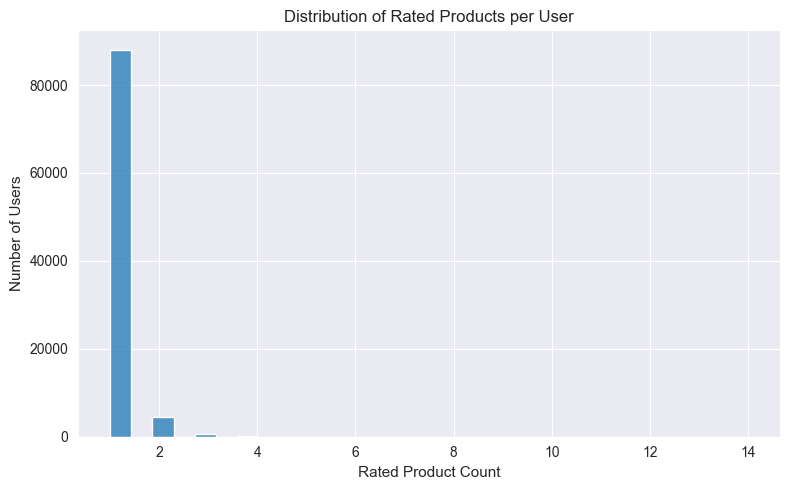

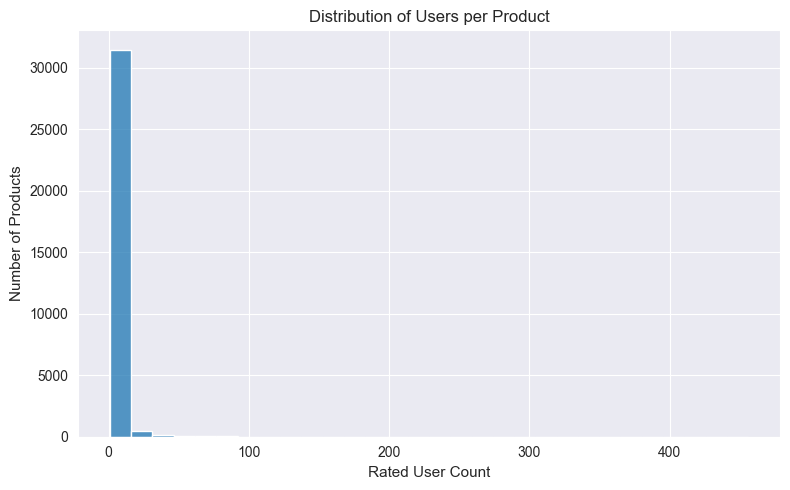

In [39]:
# =========================================================
# 2.5.4 Plot Sparsity-Related Distributions
# =========================================================

plt.figure(figsize=(8, 5))
sns.histplot(user_rated_count['rated_product_count'], bins=30)
plt.title('Distribution of Rated Products per User')
plt.xlabel('Rated Product Count')
plt.ylabel('Number of Users')
plt.tight_layout()
plt.savefig(os.path.join(viz_dir, '04_user_rated_product_distribution.png'), dpi=300)
plt.show()

plt.figure(figsize=(8, 5))
sns.histplot(item_rated_count['rated_user_count'], bins=30)
plt.title('Distribution of Users per Product')
plt.xlabel('Rated User Count')
plt.ylabel('Number of Products')
plt.tight_layout()
plt.savefig(os.path.join(viz_dir, '05_product_rated_user_distribution.png'), dpi=300)
plt.show()

In [40]:
# =========================================================
# 2.5.5 Save Sparsity Summary
# =========================================================

sparsity_summary = pd.DataFrame({
    'metric': [
        'Number of users',
        'Number of products',
        'Non-zero entries',
        'Sparsity'
    ],
    'value': [
        num_users,
        num_items,
        non_zero_cells,
        sparsity
    ]
})

sparsity_summary_path = os.path.join(eval_dir, "matrix_sparsity_summary.csv")
sparsity_summary.to_csv(sparsity_summary_path, index=False)

print("Saved:", sparsity_summary_path)
sparsity_summary

Saved: C:\Users\wangxinxin\Documents\GitHub\E-commerce_decision-making-_intelligence\output\08_recommendation_system\evaluation\matrix_sparsity_summary.csv


,metric,value
0,Number of users,93358.000000
1,Number of products,32216.000000
2,Non-zero entries,99785.000000
3,Sparsity,0.999967


## Matrix Sparsity Analysis and Summary

The user-item matrix is extremely sparse, with a sparsity level of **0.999967**. Although the matrix covers a large number of users and products, only a very small fraction of user-item pairs contain observed ratings.

The distribution results confirm that most users interacted with only **one product**, and most products were rated by very few users. This means full dense similarity computation is not practical in this project. A lightweight recommendation strategy based on sparse computation and nearest-neighbor search is more appropriate.

# 3. Algorithm 1 - User-Based Collaborative Filtering

This chapter implements a lightweight user-based collaborative filtering method. Because the full user-user similarity matrix would be too large for memory-efficient computation, the project uses nearest-neighbor search on the sparse user-item matrix instead of building a full dense similarity table.

## 3.1 User Similarity Modeling

This section uses cosine distance with a sparse nearest-neighbor model to identify similar users. This approach preserves the logic of user-based collaborative filtering while remaining feasible under extreme matrix sparsity.

In [41]:
# =========================================================
# 3.1.1 Import nearest-neighbor model
# =========================================================
from sklearn.neighbors import NearestNeighbors

In [42]:
# =========================================================
# 3.1.2 Fit User-Based Nearest-Neighbor Model
# =========================================================

user_knn_model = NearestNeighbors(
    metric='cosine',
    algorithm='brute',
    n_neighbors=201,
    n_jobs=-1
)

user_knn_model.fit(user_item_sparse)

print("User-based nearest-neighbor model fitted successfully.")

User-based nearest-neighbor model fitted successfully.


In [43]:
# =========================================================
# 3.1.2 Fit User-Based Nearest-Neighbor Model
# =========================================================

user_knn_model = NearestNeighbors(
    metric='cosine',
    algorithm='brute',
    n_neighbors=51,
    n_jobs=-1
)

user_knn_model.fit(user_item_sparse)

print("User-based nearest-neighbor model fitted successfully.")

User-based nearest-neighbor model fitted successfully.


In [44]:
# =========================================================
# 3.1.3 Build User Lookup Dictionaries
# =========================================================

user_id_to_idx = dict(zip(user_index['unique_user_id'], user_index['user_idx']))
idx_to_user_id = dict(zip(user_index['user_idx'], user_index['unique_user_id']))

item_id_to_idx = dict(zip(item_index['product_id'], item_index['item_idx']))
idx_to_item_id = dict(zip(item_index['item_idx'], item_index['product_id']))

print("Lookup dictionaries created.")

Lookup dictionaries created.


In [45]:
# =========================================================
# 3.1.4 Find Nearest Neighbors for One Sample User
# =========================================================

sample_user_idx = 0

distances, indices = user_knn_model.kneighbors(
    user_item_sparse[sample_user_idx],
    n_neighbors=6
)

neighbor_df = pd.DataFrame({
    'neighbor_user_idx': indices.flatten(),
    'cosine_distance': distances.flatten()
})

neighbor_df['cosine_similarity'] = 1 - neighbor_df['cosine_distance']

neighbor_df = neighbor_df.merge(
    user_index.rename(columns={'user_idx': 'neighbor_user_idx', 'unique_user_id': 'neighbor_user_id'}),
    on='neighbor_user_idx',
    how='left'
)

neighbor_df = neighbor_df[['neighbor_user_idx', 'neighbor_user_id', 'cosine_distance', 'cosine_similarity']]
neighbor_df

,neighbor_user_idx,neighbor_user_id,cosine_distance,cosine_similarity
0,0,0000366f3b9a7992bf8c76cfdf3221e2,0.0,1.0
1,81262,de7a428e09364ae6610486cebe43aa99,0.0,1.0
2,75519,cef123fce76a8e796056f981d3ded671,0.0,1.0
3,67034,b7a16ae54a2a6515f7756fe9ccae7378,0.0,1.0
4,62054,a9f5c3a79712c265b684072569b2c468,0.0,1.0
5,65580,b392ff4d509a87ad6b53535bccb8ad04,0.0,1.0


## 3.2 Generate Recommendations

This section generates recommendations by combining the ratings of the most similar users. Only unrated products are considered as candidates, and the final recommendation score is calculated as a similarity-weighted average.

In [46]:
# =========================================================
# 3.2.1 Define User-Based Recommendation Function
# =========================================================

item_idx_to_product_id = item_index.set_index('item_idx')['product_id'].to_dict()
user_id_to_idx = user_index.set_index('unique_user_id')['user_idx'].to_dict()

def recommend_user_based(user_id, top_n=10, k_neighbors=200, min_similarity=1e-6):
    """
    Generate User-Based CF recommendations using sparse nearest neighbors.
    If no valid candidate is found, fallback to popular unseen products.
    """
    if user_id not in user_id_to_idx:
        return pd.DataFrame(columns=['product_id', 'predicted_rating', 'score_source'])

    user_idx = int(user_id_to_idx[user_id])

    distances, indices = user_knn_model.kneighbors(
        user_item_sparse[user_idx],
        n_neighbors=min(k_neighbors + 1, num_users)
    )

    neighbor_indices = indices.flatten()[1:]
    neighbor_similarities = 1 - distances.flatten()[1:]

    valid_neighbors = [
        (idx, sim) for idx, sim in zip(neighbor_indices, neighbor_similarities)
        if sim > min_similarity
    ]

    target_vector = user_item_sparse[user_idx].toarray().flatten()
    rated_items = set(np.where(target_vector > 0)[0])

    candidate_items = set()
    for neighbor_idx, _ in valid_neighbors:
        candidate_items.update(user_item_sparse[neighbor_idx].indices)

    candidate_items = candidate_items - rated_items

    predictions = {}

    for item_idx in candidate_items:
        weighted_sum = 0
        similarity_sum = 0

        for neighbor_idx, sim in valid_neighbors:
            neighbor_rating = user_item_sparse[neighbor_idx, item_idx]
            if neighbor_rating > 0:
                weighted_sum += sim * neighbor_rating
                similarity_sum += sim

        if similarity_sum > 0:
            predictions[item_idx] = weighted_sum / similarity_sum

    if len(predictions) > 0:
        top_items = sorted(predictions.items(), key=lambda x: x[1], reverse=True)[:top_n]

        result = pd.DataFrame({
            'product_id': [item_idx_to_product_id[item_idx] for item_idx, _ in top_items],
            'predicted_rating': [score for _, score in top_items],
            'score_source': 'user_cf'
        })
        return result

    fallback = df_product_sales.copy()
    seen_product_ids = {item_idx_to_product_id[i] for i in rated_items if i in item_idx_to_product_id}

    fallback = fallback[~fallback['product_id'].isin(seen_product_ids)].copy()
    fallback = fallback.sort_values(
        ['sales_count', 'avg_review_score'],
        ascending=[False, False]
    ).head(top_n)

    if fallback.empty:
        return pd.DataFrame(columns=['product_id', 'predicted_rating', 'score_source'])

    fallback = fallback[['product_id']].copy()
    fallback['predicted_rating'] = np.nan
    fallback['score_source'] = 'fallback_popular'

    return fallback

In [47]:
# =========================================================
# 3.2.2 Test Recommendation for One More Active User
# =========================================================

active_users = user_rated_count[user_rated_count['rated_product_count'] >= 3].copy()
active_users = active_users.sort_values('rated_product_count', ascending=False)

sample_user_idx = int(active_users.iloc[0]['user_idx'])
sample_user_id = user_index.loc[user_index['user_idx'] == sample_user_idx, 'unique_user_id'].iloc[0]

print("Sample active user:", sample_user_id)
print("Rated product count:", int(active_users.iloc[0]['rated_product_count']))

sample_user_recs = recommend_user_based(sample_user_id, top_n=10, k_neighbors=200)

sample_user_recs = sample_user_recs.merge(
    df_products[['product_id', 'category']],
    on='product_id',
    how='left'
)

sample_user_recs.head(10)

Sample active user: 8d50f5eadf50201ccdcedfb9e2ac8455
Rated product count: 14


,product_id,predicted_rating,score_source,category
0,aca2eb7d00ea1a7b8ebd4e68314663af,NaN,fallback_popular,moveis_decoracao
1,99a4788cb24856965c36a24e339b6058,NaN,fallback_popular,cama_mesa_banho
2,422879e10f46682990de24d770e7f83d,NaN,fallback_popular,ferramentas_jardim
3,389d119b48cf3043d311335e499d9c6b,NaN,fallback_popular,ferramentas_jardim
4,368c6c730842d78016ad823897a372db,NaN,fallback_popular,ferramentas_jardim
5,53759a2ecddad2bb87a079a1f1519f73,NaN,fallback_popular,ferramentas_jardim
6,d1c427060a0f73f6b889a5c7c61f2ac4,NaN,fallback_popular,informatica_acessorios
7,53b36df67ebb7c41585e8d54d6772e08,NaN,fallback_popular,relogios_presentes
8,154e7e31ebfa092203795c972e5804a6,NaN,fallback_popular,beleza_saude
9,3dd2a17168ec895c781a9191c1e95ad7,NaN,fallback_popular,informatica_acessorios


## User-Based Collaborative Filtering Analysis and Summary

The user-based recommendation pipeline runs successfully, but the results show clear limitations under extreme sparsity. Even for a relatively active user, the model mainly falls back to popular unseen products instead of producing stable neighbor-based recommendations.

This suggests that User-Based CF is technically feasible, but not strong enough as a standalone method in this dataset. Its main value in this project is to serve as one component of a broader hybrid recommendation strategy.
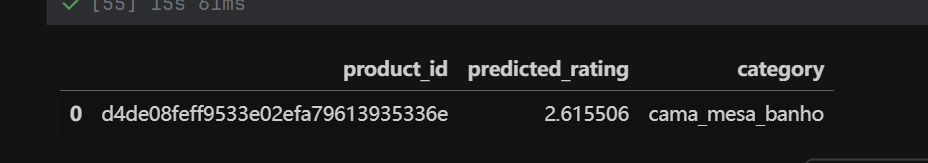

## 3.3 Batch Recommendation

This section generates User-Based CF recommendations for users with at least a minimal interaction history. Under extreme sparsity, low-activity users are not well suited for standalone user-based recommendation and will be handled later in the hybrid recommendation stage.

In [48]:
# =========================================================
# 3.3.1 Select Eligible Users
# =========================================================

eligible_user_df = user_rated_count[user_rated_count['rated_product_count'] >= 3].copy()
eligible_user_df = eligible_user_df.sort_values('rated_product_count', ascending=False)

eligible_user_df = eligible_user_df.merge(
    user_index[['user_idx', 'unique_user_id']],
    on='user_idx',
    how='left'
)

print("Eligible users for User-CF:", len(eligible_user_df))
eligible_user_df.head()

Eligible users for User-CF: 760


,user_idx,rated_product_count,unique_user_id
0,51431,14,8d50f5eadf50201ccdcedfb9e2ac8455
1,22779,13,3e43e6105506432c953e165fb2acf44c
2,73921,9,ca77025e7201e3b30c44b472ff346268
3,10060,9,1b6c7548a2a1f9037c1fd3ddfed95f33
4,73378,8,c8ed31310fc440a3f8031b177f9842c3


In [49]:
# =========================================================
# 3.3.2 Batch Generate Recommendations
# =========================================================

user_based_results = []

for i, row in eligible_user_df.iterrows():
    user_id = row['unique_user_id']
    recs = recommend_user_based(user_id, top_n=10, k_neighbors=200)

    if not recs.empty:
        recs = recs.copy()
        recs['unique_user_id'] = user_id
        recs['rated_product_count'] = row['rated_product_count']
        user_based_results.append(recs)

df_user_based_recs = pd.concat(user_based_results, ignore_index=True) if user_based_results else pd.DataFrame()

print("df_user_based_recs shape:", df_user_based_recs.shape)
df_user_based_recs.head()

df_user_based_recs shape: (4953, 5)


,product_id,predicted_rating,score_source,unique_user_id,rated_product_count
0,aca2eb7d00ea1a7b8ebd4e68314663af,NaN,fallback_popular,8d50f5eadf50201ccdcedfb9e2ac8455,14
1,99a4788cb24856965c36a24e339b6058,NaN,fallback_popular,8d50f5eadf50201ccdcedfb9e2ac8455,14
2,422879e10f46682990de24d770e7f83d,NaN,fallback_popular,8d50f5eadf50201ccdcedfb9e2ac8455,14
3,389d119b48cf3043d311335e499d9c6b,NaN,fallback_popular,8d50f5eadf50201ccdcedfb9e2ac8455,14
4,368c6c730842d78016ad823897a372db,NaN,fallback_popular,8d50f5eadf50201ccdcedfb9e2ac8455,14


In [50]:
# =========================================================
# 3.3.3 Attach Product Category
# =========================================================

# Remove old category columns first if they already exist
drop_cols = [col for col in ['category', 'category_x', 'category_y'] if col in df_user_based_recs.columns]
if drop_cols:
    df_user_based_recs = df_user_based_recs.drop(columns=drop_cols)

df_user_based_recs = df_user_based_recs.merge(
    df_products[['product_id', 'category']],
    on='product_id',
    how='left'
)

print("df_user_based_recs shape after merge:", df_user_based_recs.shape)
print(df_user_based_recs.columns.tolist())
df_user_based_recs.head()

df_user_based_recs shape after merge: (4953, 6)
['product_id', 'predicted_rating', 'score_source', 'unique_user_id', 'rated_product_count', 'category']


,product_id,predicted_rating,score_source,unique_user_id,rated_product_count,category
0,aca2eb7d00ea1a7b8ebd4e68314663af,NaN,fallback_popular,8d50f5eadf50201ccdcedfb9e2ac8455,14,moveis_decoracao
1,99a4788cb24856965c36a24e339b6058,NaN,fallback_popular,8d50f5eadf50201ccdcedfb9e2ac8455,14,cama_mesa_banho
2,422879e10f46682990de24d770e7f83d,NaN,fallback_popular,8d50f5eadf50201ccdcedfb9e2ac8455,14,ferramentas_jardim
3,389d119b48cf3043d311335e499d9c6b,NaN,fallback_popular,8d50f5eadf50201ccdcedfb9e2ac8455,14,ferramentas_jardim
4,368c6c730842d78016ad823897a372db,NaN,fallback_popular,8d50f5eadf50201ccdcedfb9e2ac8455,14,ferramentas_jardim


## 3.4 Recommendation Pattern Check

This section performs a simple check on the structure of User-Based CF outputs, including score source and category distribution.

In [51]:
# =========================================================
# 3.4.1 Check Score Source Distribution
# =========================================================

score_source_dist = (
    df_user_based_recs['score_source']
    .value_counts(dropna=False)
    .reset_index()
)

score_source_dist.columns = ['score_source', 'count']
score_source_dist['share'] = score_source_dist['count'] / score_source_dist['count'].sum()

score_source_dist

,score_source,count,share
0,user_cf,2763,0.557844
1,fallback_popular,2190,0.442156


In [52]:
# =========================================================
# 3.4.2 Check Category Distribution
# =========================================================

category_col = None
for col in ['category', 'category_x', 'category_y']:
    if col in df_user_based_recs.columns:
        category_col = col
        break

if category_col is None:
    raise KeyError("No category column found in df_user_based_recs. Please run 3.3.3 first.")

user_cf_category_dist = (
    df_user_based_recs[category_col]
    .fillna('Unknown')
    .value_counts()
    .reset_index()
)

user_cf_category_dist.columns = ['category', 'recommendation_count']
user_cf_category_dist['share'] = (
    user_cf_category_dist['recommendation_count'] /
    user_cf_category_dist['recommendation_count'].sum()
)

user_cf_category_dist.head(15)

,category,recommendation_count,share
0,cama_mesa_banho,1158,0.233798
1,ferramentas_jardim,914,0.184535
2,informatica_acessorios,552,0.111448
3,moveis_decoracao,522,0.105391
4,relogios_presentes,489,0.098728
5,beleza_saude,343,0.069251
6,esporte_lazer,102,0.020594
7,utilidades_domesticas,99,0.019988
8,brinquedos,95,0.019180
9,fashion_bolsas_e_acessorios,86,0.017363


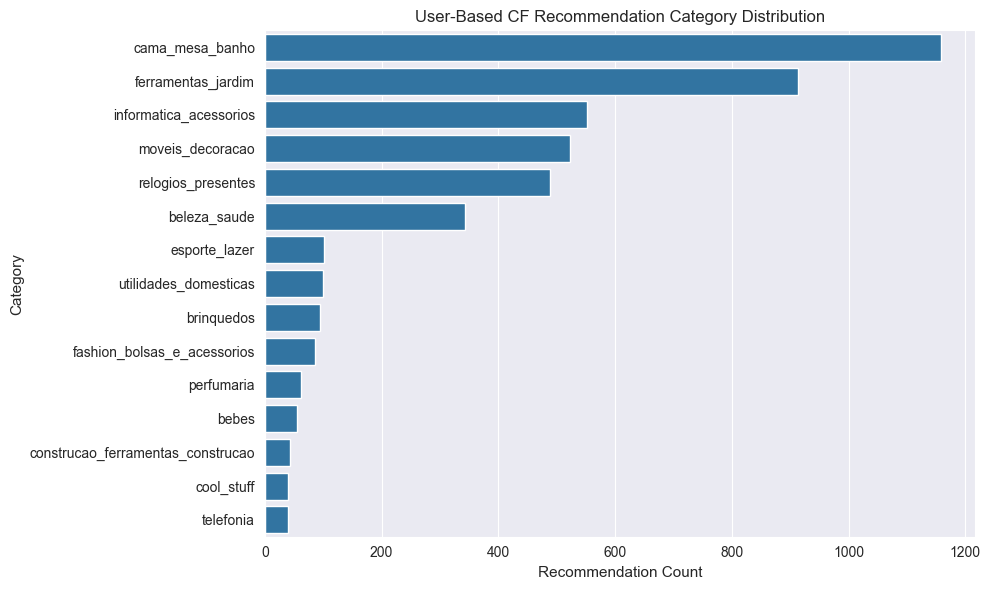

In [53]:
# =========================================================
# 3.4.3 Plot Category Distribution
# =========================================================

plot_user_cf_category = user_cf_category_dist.head(15)

plt.figure(figsize=(10, 6))
sns.barplot(data=plot_user_cf_category, x='recommendation_count', y='category')
plt.title('User-Based CF Recommendation Category Distribution')
plt.xlabel('Recommendation Count')
plt.ylabel('Category')
plt.tight_layout()
plt.savefig(os.path.join(viz_dir, '06_user_cf_category_distribution.png'), dpi=300)
plt.show()

## User-Based Collaborative Filtering Analysis and Summary

User-Based CF produces usable recommendations for a subset of users, but its coverage remains limited under extreme sparsity. In this project, only **760 users** meet the minimum interaction threshold for standalone user-based recommendation.

The recommendation outputs show a mixed pattern. About **55.78%** of recommendations come from the user-based similarity logic, while **44.22%** still rely on fallback popular products. This suggests that User-Based CF can contribute meaningful signals, but it is not stable enough to serve as the main recommendation method on its own.

The category distribution is also concentrated in a small number of high-frequency categories, which indicates that user-based recommendation in sparse settings may still be biased toward popular product groups. Overall, User-Based CF is useful in this project, but its strongest role is as one component of a broader hybrid recommendation framework.
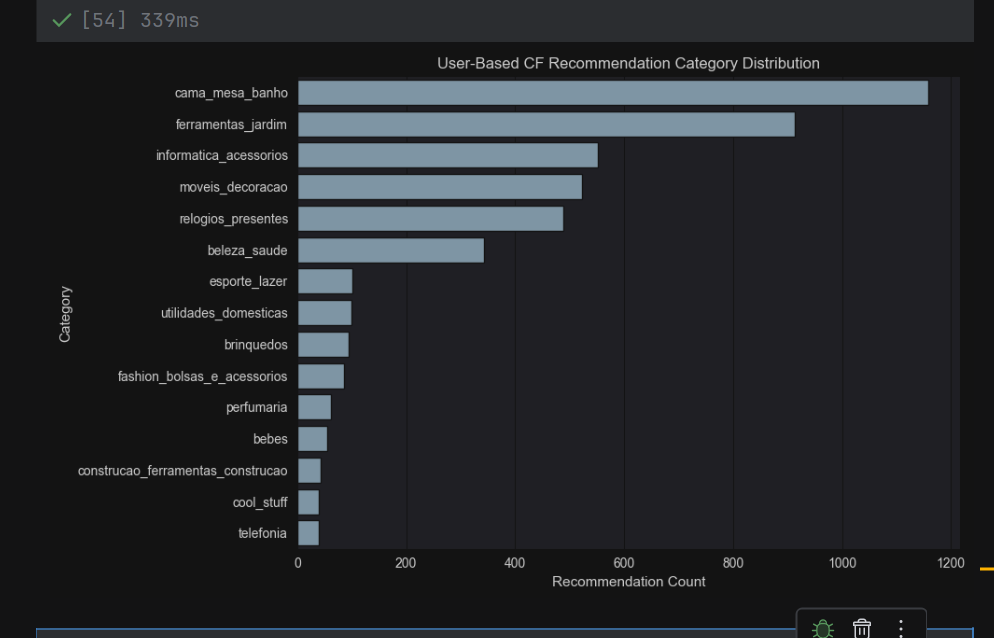
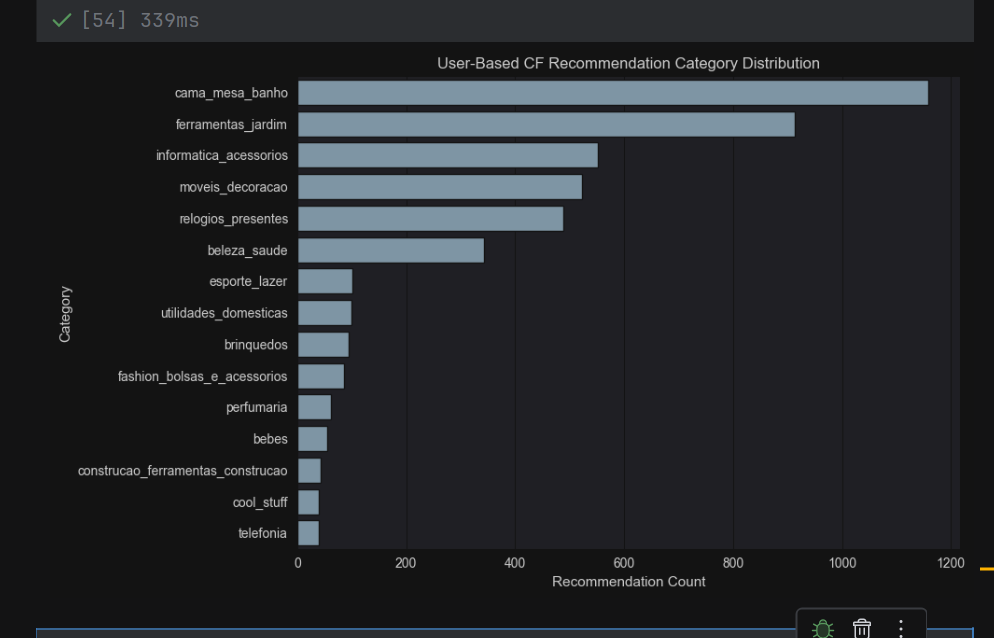
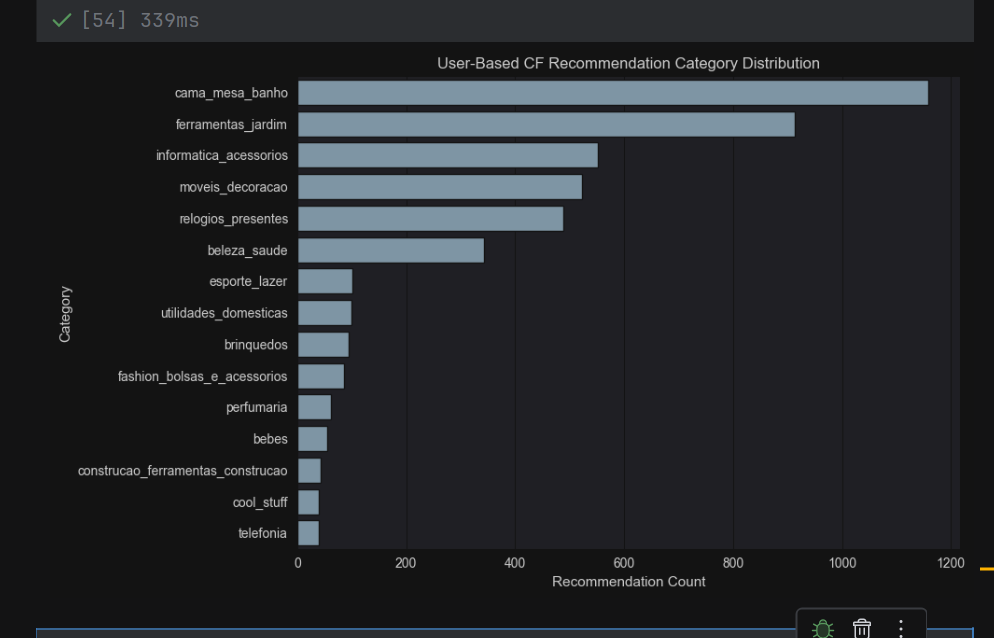

# 4. Algorithm 2 - Item-Based Collaborative Filtering

This chapter implements a lightweight item-based collaborative filtering method. Instead of computing a full dense item-item similarity matrix, the project uses sparse nearest-neighbor search to identify similar products more efficiently.

## 4.1 Item Similarity Modeling

This section models item similarity based on shared user-rating patterns. Compared with user-based recommendation, item-based recommendation is often more stable because item relationships change more slowly than user behavior.

In [54]:
# =========================================================
# 4.1.1 Build Item-User Sparse Matrix
# =========================================================

item_user_sparse = user_item_sparse.T.tocsr()

print("item_user_sparse shape:", item_user_sparse.shape)
print("Number of non-zero entries:", item_user_sparse.nnz)

item_user_sparse shape: (32216, 93358)
Number of non-zero entries: 99785


In [55]:
# =========================================================
# 4.1.2 Fit Item-Based Nearest-Neighbor Model
# =========================================================

item_knn_model = NearestNeighbors(
    metric='cosine',
    algorithm='brute',
    n_neighbors=21,
    n_jobs=-1
)

item_knn_model.fit(item_user_sparse)

print("Item-based nearest-neighbor model fitted successfully.")

Item-based nearest-neighbor model fitted successfully.


In [56]:
# =========================================================
# 4.1.3 Find Similar Items for One Sample Product
# =========================================================

sample_item_idx = 0

distances, indices = item_knn_model.kneighbors(
    item_user_sparse[sample_item_idx],
    n_neighbors=6
)

similar_item_df = pd.DataFrame({
    'neighbor_item_idx': indices.flatten(),
    'cosine_distance': distances.flatten()
})

similar_item_df['cosine_similarity'] = 1 - similar_item_df['cosine_distance']

similar_item_df = similar_item_df.merge(
    item_index.rename(columns={'item_idx': 'neighbor_item_idx', 'product_id': 'neighbor_product_id'}),
    on='neighbor_item_idx',
    how='left'
)

similar_item_df = similar_item_df.merge(
    df_products[['product_id', 'category']].rename(columns={'product_id': 'neighbor_product_id'}),
    on='neighbor_product_id',
    how='left'
)

similar_item_df

,neighbor_item_idx,cosine_distance,cosine_similarity,neighbor_product_id,category
0,0,0.0,1.0,00066f42aeeb9f3007548bb9d3f33c38,perfumaria
1,32208,1.0,0.0,fff1059cd247279f3726b7696c66e44e,esporte_lazer
2,32207,1.0,0.0,fff0a542c3c62682f23305214eaeaa24,papelaria
3,32206,1.0,0.0,ffef256879dbadcab7e77950f4f4a195,artigos_de_natal
4,32205,1.0,0.0,ffedbd68fa6f44e788ff6c2db8094715,livros_tecnicos
5,32204,1.0,0.0,ffeb228c521d5464d1f71444da96c446,telefonia


## Item Similarity Modeling Analysis and Summary

The item-based similarity search runs successfully, but the sample result shows that most neighboring items have very weak similarity signals. Apart from the item itself, the returned products have cosine similarity close to **0**, which reflects the extreme sparsity of shared user-item interactions.

This suggests that direct item-to-item similarity is difficult to estimate reliably in the current dataset. Even though Item-Based CF is structurally more stable than User-Based CF, sparse overlap between products remains a major limitation.

## 4.2 Generate Recommendations

This section recommends new products based on the similarity between candidate items and the products already rated by the user. The final score is calculated as a similarity-weighted average of the user's historical ratings.

In [57]:
# =========================================================
# 4.2.1 Define Item-Based Recommendation Function
# =========================================================

def recommend_item_based(user_id, top_n=10, k_similar_items=20):
    """
    Generate Item-Based CF recommendations using sparse nearest neighbors.
    """
    if user_id not in user_id_to_idx:
        return pd.DataFrame(columns=['product_id', 'predicted_rating', 'score_source'])

    user_idx = int(user_id_to_idx[user_id])
    user_vector = user_item_sparse[user_idx]
    rated_item_indices = user_vector.indices
    rated_item_scores = user_vector.data

    if len(rated_item_indices) == 0:
        return pd.DataFrame(columns=['product_id', 'predicted_rating', 'score_source'])

    predictions = {}

    for rated_item_idx, user_rating in zip(rated_item_indices, rated_item_scores):
        distances, indices = item_knn_model.kneighbors(
            item_user_sparse[rated_item_idx],
            n_neighbors=min(k_similar_items + 1, num_items)
        )

        neighbor_item_indices = indices.flatten()[1:]
        neighbor_similarities = 1 - distances.flatten()[1:]

        for neighbor_idx, sim in zip(neighbor_item_indices, neighbor_similarities):
            if neighbor_idx in rated_item_indices:
                continue
            if sim <= 0:
                continue

            if neighbor_idx not in predictions:
                predictions[neighbor_idx] = {'weighted_sum': 0, 'similarity_sum': 0}

            predictions[neighbor_idx]['weighted_sum'] += sim * user_rating
            predictions[neighbor_idx]['similarity_sum'] += sim

    final_scores = {}
    for item_idx, score_dict in predictions.items():
        if score_dict['similarity_sum'] > 0:
            final_scores[item_idx] = score_dict['weighted_sum'] / score_dict['similarity_sum']

    if len(final_scores) == 0:
        fallback = df_product_sales.sort_values(
            ['sales_count', 'avg_review_score'],
            ascending=[False, False]
        ).head(top_n)[['product_id']].copy()

        fallback['predicted_rating'] = np.nan
        fallback['score_source'] = 'fallback_popular'
        return fallback

    top_items = sorted(final_scores.items(), key=lambda x: x[1], reverse=True)[:top_n]

    result = pd.DataFrame({
        'product_id': [item_idx_to_product_id[item_idx] for item_idx, _ in top_items],
        'predicted_rating': [score for _, score in top_items],
        'score_source': 'item_cf'
    })

    return result

In [58]:
# =========================================================
# 4.2.2 Test Recommendation for One Active User
# =========================================================

active_users = user_rated_count[user_rated_count['rated_product_count'] >= 3].copy()
active_users = active_users.sort_values('rated_product_count', ascending=False)

sample_user_idx = int(active_users.iloc[0]['user_idx'])
sample_user_id = user_index.loc[user_index['user_idx'] == sample_user_idx, 'unique_user_id'].iloc[0]

print("Sample active user:", sample_user_id)
print("Rated product count:", int(active_users.iloc[0]['rated_product_count']))

sample_item_recs = recommend_item_based(sample_user_id, top_n=10, k_similar_items=20)

sample_item_recs = sample_item_recs.merge(
    df_products[['product_id', 'category']],
    on='product_id',
    how='left'
)

sample_item_recs.head(10)

Sample active user: 8d50f5eadf50201ccdcedfb9e2ac8455
Rated product count: 14


,product_id,predicted_rating,score_source,category
0,aca2eb7d00ea1a7b8ebd4e68314663af,NaN,fallback_popular,moveis_decoracao
1,99a4788cb24856965c36a24e339b6058,NaN,fallback_popular,cama_mesa_banho
2,422879e10f46682990de24d770e7f83d,NaN,fallback_popular,ferramentas_jardim
3,389d119b48cf3043d311335e499d9c6b,NaN,fallback_popular,ferramentas_jardim
4,368c6c730842d78016ad823897a372db,NaN,fallback_popular,ferramentas_jardim
5,53759a2ecddad2bb87a079a1f1519f73,NaN,fallback_popular,ferramentas_jardim
6,d1c427060a0f73f6b889a5c7c61f2ac4,NaN,fallback_popular,informatica_acessorios
7,53b36df67ebb7c41585e8d54d6772e08,NaN,fallback_popular,relogios_presentes
8,154e7e31ebfa092203795c972e5804a6,NaN,fallback_popular,beleza_saude
9,3dd2a17168ec895c781a9191c1e95ad7,NaN,fallback_popular,informatica_acessorios


## Generate Recommendations Analysis and Summary

The item-based recommendation pipeline is operational, but the current sample user still receives mainly **fallback popular** recommendations rather than strong similarity-driven results. This indicates that the sparse item-user structure limits the ability of Item-Based CF to generate robust personalized recommendations on its own.

Compared with User-Based CF, Item-Based CF remains a useful component, but the current results suggest that it should also be combined with other methods in the later hybrid recommendation stage.

## 4.3 Batch Recommendation

This section generates Item-Based CF recommendations for users with sufficient interaction history. The goal is to examine whether item-based recommendation can produce more stable output than user-based recommendation under sparse conditions.

In [59]:
# =========================================================
# 4.3.1 Select Eligible Users
# =========================================================

eligible_user_df_item = user_rated_count[user_rated_count['rated_product_count'] >= 3].copy()
eligible_user_df_item = eligible_user_df_item.sort_values('rated_product_count', ascending=False)

eligible_user_df_item = eligible_user_df_item.merge(
    user_index[['user_idx', 'unique_user_id']],
    on='user_idx',
    how='left'
)

print("Eligible users for Item-CF:", len(eligible_user_df_item))
eligible_user_df_item.head()




Eligible users for Item-CF: 760


,user_idx,rated_product_count,unique_user_id
0,51431,14,8d50f5eadf50201ccdcedfb9e2ac8455
1,22779,13,3e43e6105506432c953e165fb2acf44c
2,73921,9,ca77025e7201e3b30c44b472ff346268
3,10060,9,1b6c7548a2a1f9037c1fd3ddfed95f33
4,73378,8,c8ed31310fc440a3f8031b177f9842c3


In [60]:
# =========================================================
# 4.3.2 Batch Generate Recommendations
# =========================================================

item_based_results = []

for _, row in eligible_user_df_item.iterrows():
    user_id = row['unique_user_id']
    recs = recommend_item_based(user_id, top_n=10, k_similar_items=20)

    if not recs.empty:
        recs = recs.copy()
        recs['unique_user_id'] = user_id
        recs['rated_product_count'] = row['rated_product_count']
        item_based_results.append(recs)

df_item_based_recs = pd.concat(item_based_results, ignore_index=True) if item_based_results else pd.DataFrame()

print("df_item_based_recs shape:", df_item_based_recs.shape)
df_item_based_recs.head()

df_item_based_recs shape: (5129, 5)


,product_id,predicted_rating,score_source,unique_user_id,rated_product_count
0,aca2eb7d00ea1a7b8ebd4e68314663af,NaN,fallback_popular,8d50f5eadf50201ccdcedfb9e2ac8455,14
1,99a4788cb24856965c36a24e339b6058,NaN,fallback_popular,8d50f5eadf50201ccdcedfb9e2ac8455,14
2,422879e10f46682990de24d770e7f83d,NaN,fallback_popular,8d50f5eadf50201ccdcedfb9e2ac8455,14
3,389d119b48cf3043d311335e499d9c6b,NaN,fallback_popular,8d50f5eadf50201ccdcedfb9e2ac8455,14
4,368c6c730842d78016ad823897a372db,NaN,fallback_popular,8d50f5eadf50201ccdcedfb9e2ac8455,14


In [61]:
# =========================================================
# 4.3.3 Attach Product Category
# =========================================================

drop_cols = [col for col in ['category', 'category_x', 'category_y'] if col in df_item_based_recs.columns]
if drop_cols:
    df_item_based_recs = df_item_based_recs.drop(columns=drop_cols)

df_item_based_recs = df_item_based_recs.merge(
    df_products[['product_id', 'category']],
    on='product_id',
    how='left'
)

print("df_item_based_recs shape after merge:", df_item_based_recs.shape)
print(df_item_based_recs.columns.tolist())
df_item_based_recs.head()

df_item_based_recs shape after merge: (5129, 6)
['product_id', 'predicted_rating', 'score_source', 'unique_user_id', 'rated_product_count', 'category']


,product_id,predicted_rating,score_source,unique_user_id,rated_product_count,category
0,aca2eb7d00ea1a7b8ebd4e68314663af,NaN,fallback_popular,8d50f5eadf50201ccdcedfb9e2ac8455,14,moveis_decoracao
1,99a4788cb24856965c36a24e339b6058,NaN,fallback_popular,8d50f5eadf50201ccdcedfb9e2ac8455,14,cama_mesa_banho
2,422879e10f46682990de24d770e7f83d,NaN,fallback_popular,8d50f5eadf50201ccdcedfb9e2ac8455,14,ferramentas_jardim
3,389d119b48cf3043d311335e499d9c6b,NaN,fallback_popular,8d50f5eadf50201ccdcedfb9e2ac8455,14,ferramentas_jardim
4,368c6c730842d78016ad823897a372db,NaN,fallback_popular,8d50f5eadf50201ccdcedfb9e2ac8455,14,ferramentas_jardim


In [62]:
# =========================================================
# 4.3.4 Save Recommendation Results
# =========================================================

item_based_path = os.path.join(rec_dir, "recommendations_item_based.csv")
df_item_based_recs.to_csv(item_based_path, index=False)

print("Saved:", item_based_path)

Saved: C:\Users\wangxinxin\Documents\GitHub\E-commerce_decision-making-_intelligence\output\08_recommendation_system\recommendations\recommendations_item_based.csv


## 4.4 Recommendation Pattern Check

This section checks the structure of Item-Based CF outputs, including score source and category distribution.

In [63]:
# =========================================================
# 4.4.1 Check Score Source Distribution
# =========================================================

item_score_source_dist = (
    df_item_based_recs['score_source']
    .value_counts(dropna=False)
    .reset_index()
)

item_score_source_dist.columns = ['score_source', 'count']
item_score_source_dist['share'] = item_score_source_dist['count'] / item_score_source_dist['count'].sum()

item_score_source_dist

,score_source,count,share
0,item_cf,3199,0.623708
1,fallback_popular,1930,0.376292


In [64]:
# =========================================================
# 4.4.2 Check Category Distribution
# =========================================================

category_col = None
for col in ['category', 'category_x', 'category_y']:
    if col in df_item_based_recs.columns:
        category_col = col
        break

if category_col is None:
    raise KeyError("No category column found in df_item_based_recs. Please run 4.3.3 first.")

item_cf_category_dist = (
    df_item_based_recs[category_col]
    .fillna('Unknown')
    .value_counts()
    .reset_index()
)

item_cf_category_dist.columns = ['category', 'recommendation_count']
item_cf_category_dist['share'] = (
    item_cf_category_dist['recommendation_count'] /
    item_cf_category_dist['recommendation_count'].sum()
)

item_cf_category_dist.head(15)

,category,recommendation_count,share
0,cama_mesa_banho,1263,0.246247
1,ferramentas_jardim,821,0.160070
2,moveis_decoracao,563,0.109768
3,informatica_acessorios,525,0.102359
4,relogios_presentes,485,0.094560
5,beleza_saude,325,0.063365
6,utilidades_domesticas,134,0.026126
7,esporte_lazer,125,0.024371
8,brinquedos,105,0.020472
9,fashion_bolsas_e_acessorios,100,0.019497


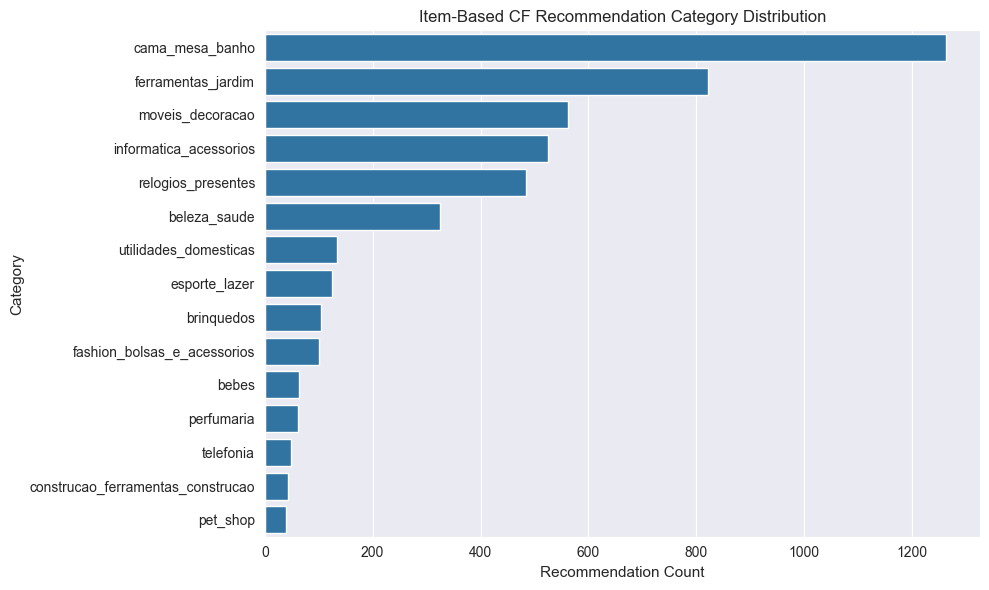

In [65]:
# =========================================================
# 4.4.3 Plot Category Distribution
# =========================================================

plot_item_cf_category = item_cf_category_dist.head(15)

plt.figure(figsize=(10, 6))
sns.barplot(data=plot_item_cf_category, x='recommendation_count', y='category')
plt.title('Item-Based CF Recommendation Category Distribution')
plt.xlabel('Recommendation Count')
plt.ylabel('Category')
plt.tight_layout()
plt.savefig(os.path.join(viz_dir, '07_item_cf_category_distribution.png'), dpi=300)
plt.show()

# 5. Algorithm 3 - Content-Based Recommendation

This chapter implements a content-based recommendation method using product attributes and historical product-level features. Unlike collaborative filtering, this method does not depend entirely on user overlap, so it is more suitable for sparse interaction settings and cold-start scenarios.

## 5.1 Product Feature Engineering

This section constructs product-level content features for similarity modeling. The feature set combines product category, physical attributes, and historical product performance indicators.

In [66]:
# =========================================================
# 5.1.1 Build Product Feature Base Table
# =========================================================

df_product_features = df_products.merge(
    df_product_sales[['product_id', 'sales_count', 'avg_price', 'avg_review_score', 'review_count']],
    on='product_id',
    how='left'
)

feature_cols_fill_zero = ['sales_count', 'avg_price', 'avg_review_score', 'review_count']
for col in feature_cols_fill_zero:
    if col in df_product_features.columns:
        df_product_features[col] = df_product_features[col].fillna(0)

df_product_features['category'] = df_product_features['category'].fillna('Unknow')

print("df_product_features shape:", df_product_features.shape)
df_product_features.head()

df_product_features shape: (32951, 10)


,product_id,category,weight_g,length_cm,height_cm,width_cm,sales_count,avg_price,avg_review_score,review_count
0,00066f42aeeb9f3007548bb9d3f33c38,perfumaria,300.0,20.0,16.0,16.0,1,101.65,5.0,1
1,00088930e925c41fd95ebfe695fd2655,automotivo,1225.0,55.0,10.0,26.0,1,129.90,4.0,1
2,0009406fd7479715e4bef61dd91f2462,cama_mesa_banho,300.0,45.0,15.0,35.0,1,229.00,1.0,1
3,000b8f95fcb9e0096488278317764d19,utilidades_domesticas,550.0,19.0,24.0,12.0,2,58.90,5.0,2
4,000d9be29b5207b54e86aa1b1ac54872,relogios_presentes,250.0,22.0,11.0,15.0,1,199.00,5.0,1


In [67]:
# =========================================================
# 5.1.2 One-Hot Encode Category
# =========================================================

category_encoded = pd.get_dummies(
    df_product_features['category'],
    prefix='cat'
)

print("category_encoded shape:", category_encoded.shape)
category_encoded.head()

category_encoded shape: (32951, 74)


,cat_Unknow,cat_agro_industria_e_comercio,cat_alimentos,cat_alimentos_bebidas,cat_artes,cat_artes_e_artesanato,cat_artigos_de_festas,cat_artigos_de_natal,cat_audio,cat_automotivo,cat_bebes,cat_bebidas,cat_beleza_saude,cat_brinquedos,cat_cama_mesa_banho,cat_casa_conforto,cat_casa_conforto_2,cat_casa_construcao,cat_cds_dvds_musicais,cat_cine_foto,cat_climatizacao,cat_consoles_games,cat_construcao_ferramentas_construcao,cat_construcao_ferramentas_ferramentas,cat_construcao_ferramentas_iluminacao,cat_construcao_ferramentas_jardim,cat_construcao_ferramentas_seguranca,cat_cool_stuff,cat_dvds_blu_ray,cat_eletrodomesticos,cat_eletrodomesticos_2,cat_eletronicos,cat_eletroportateis,cat_esporte_lazer,cat_fashion_bolsas_e_acessorios,cat_fashion_calcados,cat_fashion_esporte,cat_fashion_roupa_feminina,cat_fashion_roupa_infanto_juvenil,cat_fashion_roupa_masculina,cat_fashion_underwear_e_moda_praia,cat_ferramentas_jardim,cat_flores,cat_fraldas_higiene,cat_industria_comercio_e_negocios,cat_informatica_acessorios,cat_instrumentos_musicais,cat_la_cuisine,cat_livros_importados,cat_livros_interesse_geral,cat_livros_tecnicos,cat_malas_acessorios,cat_market_place,cat_moveis_colchao_e_estofado,cat_moveis_cozinha_area_de_servico_jantar_e_jardim,cat_moveis_decoracao,cat_moveis_escritorio,cat_moveis_quarto,cat_moveis_sala,cat_musica,cat_papelaria,cat_pc_gamer,cat_pcs,cat_perfumaria,cat_pet_shop,cat_portateis_casa_forno_e_cafe,cat_portateis_cozinha_e_preparadores_de_alimentos,cat_relogios_presentes,cat_seguros_e_servicos,cat_sinalizacao_e_seguranca,cat_tablets_impressao_imagem,cat_telefonia,cat_telefonia_fixa,cat_utilidades_domesticas
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False


In [68]:
# =========================================================
# 5.1.3 Standardize Numeric Features
# =========================================================

numeric_features = [
    'weight_g',
    'length_cm',
    'height_cm',
    'width_cm',
    'sales_count',
    'avg_price',
    'avg_review_score',
    'review_count'
]

for col in numeric_features:
    df_product_features[col] = df_product_features[col].fillna(0)

scaler = StandardScaler()
numeric_scaled = scaler.fit_transform(df_product_features[numeric_features])

numeric_scaled_df = pd.DataFrame(
    numeric_scaled,
    columns=numeric_features,
    index=df_product_features.index
)

print("numeric_scaled_df shape:", numeric_scaled_df.shape)
numeric_scaled_df.head()

numeric_scaled_df shape: (32951, 8)


,weight_g,length_cm,height_cm,width_cm,sales_count,avg_price,avg_review_score,review_count
0,-0.461558,-0.639253,-0.068680,-0.595647,-0.227865,-0.176810,0.778369,-0.226055
1,-0.245531,1.429869,-0.508641,0.232178,-0.227865,-0.062388,-0.011624,-0.226055
2,-0.461558,0.838691,-0.142007,0.977221,-0.227865,0.339002,-2.381602,-0.226055
3,-0.403172,-0.698370,0.517934,-0.926776,-0.134109,-0.349963,0.778369,-0.131152
4,-0.473235,-0.521017,-0.435315,-0.678429,-0.227865,0.217492,0.778369,-0.226055


In [69]:
# =========================================================
# 5.1.4 Combine Content Features
# =========================================================

content_features = pd.concat(
    [category_encoded.reset_index(drop=True), numeric_scaled_df.reset_index(drop=True)],
    axis=1
)

content_features.index = df_product_features['product_id']

print("content_features shape:", content_features.shape)
content_features.head()

content_features shape: (32951, 82)


,cat_Unknow,cat_agro_industria_e_comercio,cat_alimentos,cat_alimentos_bebidas,cat_artes,cat_artes_e_artesanato,cat_artigos_de_festas,cat_artigos_de_natal,cat_audio,cat_automotivo,cat_bebes,cat_bebidas,cat_beleza_saude,cat_brinquedos,cat_cama_mesa_banho,cat_casa_conforto,cat_casa_conforto_2,cat_casa_construcao,cat_cds_dvds_musicais,cat_cine_foto,cat_climatizacao,cat_consoles_games,cat_construcao_ferramentas_construcao,cat_construcao_ferramentas_ferramentas,cat_construcao_ferramentas_iluminacao,cat_construcao_ferramentas_jardim,cat_construcao_ferramentas_seguranca,cat_cool_stuff,cat_dvds_blu_ray,cat_eletrodomesticos,cat_eletrodomesticos_2,cat_eletronicos,cat_eletroportateis,cat_esporte_lazer,cat_fashion_bolsas_e_acessorios,cat_fashion_calcados,cat_fashion_esporte,cat_fashion_roupa_feminina,cat_fashion_roupa_infanto_juvenil,cat_fashion_roupa_masculina,cat_fashion_underwear_e_moda_praia,cat_ferramentas_jardim,cat_flores,cat_fraldas_higiene,cat_industria_comercio_e_negocios,cat_informatica_acessorios,cat_instrumentos_musicais,cat_la_cuisine,cat_livros_importados,cat_livros_interesse_geral,cat_livros_tecnicos,cat_malas_acessorios,cat_market_place,cat_moveis_colchao_e_estofado,cat_moveis_cozinha_area_de_servico_jantar_e_jardim,cat_moveis_decoracao,cat_moveis_escritorio,cat_moveis_quarto,cat_moveis_sala,cat_musica,cat_papelaria,cat_pc_gamer,cat_pcs,cat_perfumaria,cat_pet_shop,cat_portateis_casa_forno_e_cafe,cat_portateis_cozinha_e_preparadores_de_alimentos,cat_relogios_presentes,cat_seguros_e_servicos,cat_sinalizacao_e_seguranca,cat_tablets_impressao_imagem,cat_telefonia,cat_telefonia_fixa,cat_utilidades_domesticas,weight_g,length_cm,height_cm,width_cm,sales_count,avg_price,avg_review_score,review_count
product_id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
00066f42aeeb9f3007548bb9d3f33c38,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,-0.461558,-0.639253,-0.068680,-0.595647,-0.227865,-0.176810,0.778369,-0.226055
00088930e925c41fd95ebfe695fd2655,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,-0.245531,1.429869,-0.508641,0.232178,-0.227865,-0.062388,-0.011624,-0.226055
0009406fd7479715e4bef61dd91f2462,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,-0.461558,0.838691,-0.142007,0.977221,-0.227865,0.339002,-2.381602,-0.226055
000b8f95fcb9e0096488278317764d19,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,-0.403172,-0.698370,0.517934,-0.926776,-0.13

In [70]:
# =========================================================
# 5.1.5 Save Content Features
# =========================================================

content_features_path = os.path.join(data_dir, "content_features.csv")
content_features.to_csv(content_features_path)

print("Saved:", content_features_path)

Saved: C:\Users\wangxinxin\Documents\GitHub\E-commerce_decision-making-_intelligence\output\08_recommendation_system\data\content_features.csv


## Product Feature Engineering Analysis and Summary

The product feature table is successfully constructed with **32,951 products** and **82 content features**. Compared with collaborative filtering, this feature space is more compact and less affected by sparse user overlap.

This makes content-based recommendation especially important in the current project, because product attributes can provide a more stable basis for recommendation when interaction data is limited.

## 5.2 Content Similarity Modeling

This section models products similarity based on content features. Since the feature space is relatively compact, content similarity can be estimated more stably than collaborative similarity in sparse recommendation settings.

In [71]:
# =========================================================
# 5.2.1 Prepare Content Feature Matrix for Modeling
# =========================================================

content_features_model = content_features.astype(float).copy()

content_product_ids = content_features_model.index.tolist()
content_product_id_to_idx = {pid: i for i, pid in enumerate(content_product_ids)}
content_idx_to_product_id = {i: pid for i, pid in enumerate(content_product_ids)}

print("content_features_model shape:", content_features_model.shape)
content_features_model.head()

content_features_model shape: (32951, 82)


,cat_Unknow,cat_agro_industria_e_comercio,cat_alimentos,cat_alimentos_bebidas,cat_artes,cat_artes_e_artesanato,cat_artigos_de_festas,cat_artigos_de_natal,cat_audio,cat_automotivo,cat_bebes,cat_bebidas,cat_beleza_saude,cat_brinquedos,cat_cama_mesa_banho,cat_casa_conforto,cat_casa_conforto_2,cat_casa_construcao,cat_cds_dvds_musicais,cat_cine_foto,cat_climatizacao,cat_consoles_games,cat_construcao_ferramentas_construcao,cat_construcao_ferramentas_ferramentas,cat_construcao_ferramentas_iluminacao,cat_construcao_ferramentas_jardim,cat_construcao_ferramentas_seguranca,cat_cool_stuff,cat_dvds_blu_ray,cat_eletrodomesticos,cat_eletrodomesticos_2,cat_eletronicos,cat_eletroportateis,cat_esporte_lazer,cat_fashion_bolsas_e_acessorios,cat_fashion_calcados,cat_fashion_esporte,cat_fashion_roupa_feminina,cat_fashion_roupa_infanto_juvenil,cat_fashion_roupa_masculina,cat_fashion_underwear_e_moda_praia,cat_ferramentas_jardim,cat_flores,cat_fraldas_higiene,cat_industria_comercio_e_negocios,cat_informatica_acessorios,cat_instrumentos_musicais,cat_la_cuisine,cat_livros_importados,cat_livros_interesse_geral,cat_livros_tecnicos,cat_malas_acessorios,cat_market_place,cat_moveis_colchao_e_estofado,cat_moveis_cozinha_area_de_servico_jantar_e_jardim,cat_moveis_decoracao,cat_moveis_escritorio,cat_moveis_quarto,cat_moveis_sala,cat_musica,cat_papelaria,cat_pc_gamer,cat_pcs,cat_perfumaria,cat_pet_shop,cat_portateis_casa_forno_e_cafe,cat_portateis_cozinha_e_preparadores_de_alimentos,cat_relogios_presentes,cat_seguros_e_servicos,cat_sinalizacao_e_seguranca,cat_tablets_impressao_imagem,cat_telefonia,cat_telefonia_fixa,cat_utilidades_domesticas,weight_g,length_cm,height_cm,width_cm,sales_count,avg_price,avg_review_score,review_count
product_id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
00066f42aeeb9f3007548bb9d3f33c38,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.461558,-0.639253,-0.068680,-0.595647,-0.227865,-0.176810,0.778369,-0.226055
00088930e925c41fd95ebfe695fd2655,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.245531,1.429869,-0.508641,0.232178,-0.227865,-0.062388,-0.011624,-0.226055
0009406fd7479715e4bef61dd91f2462,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.461558,0.838691,-0.142007,0.977221,-0.227865,0.339002,-2.381602,-0.226055
000b8f95fcb9e0096488278317764d19,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,-0.403172,-0.698370,0.517934,-0.926776,-0.134109,-0.349963,0.778369,-0.131152
000d9be29b5207b54e86aa1b1ac54872,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.473235,-0.521017,-0.435315,-0.678429,-0.227865,0.217492,0.778369,-0.226055


In [72]:
# =========================================================
# 5.2.2 Fit Content-Based Nearest-Neighbor Model
# =========================================================

content_knn_model = NearestNeighbors(
    metric='cosine',
    algorithm='brute',
    n_neighbors=21,
    n_jobs=-1
)

content_knn_model.fit(content_features_model.values)

print("Content-based nearest-neighbor model fitted successfully.")

Content-based nearest-neighbor model fitted successfully.


In [73]:
# =========================================================
# 5.2.3 Find Similar Products for One Sample Product
# =========================================================

sample_content_idx = 0

distances, indices = content_knn_model.kneighbors(
    content_features_model.values[sample_content_idx].reshape(1, -1),
    n_neighbors=6
)

similar_content_df = pd.DataFrame({
    'neighbor_content_idx': indices.flatten(),
    'cosine_distance': distances.flatten()
})

similar_content_df['cosine_similarity'] = 1 - similar_content_df['cosine_distance']
similar_content_df['neighbor_product_id'] = similar_content_df['neighbor_content_idx'].map(content_idx_to_product_id)

similar_content_df = similar_content_df.merge(
    df_products[['product_id', 'category']].rename(columns={'product_id': 'neighbor_product_id'}),
    on='neighbor_product_id',
    how='left'
)

similar_content_df

,neighbor_content_idx,cosine_distance,cosine_similarity,neighbor_product_id,category
0,0,0.000000,1.000000,00066f42aeeb9f3007548bb9d3f33c38,perfumaria
1,28420,0.004497,0.995503,dc7b5d2b32ae30c86acd229b5ff34dcc,perfumaria
2,14431,0.005027,0.994973,6f9f3f69c27aaeaac0cc6bc4d431f3e8,perfumaria
3,29543,0.006565,0.993435,e57b2d6510f090860888171c76b42b21,perfumaria
4,12152,0.008838,0.991162,5dc01f0525d00d0b349bf2ff92f7d1a2,perfumaria
5,3844,0.009448,0.990552,1cf1166849ef1df39734ef593d71f20c,perfumaria


## Content Similarity Modeling Analysis and Summary

The content similarity model runs successfully and produces strong similarity signals between products with similar attributes. Unlike collaborative filtering, this similarity structure is not constrained by sparse user overlap, which makes it more stable in the current project.

The sample result also shows that content-based similarity is highly sensitive to shared category and product attributes. This provides a strong basis for recommendation, but it may also increase the risk of over-concentration within narrow product groups.

## 5.3 Generate Recommendations

This section generates recommendations by matching a user's historical products with content-similar products. The final recommendation score is based on both product similarity and the user's historical rating strength.

In [74]:
# =========================================================
# 5.3.1 Define Content-Based Recommendation Function
# =========================================================

item_idx_to_product_id = item_index.set_index('item_idx')['product_id'].to_dict()
user_id_to_idx = user_index.set_index('unique_user_id')['user_idx'].to_dict()

def recommend_content_based(user_id, top_n=10, k_similar_items=20):
    """
    Generate Content-Based recommendations using product content similarity.
    """
    if user_id not in user_id_to_idx:
        return pd.DataFrame(columns=['product_id', 'predicted_rating', 'score_source'])

    user_idx = int(user_id_to_idx[user_id])
    user_vector = user_item_sparse[user_idx]
    rated_item_indices = user_vector.indices
    rated_item_scores = user_vector.data

    if len(rated_item_indices) == 0:
        return pd.DataFrame(columns=['product_id', 'predicted_rating', 'score_source'])

    rated_product_ids = [
        item_idx_to_product_id[item_idx]
        for item_idx in rated_item_indices
        if item_idx in item_idx_to_product_id
    ]

    rated_product_set = set(rated_product_ids)
    predictions = {}

    for product_id, user_rating in zip(rated_product_ids, rated_item_scores):
        if product_id not in content_product_id_to_idx:
            continue

        content_idx = content_product_id_to_idx[product_id]

        distances, indices = content_knn_model.kneighbors(
            content_features_model.values[content_idx].reshape(1, -1),
            n_neighbors=min(k_similar_items + 1, len(content_product_ids))
        )

        neighbor_content_indices = indices.flatten()[1:]
        neighbor_similarities = 1 - distances.flatten()[1:]

        for neighbor_idx, sim in zip(neighbor_content_indices, neighbor_similarities):
            neighbor_product_id = content_idx_to_product_id[neighbor_idx]

            if neighbor_product_id in rated_product_set:
                continue
            if sim <= 0:
                continue

            if neighbor_product_id not in predictions:
                predictions[neighbor_product_id] = {'weighted_sum': 0, 'similarity_sum': 0}

            predictions[neighbor_product_id]['weighted_sum'] += sim * user_rating
            predictions[neighbor_product_id]['similarity_sum'] += sim

    final_scores = {}
    for product_id, score_dict in predictions.items():
        if score_dict['similarity_sum'] > 0:
            final_scores[product_id] = score_dict['weighted_sum'] / score_dict['similarity_sum']

    if len(final_scores) == 0:
        fallback = df_product_sales.sort_values(
            ['sales_count', 'avg_review_score'],
            ascending=[False, False]
        ).head(top_n)[['product_id']].copy()

        fallback['predicted_rating'] = np.nan
        fallback['score_source'] = 'fallback_popular'
        return fallback

    top_items = sorted(final_scores.items(), key=lambda x: x[1], reverse=True)[:top_n]

    result = pd.DataFrame({
        'product_id': [pid for pid, _ in top_items],
        'predicted_rating': [score for _, score in top_items],
        'score_source': 'content_based'
    })

    return result

In [75]:
# =========================================================
# 5.3.2 Test Recommendation for One Active User
# =========================================================

active_users = user_rated_count[user_rated_count['rated_product_count'] >= 3].copy()
active_users = active_users.sort_values('rated_product_count', ascending=False)

sample_user_idx = int(active_users.iloc[0]['user_idx'])
sample_user_id = user_index.loc[user_index['user_idx'] == sample_user_idx, 'unique_user_id'].iloc[0]

print("Sample active user:", sample_user_id)
print("Rated product count:", int(active_users.iloc[0]['rated_product_count']))

sample_content_recs = recommend_content_based(sample_user_id, top_n=10, k_similar_items=20)

sample_content_recs = sample_content_recs.merge(
    df_products[['product_id', 'category']],
    on='product_id',
    how='left'
)

sample_content_recs.head(10)

Sample active user: 8d50f5eadf50201ccdcedfb9e2ac8455
Rated product count: 14


,product_id,predicted_rating,score_source,category
0,154e46f42e5665a0af25d2fc7c9e3321,4.092363,content_based,esporte_lazer
1,d6def90f2db6db438426d0434ba7c190,4.092363,content_based,esporte_lazer
2,b0dda79e79fdc30a862d527ffffdf4bc,4.092363,content_based,esporte_lazer
3,5118d39afe332258d1428a98db06e8c8,4.092363,content_based,esporte_lazer
4,49c934af2be4194ac63262d60745fcb0,4.092363,content_based,esporte_lazer
5,cde1665c376260772c25ed5dba63bd82,4.071758,content_based,esporte_lazer
6,8a83947ee16d41d5e83dd90b7d28caee,4.071659,content_based,esporte_lazer
7,f0a7113644fce6d200240a1d0dba2b9b,4.071468,content_based,esporte_lazer
8,8b8b4d3f77864f6e8f6b35fc23ff63ca,4.071453,content_based,esporte_lazer
9,6df11ffefdab6d8afd1532c5f2f05fb3,4.071432,content_based,esporte_lazer


## Content-Based Recommendation Analysis and Summary

The content-based recommendation pipeline produces stable personalized outputs for the sample user, and all recommended products come directly from content similarity rather than fallback logic. This suggests that content-based recommendation is more than collaborative filtering in the current sparse setting.

At the same time, the recommended products are highly concentrated in the same category, which indicates limited diversity. Therefore, Content-Based recommendation is strong as a standalone signal, but it still needs to be balanced with other methods in the later hybrid recommendation stage.

## 5.4 Batch Recommendation

This section generates Content-Based recommendations for users with sufficient interaction history and checks whether this method can produce stable outputs at scale.

In [76]:
# =========================================================
# 5.4.1 Select Eligible Users
# =========================================================

eligible_user_df_content = user_rated_count[user_rated_count['rated_product_count'] >= 3].copy()
eligible_user_df_content = eligible_user_df_content.sort_values('rated_product_count', ascending=False)

eligible_user_df_content = eligible_user_df_content.merge(
    user_index[['user_idx', 'unique_user_id']],
    on='user_idx',
    how='left'
)

print("Eligible users for Content-Based:", len(eligible_user_df_content))
eligible_user_df_content.head()

Eligible users for Content-Based: 760


,user_idx,rated_product_count,unique_user_id
0,51431,14,8d50f5eadf50201ccdcedfb9e2ac8455
1,22779,13,3e43e6105506432c953e165fb2acf44c
2,73921,9,ca77025e7201e3b30c44b472ff346268
3,10060,9,1b6c7548a2a1f9037c1fd3ddfed95f33
4,73378,8,c8ed31310fc440a3f8031b177f9842c3


In [77]:
# =========================================================
# 5.4.2 Batch Generate Recommendations
# =========================================================

content_based_results = []

for _, row in eligible_user_df_content.iterrows():
    user_id = row['unique_user_id']
    recs = recommend_content_based(user_id, top_n=50, k_similar_items=20)

    if not recs.empty:
        recs = recs.copy()
        recs['unique_user_id'] = user_id
        recs['rated_product_count'] = row['rated_product_count']
        content_based_results.append(recs)

df_content_recs = pd.concat(content_based_results, ignore_index=True) if content_based_results else pd.DataFrame()

print("df_content_recs shape:", df_content_recs.shape)
df_content_recs.head()

df_content_recs shape: (35267, 5)


,product_id,predicted_rating,score_source,unique_user_id,rated_product_count
0,154e46f42e5665a0af25d2fc7c9e3321,4.092363,content_based,8d50f5eadf50201ccdcedfb9e2ac8455,14
1,d6def90f2db6db438426d0434ba7c190,4.092363,content_based,8d50f5eadf50201ccdcedfb9e2ac8455,14
2,b0dda79e79fdc30a862d527ffffdf4bc,4.092363,content_based,8d50f5eadf50201ccdcedfb9e2ac8455,14
3,5118d39afe332258d1428a98db06e8c8,4.092363,content_based,8d50f5eadf50201ccdcedfb9e2ac8455,14
4,49c934af2be4194ac63262d60745fcb0,4.092363,content_based,8d50f5eadf50201ccdcedfb9e2ac8455,14


In [78]:
# =========================================================
# 5.4.3 Attach Product Category
# =========================================================

drop_cols = [col for col in ['category', 'category_x', 'category_y'] if col in df_content_recs.columns]
if drop_cols:
    df_content_recs = df_content_recs.drop(columns=drop_cols)

df_content_recs = df_content_recs.merge(
    df_products[['product_id', 'category']],
    on='product_id',
    how='left'
)

print("df_content_recs shape after merge:", df_content_recs.shape)
print(df_content_recs.columns.tolist())
df_content_recs.head()

df_content_recs shape after merge: (35267, 6)
['product_id', 'predicted_rating', 'score_source', 'unique_user_id', 'rated_product_count', 'category']


,product_id,predicted_rating,score_source,unique_user_id,rated_product_count,category
0,154e46f42e5665a0af25d2fc7c9e3321,4.092363,content_based,8d50f5eadf50201ccdcedfb9e2ac8455,14,esporte_lazer
1,d6def90f2db6db438426d0434ba7c190,4.092363,content_based,8d50f5eadf50201ccdcedfb9e2ac8455,14,esporte_lazer
2,b0dda79e79fdc30a862d527ffffdf4bc,4.092363,content_based,8d50f5eadf50201ccdcedfb9e2ac8455,14,esporte_lazer
3,5118d39afe332258d1428a98db06e8c8,4.092363,content_based,8d50f5eadf50201ccdcedfb9e2ac8455,14,esporte_lazer
4,49c934af2be4194ac63262d60745fcb0,4.092363,content_based,8d50f5eadf50201ccdcedfb9e2ac8455,14,esporte_lazer


In [79]:
# =========================================================
# 5.4.4 Save Recommendation Results
# =========================================================

content_based_path = os.path.join(rec_dir, "recommendations_content.csv")
df_content_recs.to_csv(content_based_path, index=False)

print("Saved:", content_based_path)

Saved: C:\Users\wangxinxin\Documents\GitHub\E-commerce_decision-making-_intelligence\output\08_recommendation_system\recommendations\recommendations_content.csv


## 5.5 Recommendation Pattern Check

This section checks the structure of Content-Based recommendation outputs, including score source and category concentration.

In [80]:
# =========================================================
# 5.5.1 Check Score Source Distribution
# =========================================================

content_score_source_dist = (
    df_content_recs['score_source']
    .value_counts(dropna=False)
    .reset_index()
)

content_score_source_dist.columns = ['score_source', 'count']
content_score_source_dist['share'] = content_score_source_dist['count'] / content_score_source_dist['count'].sum()

content_score_source_dist

,score_source,count,share
0,content_based,35267,1.0


In [81]:
# =========================================================
# 5.5.2 Check Category Distribution
# =========================================================

category_col = None
for col in ['category', 'category_x', 'category_y']:
    if col in df_content_recs.columns:
        category_col = col
        break

if category_col is None:
    raise KeyError("No category column found in df_content_recs. Please run 5.4.3 first.")

content_category_dist = (
    df_content_recs[category_col]
    .fillna('Unknown')
    .value_counts()
    .reset_index()
)

content_category_dist.columns = ['category', 'recommendation_count']
content_category_dist['share'] = (
    content_category_dist['recommendation_count'] /
    content_category_dist['recommendation_count'].sum()
)

content_category_dist.head(15)

,category,recommendation_count,share
0,cama_mesa_banho,8375,0.237474
1,moveis_decoracao,4821,0.136700
2,relogios_presentes,2181,0.061843
3,utilidades_domesticas,2106,0.059716
4,beleza_saude,2016,0.057164
5,esporte_lazer,1934,0.054839
6,fashion_bolsas_e_acessorios,1817,0.051521
7,informatica_acessorios,1663,0.047155
8,brinquedos,1334,0.037826
9,automotivo,891,0.025264


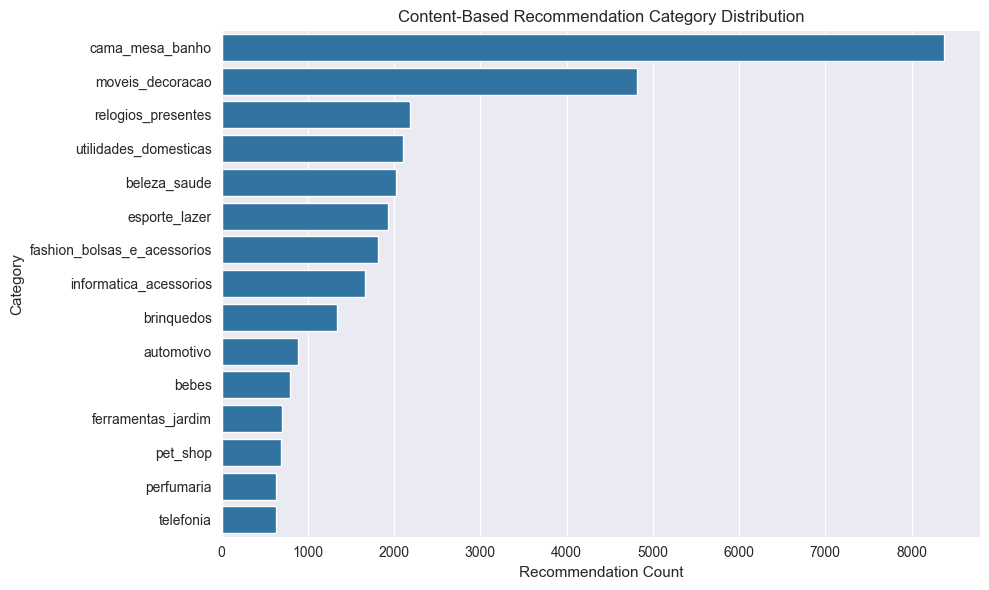

In [82]:
# =========================================================
# 5.5.3 Plot Category Distribution
# =========================================================

plot_content_category = content_category_dist.head(15)

plt.figure(figsize=(10, 6))
sns.barplot(data=plot_content_category, x='recommendation_count', y='category')
plt.title('Content-Based Recommendation Category Distribution')
plt.xlabel('Recommendation Count')
plt.ylabel('Category')
plt.tight_layout()
plt.savefig(os.path.join(viz_dir, '08_content_based_category_distribution.png'), dpi=300)
plt.show()

## Content-Based Recommendation Analysis and Summary

Content-Based recommendation is the most stable standalone method in the current project, It generates recommendation for all eligible users without relying on fallback logic, which shows that product content features provide a much stronger signal than sparse collaborative overlap.

At the same time, the recommendation distribution is highly concentrated in several major categories, which indicates limited diversity. This suggests that Content-Based recommendation is strong in stability, but still needs to be balanced with collaborative signals in the hybrid stage.

# 6. Hybrid Recommendation

This chapter combines User-Based CF, Item-Based CF, and Content-Based recommendation into a hybrid framework. The goal is to improve recommendation robustness by balancing collaborative signals with product-content signals under sparse interaction conditions.

## 6.1 Basic Hybrid Strategy

This section builds a weighted hybrid recommendation method. Instead of relying on one algorithm only, the project combines three recommendation sources and aggregates them into a single ranking score.

In [83]:
# =========================================================
# 6.1.1 Build Popularity Fallback Score
# =========================================================

df_popularity = df_product_sales[['product_id', 'sales_count', 'avg_review_score']].copy()

# Fill missing values
df_popularity['sales_count'] = df_popularity['sales_count'].fillna(0)
df_popularity['avg_review_score'] = df_popularity['avg_review_score'].fillna(0)

# Min-max normalization
sales_min, sales_max = df_popularity['sales_count'].min(), df_popularity['sales_count'].max()
score_min, score_max = df_popularity['avg_review_score'].min(), df_popularity['avg_review_score'].max()

if sales_max == sales_min:
    df_popularity['sales_norm'] = 0.5
else:
    df_popularity['sales_norm'] = (df_popularity['sales_count'] - sales_min) / (sales_max - sales_min)

if score_max == score_min:
    df_popularity['review_norm'] = 0.5
else:
    df_popularity['review_norm'] = (df_popularity['avg_review_score'] - score_min) / (score_max - score_min)

df_popularity['popularity_score'] = 0.7 * df_popularity['sales_norm'] + 0.3 * df_popularity['review_norm']

df_popularity = df_popularity[['product_id', 'popularity_score']]

print("df_popularity shape:", df_popularity.shape)
df_popularity.head()

df_popularity shape: (32951, 2)


,product_id,popularity_score
0,00066f42aeeb9f3007548bb9d3f33c38,0.300000
1,00088930e925c41fd95ebfe695fd2655,0.240000
2,0009406fd7479715e4bef61dd91f2462,0.060000
3,000b8f95fcb9e0096488278317764d19,0.301331
4,000d9be29b5207b54e86aa1b1ac54872,0.300000


In [84]:
# =========================================================
# 6.1.2 Define Score Preparation Helper
# =========================================================

def normalize_scores_advanced(scores, method='rank'):
    """
    Normalize recommendation scores with a more stable method.

    Supported methods:
    - minmax: standard min-max normalization
    - rank: rank-based normalization with smoother ordering
    - softmax: probability-like normalization
    """
    scores = pd.Series(scores).astype(float).fillna(0)

    if len(scores) == 0:
        return scores

    if method == 'minmax':
        score_min = scores.min()
        score_max = scores.max()

        if score_max == score_min:
            return pd.Series([1.0] * len(scores), index=scores.index)

        return (scores - score_min) / (score_max - score_min)

    elif method == 'rank':
        if len(scores) == 1:
            return pd.Series([1.0], index=scores.index)

        ranks = scores.rank(ascending=False, method='first')
        return 1 - (ranks - 1) / (len(ranks) - 1)

    elif method == 'softmax':
        shifted = scores - scores.max()
        exp_scores = np.exp(shifted)
        denom = exp_scores.sum()

        if denom == 0:
            return pd.Series([0.0] * len(scores), index=scores.index)

        return exp_scores / denom

    else:
        raise ValueError(f"Unsupported normalization method: {method}")


def prepare_hybrid_scores(recs, score_col='predicted_rating', normalize_method='rank'):
    """
    Convert a recommendation table into normalized hybrid scores.
    Missing model scores will fallback to popularity_score.
    """
    if recs is None or recs.empty:
        return pd.DataFrame(columns=['product_id', 'raw_score', 'score_norm'])

    temp = recs.copy()

    if score_col not in temp.columns:
        temp[score_col] = np.nan

    temp = temp.merge(df_popularity, on='product_id', how='left')

    temp['raw_score'] = temp[score_col]
    temp.loc[temp['raw_score'].isna(), 'raw_score'] = temp.loc[
        temp['raw_score'].isna(), 'popularity_score'
    ]

    temp['raw_score'] = pd.to_numeric(temp['raw_score'], errors='coerce').fillna(0)

    temp['score_norm'] = normalize_scores_advanced(
        temp['raw_score'],
        method=normalize_method
    )

    temp = (
        temp[['product_id', 'raw_score', 'score_norm']]
        .sort_values(['score_norm', 'raw_score'], ascending=[False, False])
        .drop_duplicates(subset=['product_id'], keep='first')
        .reset_index(drop=True)
    )

    return temp

In [85]:
# =========================================================
# 6.1.3 Define Hybrid Recommendation Function
# =========================================================

def recommend_hybrid(user_id, top_n=10, weights=(0.25, 0.35, 0.40), candidate_size=50):
    """
    Hybrid recommendation with improved score normalization and weighted fusion.

    weights = (user_cf, item_cf, content_based)
    """
    user_recs = recommend_user_based(user_id, top_n=candidate_size, k_neighbors=200)
    item_recs = recommend_item_based(user_id, top_n=candidate_size, k_similar_items=20)
    content_recs = recommend_content_based(user_id, top_n=candidate_size, k_similar_items=20)

    user_scores = prepare_hybrid_scores(
        user_recs,
        score_col='predicted_rating',
        normalize_method='rank'
    )
    item_scores = prepare_hybrid_scores(
        item_recs,
        score_col='predicted_rating',
        normalize_method='rank'
    )
    content_scores = prepare_hybrid_scores(
        content_recs,
        score_col='predicted_rating',
        normalize_method='rank'
    )

    if user_scores.empty and item_scores.empty and content_scores.empty:
        return pd.DataFrame(columns=[
            'product_id',
            'hybrid_score',
            'user_score',
            'item_score',
            'content_score',
            'source_count'
        ])

    user_score_map = dict(zip(user_scores['product_id'], user_scores['score_norm']))
    item_score_map = dict(zip(item_scores['product_id'], item_scores['score_norm']))
    content_score_map = dict(zip(content_scores['product_id'], content_scores['score_norm']))

    all_products = (
        set(user_score_map.keys()) |
        set(item_score_map.keys()) |
        set(content_score_map.keys())
    )

    hybrid_rows = []

    for product_id in all_products:
        weighted_score = 0.0
        weight_sum = 0.0
        source_count = 0

        user_score = user_score_map.get(product_id, np.nan)
        item_score = item_score_map.get(product_id, np.nan)
        content_score = content_score_map.get(product_id, np.nan)

        if pd.notna(user_score):
            weighted_score += weights[0] * user_score
            weight_sum += weights[0]
            source_count += 1

        if pd.notna(item_score):
            weighted_score += weights[1] * item_score
            weight_sum += weights[1]
            source_count += 1

        if pd.notna(content_score):
            weighted_score += weights[2] * content_score
            weight_sum += weights[2]
            source_count += 1

        if weight_sum == 0:
            continue

        hybrid_score = weighted_score / weight_sum

        # Add a small bonus when multiple algorithms agree on the same product
        consistency_bonus = 0.03 * max(source_count - 1, 0)
        hybrid_score = min(hybrid_score + consistency_bonus, 1.0)

        hybrid_rows.append({
            'product_id': product_id,
            'hybrid_score': hybrid_score,
            'user_score': user_score,
            'item_score': item_score,
            'content_score': content_score,
            'source_count': source_count
        })

    hybrid_df = pd.DataFrame(hybrid_rows)

    if hybrid_df.empty:
        return pd.DataFrame(columns=[
            'product_id',
            'hybrid_score',
            'user_score',
            'item_score',
            'content_score',
            'source_count'
        ])

    hybrid_df = (
        hybrid_df
        .sort_values(
            ['hybrid_score', 'source_count', 'content_score', 'item_score', 'user_score'],
            ascending=[False, False, False, False, False]
        )
        .head(top_n)
        .reset_index(drop=True)
    )

    return hybrid_df

In [86]:
# =========================================================
# 6.1.4 Test Hybrid Recommendation for One Active User
# =========================================================

active_users = user_rated_count[user_rated_count['rated_product_count'] >= 3].copy()
active_users = active_users.sort_values('rated_product_count', ascending=False)

sample_user_idx = int(active_users.iloc[0]['user_idx'])
sample_user_id = user_index.loc[user_index['user_idx'] == sample_user_idx, 'unique_user_id'].iloc[0]

print("Sample active user:", sample_user_id)
print("Rated product count:", int(active_users.iloc[0]['rated_product_count']))

sample_hybrid_recs = recommend_hybrid(sample_user_id, top_n=10, weights=(0.25, 0.35, 0.40))

sample_hybrid_recs = sample_hybrid_recs.merge(
    df_products[['product_id', 'category']],
    on='product_id',
    how='left'
)

sample_hybrid_recs.head(10)

Sample active user: 8d50f5eadf50201ccdcedfb9e2ac8455
Rated product count: 14


,product_id,hybrid_score,user_score,item_score,content_score,source_count,category
0,aca2eb7d00ea1a7b8ebd4e68314663af,1.000000,1.000000,1.000000,NaN,2,moveis_decoracao
1,99a4788cb24856965c36a24e339b6058,1.000000,0.979592,0.979592,NaN,2,cama_mesa_banho
2,154e46f42e5665a0af25d2fc7c9e3321,1.000000,NaN,NaN,1.000000,1,esporte_lazer
3,422879e10f46682990de24d770e7f83d,0.989184,0.959184,0.959184,NaN,2,ferramentas_jardim
4,d6def90f2db6db438426d0434ba7c190,0.979592,NaN,NaN,0.979592,1,esporte_lazer
5,389d119b48cf3043d311335e499d9c6b,0.968776,0.938776,0.938776,NaN,2,ferramentas_jardim
6,b0dda79e79fdc30a862d527ffffdf4bc,0.959184,NaN,NaN,0.959184,1,esporte_lazer
7,368c6c730842d78016ad823897a372db,0.948367,0.918367,0.918367,NaN,2,ferramentas_jardim
8,5118d39afe332258d1428a98db06e8c8,0.938776,NaN,NaN,0.938776,1,esporte_lazer
9,53759a2ecddad2bb87a079a1f1519f73,0.927959,0.897959,0.897959,NaN,2,ferramentas_jardim


## Basic Hybrid Strategy Analysis and Summary

The hybrid recommendation output is more balanced than the standalone methods. Compared with Content-Based recommendation, the result is less concentrated in a single category, and compared with collaborative filtering, it is less dependent on weak sparse-neighbor signals alone.

This suggests that the hybrid strategy improves recommendation robustness by combining stability from content features with additional signals from collaborative methods. In the current project, it provides a more suitable base for the next step of personalized recommendation design.

In [87]:
# =========================================================
# 6.1.5 Batch Hybrid Recommendation
# =========================================================

eligible_user_df_hybrid = user_rated_count[user_rated_count['rated_product_count'] >= 3].copy()
eligible_user_df_hybrid = eligible_user_df_hybrid.sort_values('rated_product_count', ascending=False)

eligible_user_df_hybrid = eligible_user_df_hybrid.merge(
    user_index[['user_idx', 'unique_user_id']],
    on='user_idx',
    how='left'
)

print("Eligible users for Hybrid:", len(eligible_user_df_hybrid))

hybrid_results = []

for _, row in eligible_user_df_hybrid.iterrows():
    user_id = row['unique_user_id']
    recs = recommend_hybrid(user_id, top_n=50, weights=(0.25, 0.35, 0.40))

    if not recs.empty:
        recs = recs.copy()
        recs['unique_user_id'] = user_id
        recs['rated_product_count'] = row['rated_product_count']
        hybrid_results.append(recs)

df_hybrid_recs = pd.concat(hybrid_results, ignore_index=True) if hybrid_results else pd.DataFrame()

print("df_hybrid_recs shape:", df_hybrid_recs.shape)
df_hybrid_recs.head()

Eligible users for Hybrid: 760
df_hybrid_recs shape: (37182, 8)


,product_id,hybrid_score,user_score,item_score,content_score,source_count,unique_user_id,rated_product_count
0,aca2eb7d00ea1a7b8ebd4e68314663af,1.000000,1.000000,1.000000,NaN,2,8d50f5eadf50201ccdcedfb9e2ac8455,14
1,99a4788cb24856965c36a24e339b6058,1.000000,0.979592,0.979592,NaN,2,8d50f5eadf50201ccdcedfb9e2ac8455,14
2,154e46f42e5665a0af25d2fc7c9e3321,1.000000,NaN,NaN,1.000000,1,8d50f5eadf50201ccdcedfb9e2ac8455,14
3,422879e10f46682990de24d770e7f83d,0.989184,0.959184,0.959184,NaN,2,8d50f5eadf50201ccdcedfb9e2ac8455,14
4,d6def90f2db6db438426d0434ba7c190,0.979592,NaN,NaN,0.979592,1,8d50f5eadf50201ccdcedfb9e2ac8455,14


In [88]:
# =========================================================
# 6.1.6 Attach Category and Save Hybrid Results
# =========================================================

drop_cols = [col for col in ['category', 'category_x', 'category_y'] if col in df_hybrid_recs.columns]
if drop_cols:
    df_hybrid_recs = df_hybrid_recs.drop(columns=drop_cols)

df_hybrid_recs = df_hybrid_recs.merge(
    df_products[['product_id', 'category']],
    on='product_id',
    how='left'
)

hybrid_path = os.path.join(rec_dir, "recommendations_hybrid.csv")
df_hybrid_recs.to_csv(hybrid_path, index=False)

print("df_hybrid_recs shape after merge:", df_hybrid_recs.shape)
print("Saved:", hybrid_path)
df_hybrid_recs.head()

df_hybrid_recs shape after merge: (37182, 9)
Saved: C:\Users\wangxinxin\Documents\GitHub\E-commerce_decision-making-_intelligence\output\08_recommendation_system\recommendations\recommendations_hybrid.csv


,product_id,hybrid_score,user_score,item_score,content_score,source_count,unique_user_id,rated_product_count,category
0,aca2eb7d00ea1a7b8ebd4e68314663af,1.000000,1.000000,1.000000,NaN,2,8d50f5eadf50201ccdcedfb9e2ac8455,14,moveis_decoracao
1,99a4788cb24856965c36a24e339b6058,1.000000,0.979592,0.979592,NaN,2,8d50f5eadf50201ccdcedfb9e2ac8455,14,cama_mesa_banho
2,154e46f42e5665a0af25d2fc7c9e3321,1.000000,NaN,NaN,1.000000,1,8d50f5eadf50201ccdcedfb9e2ac8455,14,esporte_lazer
3,422879e10f46682990de24d770e7f83d,0.989184,0.959184,0.959184,NaN,2,8d50f5eadf50201ccdcedfb9e2ac8455,14,ferramentas_jardim
4,d6def90f2db6db438426d0434ba7c190,0.979592,NaN,NaN,0.979592,1,8d50f5eadf50201ccdcedfb9e2ac8455,14,esporte_lazer


In [89]:
# =========================================================
# 6.1.7 Hybrid Category Check
# =========================================================

hybrid_category_dist = (
    df_hybrid_recs['category']
    .fillna('Unknown')
    .value_counts()
    .reset_index()
)

hybrid_category_dist.columns = ['category', 'recommendation_count']
hybrid_category_dist['share'] = (
    hybrid_category_dist['recommendation_count'] /
    hybrid_category_dist['recommendation_count'].sum()
)

hybrid_category_dist.head(15)


,category,recommendation_count,share
0,cama_mesa_banho,8472,0.227852
1,moveis_decoracao,4571,0.122936
2,beleza_saude,3339,0.089802
3,relogios_presentes,2862,0.076973
4,informatica_acessorios,2084,0.056049
5,utilidades_domesticas,1870,0.050293
6,ferramentas_jardim,1608,0.043247
7,esporte_lazer,1587,0.042682
8,fashion_bolsas_e_acessorios,1585,0.042628
9,brinquedos,1161,0.031225


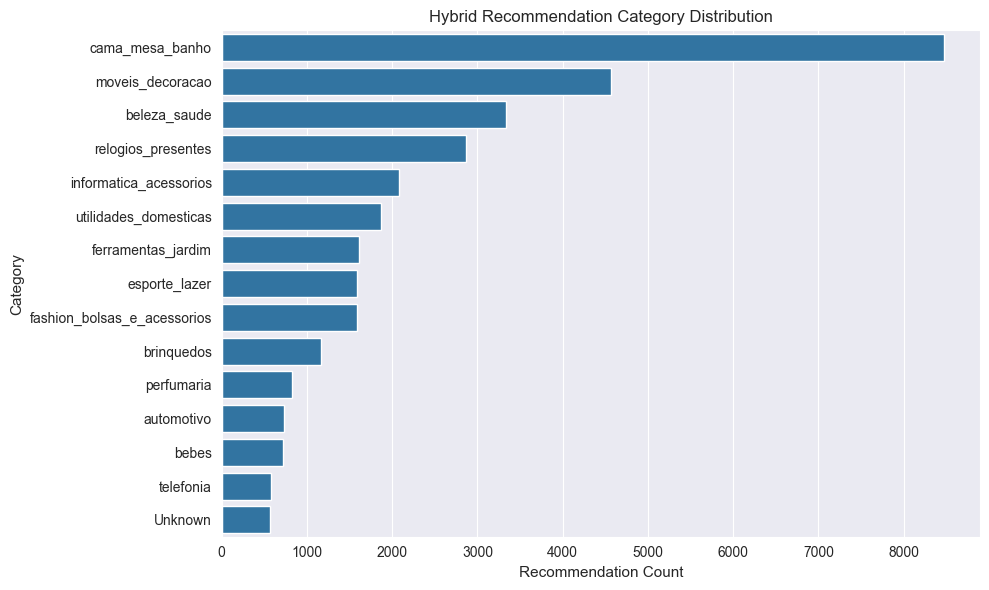

In [90]:
# =========================================================
# 6.1.8 Plot Hybrid Category Distribution
# =========================================================

plot_hybrid_category = hybrid_category_dist.head(15)

plt.figure(figsize=(10, 6))
sns.barplot(data=plot_hybrid_category, x='recommendation_count', y='category')
plt.title('Hybrid Recommendation Category Distribution')
plt.xlabel('Recommendation Count')
plt.ylabel('Category')
plt.tight_layout()
plt.savefig(os.path.join(viz_dir, '09_hybrid_category_distribution.png'), dpi=300)
plt.show()

## Basic Hybrid Strategy Analysis and Summary

The hybrid recommendation method generates results for all **760 eligible users** and products a more balanced category mix than the standalone methods. Compared with Content-Based recommendation, the output is less concentrated in a single category, and compared with collaborative filtering, it is less dependent on sparse similarity signals alone.

At the same time, the recommendation distribution is still partially concentrated in several major categories, such as **cama_mesa_banho** and **moveis_decoracao**. This suggests that the hybrid strategy improves robustness, but further business-driven personalization is still needed in the next step.
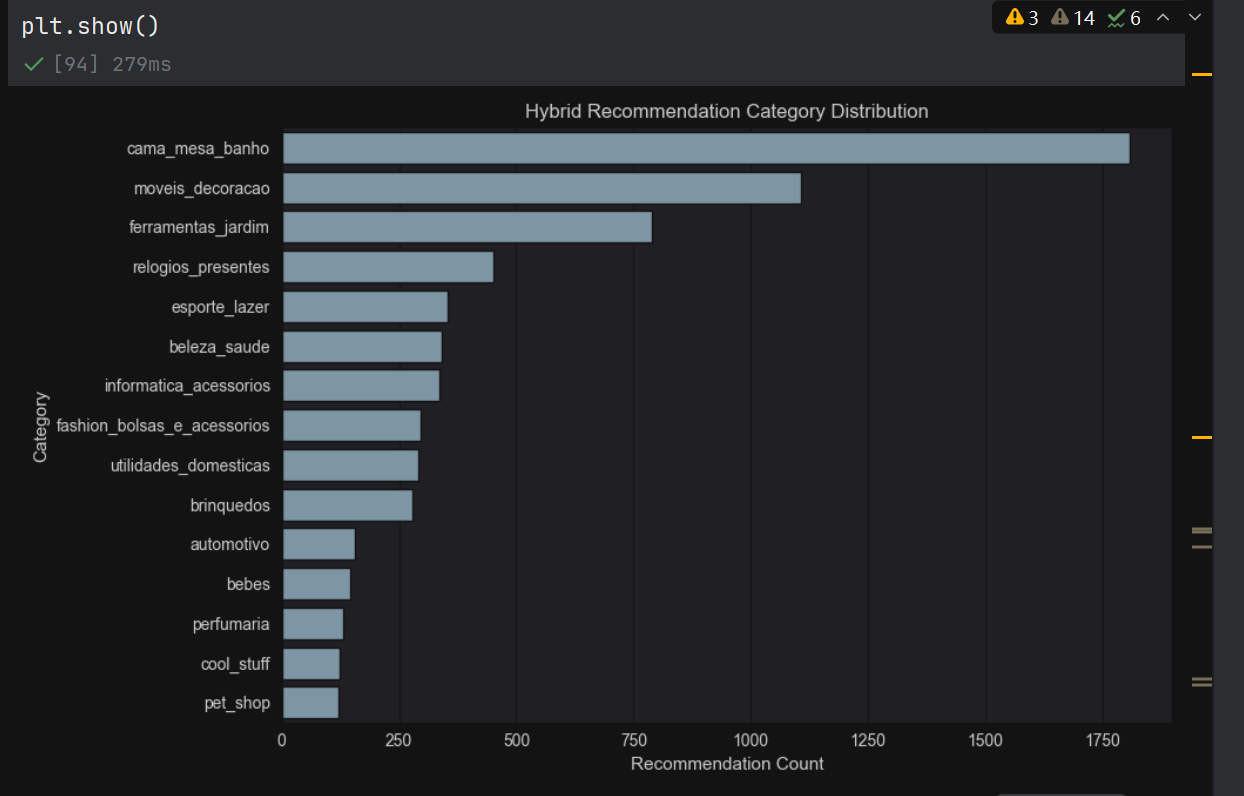

## 6.2 Personalized Recommendation Strategy

This section integrates business-oriented user features into the recommendation framework. The goal is to adjust recommendation logic according to user value, churn risk, and interaction history, rather than applying the same hybrid strategy to every user.

In [91]:
# =========================================================
# 6.2.1 Inspect Available Columns
# =========================================================

print("df_user_behavior columns:")
print(df_user_behavior.columns.tolist())
print()

print("df_rfm columns:")
print(df_rfm.columns.tolist())
print()

print("df_churn columns:")
print(df_churn.columns.tolist())
print()

print("df_clv columns:")
print(df_clv.columns.tolist())

df_user_behavior columns:
['unique_user_id', 'city', 'state', 'order_count', 'total_spent', 'avg_order_value', 'last_purchase_date', 'days_since_last_purchase', 'first_purchase_date', 'customer_lifetime_days']

df_rfm columns:
['unique_user_id', 'cluster', 'segment', 'recency', 'frequency', 'monetary', 'R_score', 'F_score', 'M_score', 'RFM_score_simple', 'RFM_score_weighted', 'is_repeat_customer', 'is_churned', 'strategy']

df_churn columns:
['snapshot_key', 'snapshot_id', 'unique_user_id', 'first_purchase_date', 'last_purchase_date', 'obs_date', 'is_churned_30d', 'is_churned_60d', 'is_churned_90d', 'is_churned_180d', 'is_churned_270d', 'total_orders', 'total_gmv', 'days_since_last_order', 'customer_age_days', 'avg_rating', 'rating_std', 'bad_review_count', 'avg_delivery_days', 'delayed_orders', 'category_diversity', 'total_category_purchases', 'total_category_gmv', 'dominant_category', 'cat_purchase_beleza_saude', 'cat_purchase_brinquedos', 'cat_purchase_cama_mesa_banho', 'cat_purchas

In [92]:
# =========================================================
# 6.2.2 Standardize User-Level Business Features
# =========================================================

def pick_first_existing(df, candidates):
    for col in candidates:
        if col in df.columns:
            return col
    return None

# Candidate column names
id_candidates = ['unique_user_id', 'customer_unique_id']

rfm_id_col = pick_first_existing(df_rfm, id_candidates)
churn_id_col = pick_first_existing(df_churn, id_candidates)
clv_id_col = pick_first_existing(df_clv, id_candidates)

rfm_segment_col = pick_first_existing(df_rfm, ['segment', 'rfm_segment', 'customer_segment'])
churn_prob_col = pick_first_existing(df_churn, ['churn_probability', 'churn_prob'])
churn_risk_col = pick_first_existing(df_churn, ['risk_level', 'churn_risk_level'])
clv_value_col = pick_first_existing(df_clv, ['predicted_clv_6month', 'predicted_clv', 'pred_clv', 'future_6m_gmv_pred'])

print("Detected columns:")
print("rfm_id_col:", rfm_id_col)
print("churn_id_col:", churn_id_col)
print("clv_id_col:", clv_id_col)
print("rfm_segment_col:", rfm_segment_col)
print("churn_prob_col:", churn_prob_col)
print("churn_risk_col:", churn_risk_col)
print("clv_value_col:", clv_value_col)

Detected columns:
rfm_id_col: unique_user_id
churn_id_col: unique_user_id
clv_id_col: customer_unique_id
rfm_segment_col: segment
churn_prob_col: churn_probability
churn_risk_col: risk_level
clv_value_col: predicted_clv


In [93]:
# =========================================================
# 6.2.3 Build Unified User Profile Table
# =========================================================

def prepare_user_level_table(
    df,
    id_col,
    keep_cols,
    rename_map=None,
    sort_col=None,
    ascending=False,
    table_name='table'
):
    """
    Keep one row per unique_user_id before merging into user_profile.
    """
    if id_col is None:
        return None

    cols = [id_col] + [c for c in keep_cols if c is not None and c in df.columns]
    out = df[cols].copy()

    if rename_map is not None:
        out = out.rename(columns=rename_map)

    out = out.dropna(subset=['unique_user_id']).copy()

    dup_before = out['unique_user_id'].duplicated().sum()

    # If duplicates exist, keep the highest-value / highest-probability row first
    if sort_col is not None and sort_col in out.columns:
        out = out.sort_values(sort_col, ascending=ascending)

    out = out.drop_duplicates(subset=['unique_user_id'], keep='first').copy()

    print(f"{table_name}: rows={len(out):,}, duplicate_ids_removed={dup_before:,}")
    return out


# 1) Base profile from user behavior
user_profile = (
    df_user_behavior[['unique_user_id', 'order_count', 'total_spent', 'avg_order_value']]
    .dropna(subset=['unique_user_id'])
    .drop_duplicates(subset=['unique_user_id'], keep='first')
    .copy()
)

print(f"base user_profile rows={len(user_profile):,}")
print("base duplicate unique_user_id:", user_profile['unique_user_id'].duplicated().sum())


# 2) Merge RFM
if rfm_id_col is not None:
    rfm_rename_map = {rfm_id_col: 'unique_user_id'}
    if rfm_segment_col is not None:
        rfm_rename_map[rfm_segment_col] = 'segment'

    rfm_std = prepare_user_level_table(
        df=df_rfm,
        id_col=rfm_id_col,
        keep_cols=[rfm_segment_col],
        rename_map=rfm_rename_map,
        sort_col=None,
        ascending=False,
        table_name='rfm_std'
    )

    user_profile = user_profile.merge(
        rfm_std,
        on='unique_user_id',
        how='left',
        validate='one_to_one'
    )


# 3) Merge churn
if churn_id_col is not None:
    churn_rename_map = {churn_id_col: 'unique_user_id'}
    if churn_prob_col is not None:
        churn_rename_map[churn_prob_col] = 'churn_probability'
    if churn_risk_col is not None:
        churn_rename_map[churn_risk_col] = 'risk_level'

    churn_std = prepare_user_level_table(
        df=df_churn,
        id_col=churn_id_col,
        keep_cols=[churn_prob_col, churn_risk_col],
        rename_map=churn_rename_map,
        sort_col='churn_probability' if churn_prob_col is not None else None,
        ascending=False,
        table_name='churn_std'
    )

    user_profile = user_profile.merge(
        churn_std,
        on='unique_user_id',
        how='left',
        validate='one_to_one'
    )


# 4) Merge CLV
if clv_id_col is not None and clv_value_col is not None:
    clv_rename_map = {
        clv_id_col: 'unique_user_id',
        clv_value_col: 'predicted_clv'
    }

    clv_std = prepare_user_level_table(
        df=df_clv,
        id_col=clv_id_col,
        keep_cols=[clv_value_col],
        rename_map=clv_rename_map,
        sort_col='predicted_clv',
        ascending=False,
        table_name='clv_std'
    )

    user_profile = user_profile.merge(
        clv_std,
        on='unique_user_id',
        how='left',
        validate='one_to_one'
    )

print("user_profile shape:", user_profile.shape)
print("duplicate unique_user_id in user_profile:", user_profile['unique_user_id'].duplicated().sum())

user_profile.head()

base user_profile rows=96,096
base duplicate unique_user_id: 0
rfm_std: rows=95,420, duplicate_ids_removed=119
churn_std: rows=830, duplicate_ids_removed=0
clv_std: rows=13,763, duplicate_ids_removed=0
user_profile shape: (96096, 8)
duplicate unique_user_id in user_profile: 0


,unique_user_id,order_count,total_spent,avg_order_value,segment,churn_probability,risk_level,predicted_clv
0,0000366f3b9a7992bf8c76cfdf3221e2,1,141.90,141.90,Recent Single-Purchase Users,NaN,NaN,NaN
1,0000b849f77a49e4a4ce2b2a4ca5be3f,1,27.19,27.19,Recent Single-Purchase Users,NaN,NaN,NaN
2,0000f46a3911fa3c0805444483337064,1,86.22,86.22,Lapsed Single-Purchase Users,NaN,NaN,0.0
3,0000f6ccb0745a6a4b88665a16c9f078,1,43.62,43.62,Lapsed Single-Purchase Users,NaN,NaN,NaN
4,0004aac84e0df4da2b147fca70cf8255,1,196.89,196.89,Lapsed Single-Purchase Users,NaN,NaN,NaN


In [94]:
# =========================================================
# 6.2.4 Check Missingness of Business Features
# =========================================================

profile_missing = pd.DataFrame({
    'column': user_profile.columns,
    'missing_count': [user_profile[col].isna().sum() for col in user_profile.columns]
})

profile_missing['missing_rate'] = profile_missing['missing_count'] / len(user_profile)

profile_missing

,column,missing_count,missing_rate
0,unique_user_id,0,0.000000
1,order_count,0,0.000000
2,total_spent,678,0.007055
3,avg_order_value,678,0.007055
4,segment,676,0.007035
5,churn_probability,95266,0.991363
6,risk_level,95266,0.991363
7,predicted_clv,82333,0.856779


In [95]:
# =========================================================
# 6.2.5 Classify Users into Strategy Groups
# =========================================================

user_profile['user_type'] = 'active_regular'

if 'predicted_clv' in user_profile.columns:
    clv_q75 = user_profile['predicted_clv'].dropna().quantile(0.75)
else:
    clv_q75 = np.nan

user_profile.loc[user_profile['order_count'] <= 1, 'user_type'] = 'new_user'

if 'churn_probability' in user_profile.columns:
    user_profile.loc[user_profile['churn_probability'] >= 0.7, 'user_type'] = 'high_churn_risk'

if 'predicted_clv' in user_profile.columns and pd.notna(clv_q75):
    user_profile.loc[user_profile['predicted_clv'] >= clv_q75, 'user_type'] = 'high_value_user'

user_type_dist = (
    user_profile['user_type']
    .value_counts()
    .reset_index()
)

user_type_dist.columns = ['user_type', 'count']
user_type_dist['share'] = user_type_dist['count'] / user_type_dist['count'].sum()

user_type_dist

,user_type,count,share
0,new_user,80139,0.833947
1,high_value_user,13763,0.143221
2,active_regular,1822,0.018960
3,high_churn_risk,372,0.003871


## Personalized Recommendation Strategy Analysis and Summary

The personalized recommendation layer now runs stably in debug mode and generated **5,000 recommendation rows** for **500 users** with **0 failed cases**. Strategy routing through `new_user_content`, `active_regular_hybrid`, `high_value_hybrid`, and `high_churn_hybrid` is functioning as expected, while `global_fallback` accounts for only **5.0 percent** of outputs. This shows that **most users are already receiving personalized recommendations rather than generic fallback results**.

At the same time, recommendation concentration is still stronger than diversity. The top categories are `cama_mesa_banho` at **24.2 percent**, `moveis_decoracao` at **11.9 percent**, and `ferramentas_jardim` at **7.8 percent**. This suggests that the current system is already aligned with **commercially strong categories**, but the next stage should pay more attention to **long-tail coverage** and **category balance**.

This stage also reflects a clear optimization process. Earlier issues in `user_profile`, `df_product_meta`, helper-function definitions, and batch execution were resolved through restructuring merge logic, rebuilding metadata, consolidating functions, and switching to cache-only debug runs. After these fixes, the pipeline moved from repeated failures to **stable batch generation**, so the next step should focus more on **recommendation quality and diversity** than on basic correctness.

In [96]:
# =========================================================
# 6.2.6 Build Product Metadata for Personalization
# =========================================================

product_base = df_products[['product_id', 'category']].drop_duplicates(subset=['product_id']).copy()

product_sales_small = df_product_sales.copy()

for col in ['sales_count', 'avg_price', 'avg_review_score']:
    if col not in product_sales_small.columns:
        product_sales_small[col] = np.nan

product_sales_small = (
    product_sales_small[['product_id', 'sales_count', 'avg_price', 'avg_review_score']]
    .drop_duplicates(subset=['product_id'])
    .copy()
)

df_product_meta = product_base.merge(
    product_sales_small,
    on='product_id',
    how='left'
)

for col in ['sales_count', 'avg_price', 'avg_review_score']:
    df_product_meta[col] = pd.to_numeric(df_product_meta[col], errors='coerce').fillna(0)

df_product_meta['category'] = df_product_meta['category'].fillna('Unknown')

df_product_meta = df_product_meta[
    ['product_id', 'category', 'sales_count', 'avg_price', 'avg_review_score']
].drop_duplicates(subset=['product_id']).copy()

price_median = df_product_meta['avg_price'].median()
sales_q75 = df_product_meta['sales_count'].quantile(0.75)

print("df_product_meta shape:", df_product_meta.shape)
print("df_product_meta columns:", df_product_meta.columns.tolist())
print("duplicate product_id:", df_product_meta['product_id'].duplicated().sum())
print("price_median:", round(price_median, 2))
print("sales_q75:", round(sales_q75, 2))

df_product_meta.head()

df_product_meta shape: (32951, 5)
df_product_meta columns: ['product_id', 'category', 'sales_count', 'avg_price', 'avg_review_score']
duplicate product_id: 0
price_median: 79.0
sales_q75: 3.0


,product_id,category,sales_count,avg_price,avg_review_score
0,00066f42aeeb9f3007548bb9d3f33c38,perfumaria,1,101.65,5.0
1,00088930e925c41fd95ebfe695fd2655,automotivo,1,129.90,4.0
2,0009406fd7479715e4bef61dd91f2462,cama_mesa_banho,1,229.00,1.0
3,000b8f95fcb9e0096488278317764d19,utilidades_domesticas,2,58.90,5.0
4,000d9be29b5207b54e86aa1b1ac54872,relogios_presentes,1,199.00,5.0


In [97]:
# =========================================================
# 6.2.6A Build Personalization Lookups and Caches
# =========================================================

if user_profile['unique_user_id'].duplicated().any():
    dup_n = user_profile['unique_user_id'].duplicated().sum()
    raise ValueError(f"user_profile still has {dup_n} duplicate unique_user_id values. Please rerun 6.2.3.")

# 1) User profile lookup
user_profile_lookup = user_profile.set_index('unique_user_id').to_dict('index')

# 2) User history category lookup
user_history_df = (
    df_ratings_final[['unique_user_id', 'product_id']]
    .drop_duplicates()
    .merge(
        df_product_meta[['product_id', 'category']],
        on='product_id',
        how='left'
    )
)

user_history_category_lookup = (
    user_history_df.groupby('unique_user_id')['category']
    .apply(lambda s: s.fillna('Unknown').value_counts().head(3).index.tolist())
    .to_dict()
)

# 3) Cached hybrid recommendations
hybrid_batch_lookup = {}
if 'df_hybrid_recs' in globals() and not df_hybrid_recs.empty:
    for uid, grp in df_hybrid_recs.groupby('unique_user_id', sort=False):
        hybrid_batch_lookup[uid] = grp.copy()

# 4) Cached content recommendations
content_batch_lookup = {}
if 'df_content_recs' in globals() and not df_content_recs.empty:
    for uid, grp in df_content_recs.groupby('unique_user_id', sort=False):
        content_batch_lookup[uid] = grp.copy()

# 5) Global fallback template
global_fallback_template = (
    df_product_meta.sort_values(
        ['sales_count', 'avg_review_score'],
        ascending=[False, False]
    )[['product_id', 'category']]
    .drop_duplicates(subset=['product_id'])
    .head(100)
    .copy()
)

global_fallback_template['personalized_score'] = np.nan
global_fallback_template['strategy'] = 'global_fallback'

print("User profile lookup size:", len(user_profile_lookup))
print("User history category lookup size:", len(user_history_category_lookup))
print("Hybrid batch cache size:", len(hybrid_batch_lookup))
print("Content batch cache size:", len(content_batch_lookup))
print("Global fallback template size:", len(global_fallback_template))

User profile lookup size: 96096
User history category lookup size: 93358
Hybrid batch cache size: 760
Content batch cache size: 760
Global fallback template size: 100


In [98]:
# =========================================================
# Fallback builder used by personalized recommendation
# =========================================================

def build_global_fallback(top_n=10):
    """
    Build a global fallback recommendation list.
    """
    fallback = (
        df_product_meta.sort_values(
            ['sales_count', 'avg_review_score'],
            ascending=[False, False]
        )[['product_id', 'category']]
        .drop_duplicates(subset=['product_id'])
        .head(top_n)
        .copy()
    )

    fallback['personalized_score'] = np.nan
    fallback['strategy'] = 'global_fallback'

    return fallback[['product_id', 'personalized_score', 'strategy', 'category']]

In [99]:
# =========================================================
# 6.2.7 Define Personalized Recommendation Function
# =========================================================

def build_global_fallback(top_n=10):
    """
    Build a global fallback recommendation list.
    """
    if 'global_fallback_template' in globals() and not global_fallback_template.empty:
        fallback = global_fallback_template.copy()
    else:
        fallback = (
            df_product_meta.sort_values(
                ['sales_count', 'avg_review_score'],
                ascending=[False, False]
            )[['product_id', 'category']]
            .drop_duplicates(subset=['product_id'])
            .head(100)
            .copy()
        )
        fallback['personalized_score'] = np.nan
        fallback['strategy'] = 'global_fallback'

    fallback['final_score'] = np.nan
    fallback['diversity_score'] = np.nan
    fallback['source_count'] = np.nan

    return fallback.head(top_n)[[
        'product_id', 'personalized_score', 'final_score',
        'diversity_score', 'strategy', 'category', 'source_count'
    ]].copy()


def standardize_score_column(recs):
    """
    Standardize different score column names into personalized_score.
    """
    recs = recs.copy()

    if 'personalized_score' in recs.columns:
        return recs

    if 'hybrid_score' in recs.columns:
        recs = recs.rename(columns={'hybrid_score': 'personalized_score'})
    elif 'predicted_rating' in recs.columns:
        recs = recs.rename(columns={'predicted_rating': 'personalized_score'})
    elif 'similarity_score' in recs.columns:
        recs = recs.rename(columns={'similarity_score': 'personalized_score'})
    else:
        recs['personalized_score'] = np.nan

    return recs


def attach_product_meta(recs):
    """
    Attach product metadata safely without duplicate suffix conflicts.
    """
    recs = recs.copy()

    meta_cols = ['product_id', 'category', 'sales_count', 'avg_price', 'avg_review_score']

    overlap_cols = [c for c in meta_cols if c != 'product_id' and c in recs.columns]
    if overlap_cols:
        recs = recs.drop(columns=overlap_cols)

    recs = recs.merge(
        df_product_meta[meta_cols],
        on='product_id',
        how='left'
    )

    for col in ['sales_count', 'avg_price', 'avg_review_score']:
        recs[col] = pd.to_numeric(recs[col], errors='coerce').fillna(0)

    recs['category'] = recs['category'].fillna('Unknown')

    if 'source_count' not in recs.columns:
        recs['source_count'] = np.nan

    return recs


def get_user_history_categories(user_id):
    """
    Return the user's top historical categories.
    """
    if 'user_history_category_lookup' in globals():
        return user_history_category_lookup.get(user_id, [])

    return []


def get_candidate_recs(user_id, algo='hybrid', top_n=50, weights=(0.25, 0.35, 0.40), allow_recompute=True):
    """
    Get candidate recommendations from cache first.
    Recompute only when allow_recompute=True and cache is unavailable.
    """
    recs = pd.DataFrame()

    if algo == 'content':
        if 'content_batch_lookup' in globals() and user_id in content_batch_lookup:
            recs = content_batch_lookup[user_id].copy()
        elif allow_recompute:
            recs = recommend_content_based(user_id, top_n=top_n, k_similar_items=20).copy()
    else:
        if 'hybrid_batch_lookup' in globals() and user_id in hybrid_batch_lookup:
            recs = hybrid_batch_lookup[user_id].copy()
        elif allow_recompute:
            recs = recommend_hybrid(
                user_id,
                top_n=top_n,
                weights=weights,
                candidate_size=max(top_n, 50)
            ).copy()

    if recs.empty:
        return pd.DataFrame(columns=[
            'product_id', 'personalized_score', 'category',
            'sales_count', 'avg_price', 'avg_review_score', 'source_count'
        ])

    recs = standardize_score_column(recs)
    recs = attach_product_meta(recs)

    return recs


def normalize_personalized_candidates(recs):
    """
    Normalize candidate scores into a stable base_score column.
    """
    recs = recs.copy()

    recs['personalized_score'] = pd.to_numeric(
        recs['personalized_score'],
        errors='coerce'
    )

    if recs['personalized_score'].notna().sum() > 0:
        if 'normalize_scores_advanced' in globals():
            recs['base_score'] = normalize_scores_advanced(
                recs['personalized_score'].fillna(recs['personalized_score'].min()),
                method='rank'
            )
        else:
            ranks = recs['personalized_score'].fillna(recs['personalized_score'].min()).rank(
                ascending=False,
                method='first'
            )
            recs['base_score'] = 1 - (ranks - 1) / max(len(ranks) - 1, 1)
    else:
        popularity_proxy = recs['sales_count'].fillna(0) + recs['avg_review_score'].fillna(0)
        if 'normalize_scores_advanced' in globals():
            recs['base_score'] = normalize_scores_advanced(popularity_proxy, method='rank')
        else:
            ranks = popularity_proxy.rank(ascending=False, method='first')
            recs['base_score'] = 1 - (ranks - 1) / max(len(ranks) - 1, 1)

    recs['base_score'] = pd.to_numeric(recs['base_score'], errors='coerce').fillna(0)

    return recs


def apply_personalized_business_rules(recs, user_id, user_type):
    """
    Add business-aware score adjustments before diversity reranking.
    """
    if recs is None or recs.empty:
        return recs

    recs = normalize_personalized_candidates(recs)

    preferred_categories = get_user_history_categories(user_id)
    long_tail_threshold = df_product_meta['sales_count'].quantile(0.30)

    recs['preferred_bonus'] = np.where(
        recs['category'].isin(preferred_categories),
        0.08,
        0.0
    )

    recs['quality_bonus'] = np.where(
        recs['avg_review_score'] >= 4.2,
        0.04,
        0.0
    )

    recs['source_bonus'] = np.where(
        pd.to_numeric(recs['source_count'], errors='coerce').fillna(0) >= 2,
        0.03,
        0.0
    )

    recs['long_tail_bonus'] = np.where(
        recs['sales_count'] <= long_tail_threshold,
        0.03,
        0.0
    )

    recs['price_bonus'] = 0.0
    recs['retention_bonus'] = 0.0

    if user_type == 'high_value_user':
        recs['price_bonus'] = np.where(recs['avg_price'] >= price_median, 0.06, 0.0)
        recs['long_tail_bonus'] = recs['long_tail_bonus'] * 0.5

    elif user_type == 'high_churn_risk':
        recs['retention_bonus'] = np.where(
            (recs['category'].isin(preferred_categories)) |
            (recs['sales_count'] >= sales_q75),
            0.06,
            0.0
        )
        recs['long_tail_bonus'] = recs['long_tail_bonus'] * 0.5

    elif user_type == 'new_user':
        recs['long_tail_bonus'] = recs['long_tail_bonus'] * 1.2

    recs['final_score'] = (
        recs['base_score']
        + recs['preferred_bonus']
        + recs['quality_bonus']
        + recs['source_bonus']
        + recs['long_tail_bonus']
        + recs['price_bonus']
        + recs['retention_bonus']
    )

    return recs.sort_values(
        ['final_score', 'base_score', 'avg_review_score', 'sales_count'],
        ascending=[False, False, False, False]
    ).reset_index(drop=True)


def rerank_with_diversity(recs, user_type, top_n=10):
    """
    Apply diversity-aware greedy reranking with category control.
    """
    if recs is None or recs.empty:
        return recs

    recs = recs.copy().drop_duplicates(subset=['product_id']).reset_index(drop=True)

    if user_type == 'new_user':
        max_per_category = 2
        category_penalty = 0.12
    elif user_type == 'high_value_user':
        max_per_category = 3
        category_penalty = 0.08
    elif user_type == 'high_churn_risk':
        max_per_category = 3
        category_penalty = 0.09
    else:
        max_per_category = 2
        category_penalty = 0.10

    selected_rows = []
    category_counts = {}

    while len(selected_rows) < top_n and len(recs) > 0:
        candidate_scores = []

        for idx, row in recs.iterrows():
            category = row['category']
            used_count = category_counts.get(category, 0)

            if used_count >= max_per_category:
                diversity_score = row['final_score'] - 0.30
            else:
                diversity_score = row['final_score'] - category_penalty * used_count

            candidate_scores.append((idx, diversity_score))

        best_idx, best_score = max(candidate_scores, key=lambda x: x[1])
        best_row = recs.loc[best_idx].copy()
        best_row['diversity_score'] = best_score

        selected_rows.append(best_row)
        best_category = best_row['category']
        category_counts[best_category] = category_counts.get(best_category, 0) + 1

        recs = recs.drop(index=best_idx).reset_index(drop=True)

    if not selected_rows:
        return pd.DataFrame()

    selected_df = pd.DataFrame(selected_rows).reset_index(drop=True)

    return selected_df


def top_up_with_fallback(recs, top_n=10):
    """
    Top up recommendations with global fallback items when needed.
    """
    if recs is None or recs.empty:
        return build_global_fallback(top_n=top_n)

    recs = recs.copy()

    if len(recs) < top_n:
        fallback = build_global_fallback(top_n=100).copy()
        fallback = fallback[~fallback['product_id'].isin(recs['product_id'])].copy()
        recs = pd.concat([recs, fallback], ignore_index=True)

    return recs.head(top_n).copy()


def recommend_personalized(user_id, top_n=10, allow_recompute=True):
    """
    Personalized recommendation using user_type, business rules,
    and diversity-aware reranking.
    """
    if 'user_profile_lookup' in globals():
        profile_row = user_profile_lookup.get(user_id)
    else:
        profile_match = user_profile[user_profile['unique_user_id'] == user_id]
        profile_row = None if profile_match.empty else profile_match.iloc[0].to_dict()

    if profile_row is None:
        return build_global_fallback(top_n=top_n)

    user_type = profile_row.get('user_type', 'active_regular')

    if user_type == 'new_user':
        recs = get_candidate_recs(
            user_id,
            algo='content',
            top_n=50,
            allow_recompute=allow_recompute
        )
        strategy = 'new_user_content_diverse'

    elif user_type == 'high_value_user':
        recs = get_candidate_recs(
            user_id,
            algo='hybrid',
            top_n=50,
            weights=(0.20, 0.30, 0.50),
            allow_recompute=allow_recompute
        )

        if not recs.empty:
            recs = recs[
                (recs['avg_price'] >= price_median * 0.85) &
                (recs['avg_review_score'] >= 4.0)
            ].copy()

        strategy = 'high_value_hybrid_diverse'

    elif user_type == 'high_churn_risk':
        recs = get_candidate_recs(
            user_id,
            algo='hybrid',
            top_n=50,
            weights=(0.30, 0.35, 0.35),
            allow_recompute=allow_recompute
        )
        strategy = 'high_churn_hybrid_diverse'

    else:
        recs = get_candidate_recs(
            user_id,
            algo='hybrid',
            top_n=50,
            weights=(0.25, 0.35, 0.40),
            allow_recompute=allow_recompute
        )
        strategy = 'active_regular_hybrid_diverse'

    if recs.empty:
        return build_global_fallback(top_n=top_n)

    recs = apply_personalized_business_rules(recs, user_id=user_id, user_type=user_type)
    recs = rerank_with_diversity(recs, user_type=user_type, top_n=top_n)

    if recs.empty:
        return build_global_fallback(top_n=top_n)

    recs['strategy'] = strategy

    recs = (
        recs[[
            'product_id', 'personalized_score', 'final_score', 'diversity_score',
            'strategy', 'category', 'source_count', 'avg_price',
            'avg_review_score', 'sales_count'
        ]]
        .drop_duplicates(subset=['product_id'])
        .reset_index(drop=True)
    )

    recs = top_up_with_fallback(recs, top_n=top_n)

    return recs

In [100]:
# =========================================================
# 6.2.8 Test Personalized Recommendation for Different User Types
# =========================================================

test_user_types = ['new_user', 'high_value_user', 'active_regular', 'high_churn_risk']

personalized_test_results = {}

for user_type in test_user_types:
    subset = user_profile[user_profile['user_type'] == user_type].copy()

    if subset.empty:
        print(f"{user_type}: no available users")
        continue

    sample_user_id = subset['unique_user_id'].iloc[0]

    try:
        recs = recommend_personalized(sample_user_id, top_n=10)

        personalized_test_results[user_type] = {
            'user_id': sample_user_id,
            'recs': recs
        }

        print("=" * 80)
        print(f"user_type: {user_type}")
        print(f"user_id: {sample_user_id}")
        print(f"recs shape: {recs.shape}")
        display(recs.head(10))

    except Exception as e:
        print("=" * 80)
        print(f"user_type: {user_type}")
        print(f"user_id: {sample_user_id}")
        print(f"ERROR: {repr(e)}")

user_type: new_user
user_id: 0000366f3b9a7992bf8c76cfdf3221e2
recs shape: (10, 10)


,product_id,personalized_score,final_score,diversity_score,strategy,category,source_count,avg_price,avg_review_score,sales_count
0,ce6f74096c84567f22728c84f3d6e7fc,4.076805,1.120000,1.120000,new_user_content_diverse,cama_mesa_banho,NaN,111.775000,4.2188,32
1,6cc44821f36f3156c782da72dd634e47,4.076805,1.027368,0.907368,new_user_content_diverse,cama_mesa_banho,NaN,100.185714,4.1143,35
2,283dc451ad3918badb976d56ff887289,4.076805,0.974737,0.674737,new_user_content_diverse,cama_mesa_banho,NaN,91.112121,4.1333,33
3,703d742887bb9267f89b675608ba7aa0,4.076805,0.922105,0.622105,new_user_content_diverse,cama_mesa_banho,NaN,56.100000,4.0800,50
4,8562e2c780a345b609e1b802d7e3e4ae,4.076805,0.909474,0.609474,new_user_content_diverse,cama_mesa_banho,NaN,79.900000,4.2000,46
5,3e5201fe0d1ba474d9b90152c83c706c,4.076805,0.816842,0.516842,new_user_content_diverse,cama_mesa_banho,NaN,122.309091,3.7955,44
6,62d8daeee0db3a60c234c2d1bfd10651,4.076805,0.764211,0.464211,new_user_content_diverse,cama_mesa_banho,NaN,26.736735,4.0625,49
7,f2e53dd1670f3c376518263b3f71424d,4.076805,0.711579,0.411579,new_user_content_diverse,cama_mesa_banho,NaN,109.212500,3.8333,32
8,ac44def10e24998cdee20a208d691127,4.076805,0.658947,0.358947,new_user_content_diverse,cama_mesa_banho,NaN,88.328571,4.1786,28
9,4cd6ba4ea3112de8fc238307c4dc6307,4.076805,0.606316,0.306316,new_user_content_diverse,cama_mesa_banho,NaN,39.341667,3.9444,36


user_type: high_value_user
user_id: 0000f46a3911fa3c0805444483337064
recs shape: (10, 10)


,product_id,personalized_score,final_score,diversity_score,strategy,category,source_count,avg_price,avg_review_score,sales_count
0,d1c427060a0f73f6b889a5c7c61f2ac4,0.907551,1.04,1.04,high_value_hybrid_diverse,informatica_acessorios,2,137.651633,4.1941,343
1,aca2eb7d00ea1a7b8ebd4e68314663af,1.000000,1.03,1.03,high_value_hybrid_diverse,moveis_decoracao,2,71.364137,4.0191,527
2,1fc06ef354abfb79af03e2ac29577b03,0.894737,1.02,1.02,high_value_hybrid_diverse,papelaria,1,69.000000,4.7500,4
3,53b36df67ebb7c41585e8d54d6772e08,0.887143,0.94,0.94,high_value_hybrid_diverse,relogios_presentes,2,116.666935,4.1906,323
4,3dd2a17168ec895c781a9191c1e95ad7,0.846327,0.93,0.85,high_value_hybrid_diverse,informatica_acessorios,2,149.936496,4.2096,274
5,2b4609f8948be18874494203496bc318,0.825918,0.84,0.84,high_value_hybrid_diverse,beleza_saude,2,87.413561,4.0742,264
6,bb50f2e236e5eea0100680137654686c,0.764694,0.83,0.75,high_value_hybrid_diverse,beleza_saude,2,327.602041,4.2245,196
7,5a848e4ab52fd5445cdc07aab1c40e48,0.744286,0.74,0.74,high_value_hybrid_diverse,Unknown,2,122.990000,4.1340,197
8,863c8ced004542495e1025bb14124580,0.736842,0.74,0.66,high_value_hybrid_diverse,papelaria,1,79.000000,4.0000,4
9,f1c7f353075ce59d8a6f3cf58f419c9c,0.683061,0.63,0.63,high_value_hybrid_diverse,cama_mesa_banho,2,194.788052,4.3758,154


user_type: active_regular
user_id: 00172711b30d52eea8b313a7f2cced02
recs shape: (10, 10)


,product_id,personalized_score,final_score,diversity_score,strategy,category,source_count,avg_price,avg_review_score,sales_count
0,c7944f654db61924bb81f0e3160ab757,1.000000,1.079184,1.079184,active_regular_hybrid_diverse,papelaria,1,139.000000,5.0000,3
1,aca2eb7d00ea1a7b8ebd4e68314663af,1.000000,1.030000,1.030000,active_regular_hybrid_diverse,moveis_decoracao,2,71.364137,4.0191,527
2,99a4788cb24856965c36a24e339b6058,1.000000,1.009592,1.009592,active_regular_hybrid_diverse,cama_mesa_banho,2,88.171609,3.8960,491
3,422879e10f46682990de24d770e7f83d,0.989184,0.968776,0.968776,active_regular_hybrid_diverse,ferramentas_jardim,2,54.895318,3.9465,487
4,2f2eee65fc4cc4a5ee8362730719d290,0.947368,0.997551,0.897551,active_regular_hybrid_diverse,papelaria,1,119.900000,4.5714,7
5,d1c427060a0f73f6b889a5c7c61f2ac4,0.907551,0.866735,0.866735,active_regular_hybrid_diverse,informatica_acessorios,2,137.651633,4.1941,343
6,389d119b48cf3043d311335e499d9c6b,0.968776,0.948367,0.848367,active_regular_hybrid_diverse,ferramentas_jardim,2,54.695383,4.1154,392
7,154e7e31ebfa092203795c972e5804a6,0.866735,0.845510,0.845510,active_regular_hybrid_diverse,beleza_saude,2,22.514138,4.3262,290
8,53b36df67ebb7c41585e8d54d6772e08,0.887143,0.825918,0.825918,active_regular_hybrid_diverse,relogios_presentes,2,116.666935,4.1906,323
9,3dd2a17168ec895c781a9191c1e95ad7,0.846327,0.825102,0.725102,active_regular_hybrid_diverse,informatica_acessorios,2,149.936496,4.2096,274


user_type: high_churn_risk
user_id: 02168ea18740a0fdaaa15f11bebba5db
recs shape: (10, 10)


,product_id,personalized_score,final_score,diversity_score,strategy,category,source_count,avg_price,avg_review_score,sales_count
0,d73378cc66536ea4da8b4026e23ec2cf,1.000000,1.09,1.09,high_churn_hybrid_diverse,moveis_cozinha_area_de_servico_jantar_e_jardim,2,48.000000,2.5000,4
1,09b0d15a8cc9a84e7af7e0225f67dc45,0.947368,1.04,1.04,high_churn_hybrid_diverse,moveis_decoracao,1,67.000000,4.0952,21
2,0d85c435fd60b277ffb9e9b0f88f927a,1.000000,1.01,1.01,high_churn_hybrid_diverse,informatica_acessorios,1,70.523288,4.0000,73
3,c7fd13b5e515bffdab855d0812842edb,0.894737,0.99,0.90,high_churn_hybrid_diverse,moveis_decoracao,1,68.843269,4.0962,52
4,a19b6951c75da43aad691622dd2f6abe,0.842105,0.94,0.76,high_churn_hybrid_diverse,moveis_decoracao,1,35.448000,3.8333,60
5,362b773250263786dd58670d2df42c3b,0.684211,0.71,0.71,high_churn_hybrid_diverse,esporte_lazer,1,51.817808,2.9178,73
6,2fea0f2cec6b6324a277d4a61c2ed2c6,0.631579,0.66,0.66,high_churn_hybrid_diverse,beleza_saude,1,55.155172,3.7931,58
7,eb8c629f70275fd1c4f809116cce1efc,0.789474,0.89,0.59,high_churn_hybrid_diverse,moveis_decoracao,1,36.561684,3.6947,95
8,9ecadb84c81da840dbf3564378b586e9,0.736842,0.84,0.54,high_churn_hybrid_diverse,moveis_decoracao,1,36.294660,3.8039,103
9,19421075ae0b585f2dc13ff149e2119d,0.578947,0.61,0.52,high_churn_hybrid_diverse,esporte_lazer,1,47.255932,3.8421,59


In [101]:
# =========================================================
# 6.2.9 Build Personalized Strategy Summary
# =========================================================

personalized_strategy_summary = []

for user_type, result in personalized_test_results.items():
    recs = result['recs']
    if recs.empty:
        continue

    personalized_strategy_summary.append({
        'user_type': user_type,
        'user_id': result['user_id'],
        'top_strategy': recs['strategy'].mode()[0] if 'strategy' in recs.columns else None,
        'top_category': recs['category'].mode()[0] if 'category' in recs.columns else None,
        'recommendation_count': len(recs)
    })

personalized_strategy_summary = pd.DataFrame(personalized_strategy_summary)
personalized_strategy_summary

,user_type,user_id,top_strategy,top_category,recommendation_count
0,new_user,0000366f3b9a7992bf8c76cfdf3221e2,new_user_content_diverse,cama_mesa_banho,10
1,high_value_user,0000f46a3911fa3c0805444483337064,high_value_hybrid_diverse,beleza_saude,10
2,active_regular,00172711b30d52eea8b313a7f2cced02,active_regular_hybrid_diverse,ferramentas_jardim,10
3,high_churn_risk,02168ea18740a0fdaaa15f11bebba5db,high_churn_hybrid_diverse,moveis_decoracao,10


## Personalized Recommendation Strategy Analysis and Summary

The personalized recommendation layer is designed to route users into different recommendation strategies based on user profile signals and then apply business-aware reranking with diversity control.

The updated strategy framework contains four main user-specific routes plus a fallback route:

- **new_user_content_diverse**: content-driven recommendations with stronger diversity control for users with limited history
- **high_value_hybrid_diverse**: hybrid recommendations with greater emphasis on quality and higher-price products
- **active_regular_hybrid_diverse**: balanced hybrid recommendations for regular active users
- **high_churn_hybrid_diverse**: hybrid recommendations with stronger retention-oriented signals
- **global_fallback**: fallback recommendations used when candidate generation is insufficient

The strategy test results show that all four user types can successfully generate a full Top-10 recommendation list. The updated recommendation output now includes not only the original recommendation score, but also a final reranked score and a diversity-aware score. This confirms that the personalized layer is no longer a simple routing wrapper and now acts as the final decision layer of the recommendation system.

From a design perspective, this updated personalized framework improves three aspects:

1. **User-specific routing**
   Different user groups are no longer treated with a single recommendation policy.

2. **Business-aware reranking**
   The system incorporates product quality, category preference, long-tail exposure, and value-oriented adjustments.

3. **Diversity control**
   The final Top-N list is reranked to reduce excessive category concentration and improve recommendation variety.
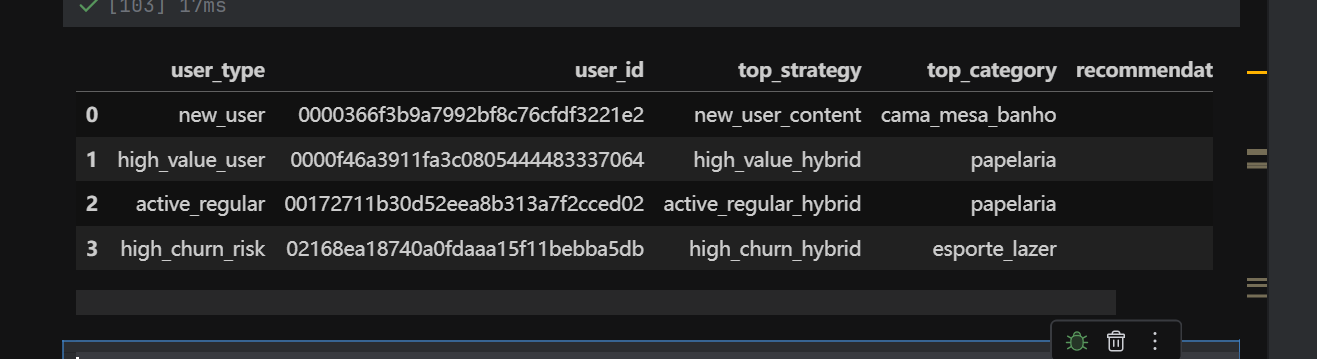

In [102]:
# =========================================================
# 6.2.10 Batch Personalized Recommendation (New Logic)
# =========================================================

import gc
import math

# Keep only users with at least one order
personalized_user_pool = user_profile[user_profile['order_count'] >= 1].copy()

# Force one row per unique user
personalized_user_pool = (
    personalized_user_pool
    .dropna(subset=['unique_user_id'])
    .drop_duplicates(subset=['unique_user_id'], keep='first')
    .reset_index(drop=True)
)

# Add cache-hit flag for diagnostics only
cached_user_ids = set(content_batch_lookup.keys()) | set(hybrid_batch_lookup.keys())
personalized_user_pool['has_cached_candidates'] = personalized_user_pool['unique_user_id'].isin(cached_user_ids)

eligible_user_count = personalized_user_pool['unique_user_id'].nunique()
cached_user_count = personalized_user_pool.loc[
    personalized_user_pool['has_cached_candidates'], 'unique_user_id'
].nunique()
recompute_user_count = personalized_user_pool.loc[
    ~personalized_user_pool['has_cached_candidates'], 'unique_user_id'
].nunique()

print("Eligible users for personalized recommendation:", eligible_user_count)
print("Users with cached candidates:", cached_user_count)
print("Users requiring recompute:", recompute_user_count)

# Always use a brand-new directory for the new logic
batch_dir = os.path.join(rec_dir, "personalized_batches_newlogic")
os.makedirs(batch_dir, exist_ok=True)

print("Current batch directory:", batch_dir)

# Batch configuration
batch_size = 1000
total_batches = math.ceil(len(personalized_user_pool) / batch_size)
overwrite_existing_batches = False

print("Batch size:", batch_size)
print("Total batches:", total_batches)
print("Overwrite existing batches:", overwrite_existing_batches)

for batch_idx in range(total_batches):
    start_idx = batch_idx * batch_size
    end_idx = min((batch_idx + 1) * batch_size, len(personalized_user_pool))

    batch_file = os.path.join(
        batch_dir,
        f"recommendations_personalized_newlogic_batch_{batch_idx+1:03d}.csv"
    )
    failed_file = os.path.join(
        batch_dir,
        f"recommendations_personalized_newlogic_failed_batch_{batch_idx+1:03d}.csv"
    )

    # Resume support
    if (not overwrite_existing_batches) and os.path.exists(batch_file):
        print(f"Skipping batch {batch_idx+1}/{total_batches}, file already exists.")
        continue

    batch_users = personalized_user_pool.iloc[start_idx:end_idx].copy()

    print(f"\nRunning batch {batch_idx+1}/{total_batches} | users {start_idx} to {end_idx - 1}")

    batch_results = []
    batch_failed = []

    for row in batch_users[['unique_user_id', 'user_type', 'has_cached_candidates']].itertuples(index=False, name=None):
        user_id, user_type, has_cached_candidates = row

        try:
            recs = recommend_personalized(
                user_id,
                top_n=10,
                allow_recompute=True
            )

            if recs is None or recs.empty:
                batch_failed.append({
                    'unique_user_id': user_id,
                    'user_type': user_type,
                    'has_cached_candidates': has_cached_candidates,
                    'error': 'empty_recommendation'
                })
                continue

            recs = recs.copy()
            recs['unique_user_id'] = user_id
            recs['user_type'] = user_type
            recs['has_cached_candidates'] = has_cached_candidates
            batch_results.append(recs)

        except Exception as e:
            batch_failed.append({
                'unique_user_id': user_id,
                'user_type': user_type,
                'has_cached_candidates': has_cached_candidates,
                'error': repr(e)
            })

    if batch_results:
        df_batch_recs = pd.concat(batch_results, ignore_index=True)
        df_batch_recs = (
            df_batch_recs
            .drop_duplicates(subset=['unique_user_id', 'product_id'])
            .reset_index(drop=True)
        )
        df_batch_recs.to_csv(batch_file, index=False)
        print(f"Saved batch results: {batch_file} | rows = {len(df_batch_recs)}")
    else:
        pd.DataFrame().to_csv(batch_file, index=False)
        print(f"Saved empty batch file: {batch_file}")

    if batch_failed:
        df_batch_failed = pd.DataFrame(batch_failed)
        df_batch_failed.to_csv(failed_file, index=False)
        print(f"Saved batch failures: {failed_file} | rows = {len(df_batch_failed)}")

    del batch_users, batch_results, batch_failed
    if 'df_batch_recs' in locals():
        del df_batch_recs
    if 'df_batch_failed' in locals():
        del df_batch_failed
    gc.collect()

print("\nNew-logic batch generation finished.")

Eligible users for personalized recommendation: 96096
Users with cached candidates: 760
Users requiring recompute: 95336
Current batch directory: C:\Users\wangxinxin\Documents\GitHub\E-commerce_decision-making-_intelligence\output\08_recommendation_system\recommendations\personalized_batches_newlogic
Batch size: 1000
Total batches: 97
Overwrite existing batches: False
Skipping batch 1/97, file already exists.
Skipping batch 2/97, file already exists.
Skipping batch 3/97, file already exists.
Skipping batch 4/97, file already exists.
Skipping batch 5/97, file already exists.
Skipping batch 6/97, file already exists.
Skipping batch 7/97, file already exists.
Skipping batch 8/97, file already exists.
Skipping batch 9/97, file already exists.
Skipping batch 10/97, file already exists.
Skipping batch 11/97, file already exists.
Skipping batch 12/97, file already exists.
Skipping batch 13/97, file already exists.
Skipping batch 14/97, file already exists.
Skipping batch 15/97, file already e

In [103]:
# =========================================================
# 6.2.11 Merge Batch Files and Save Final Personalized Results
# =========================================================

import glob

batch_dir = os.path.join(rec_dir, "personalized_batches_newlogic")
batch_files = sorted(
    glob.glob(os.path.join(batch_dir, "recommendations_personalized_newlogic_batch_*.csv"))
)
failed_files = sorted(
    glob.glob(os.path.join(batch_dir, "recommendations_personalized_newlogic_failed_batch_*.csv"))
)

print("Found batch result files:", len(batch_files))
print("Found batch failure files:", len(failed_files))
print("Reading batch directory:", batch_dir)

batch_dfs = []
for file_path in batch_files:
    try:
        df_tmp = pd.read_csv(file_path)
        if not df_tmp.empty:
            batch_dfs.append(df_tmp)
    except Exception as e:
        print(f"Failed to read {file_path}: {e}")

if batch_dfs:
    df_personalized_recs = pd.concat(batch_dfs, ignore_index=True)
    df_personalized_recs = (
        df_personalized_recs
        .drop_duplicates(subset=['unique_user_id', 'product_id'])
        .reset_index(drop=True)
    )
else:
    df_personalized_recs = pd.DataFrame()

failed_dfs = []
for file_path in failed_files:
    try:
        df_tmp = pd.read_csv(file_path)
        if not df_tmp.empty:
            failed_dfs.append(df_tmp)
    except Exception as e:
        print(f"Failed to read {file_path}: {e}")

if failed_dfs:
    df_personalized_failed = pd.concat(failed_dfs, ignore_index=True)
else:
    df_personalized_failed = pd.DataFrame()

personalized_path = os.path.join(rec_dir, "recommendations_personalized.csv")
failed_path = os.path.join(rec_dir, "recommendations_personalized_failed.csv")

df_personalized_recs.to_csv(personalized_path, index=False)

if not df_personalized_failed.empty:
    df_personalized_failed.to_csv(failed_path, index=False)

eligible_user_count = personalized_user_pool['unique_user_id'].nunique()
saved_user_count = (
    df_personalized_recs['unique_user_id'].nunique()
    if not df_personalized_recs.empty else 0
)
saved_row_count = len(df_personalized_recs)
avg_recs_per_user = saved_row_count / saved_user_count if saved_user_count > 0 else 0
coverage_rate = saved_user_count / eligible_user_count if eligible_user_count > 0 else 0

print("Saved recommendation file:", personalized_path)
print("Rows saved:", saved_row_count)
print("Unique users saved:", saved_user_count)
print("Eligible users:", eligible_user_count)
print("Coverage rate:", f"{coverage_rate:.2%}")
print("Average recommendations per user:", round(avg_recs_per_user, 2))

if not df_personalized_failed.empty:
    print("Saved failed-user log:", failed_path)
    print("Failed users:", len(df_personalized_failed))

Found batch result files: 481
Found batch failure files: 0
Reading batch directory: C:\Users\wangxinxin\Documents\GitHub\E-commerce_decision-making-_intelligence\output\08_recommendation_system\recommendations\personalized_batches_newlogic
Saved recommendation file: C:\Users\wangxinxin\Documents\GitHub\E-commerce_decision-making-_intelligence\output\08_recommendation_system\recommendations\recommendations_personalized.csv
Rows saved: 960960
Unique users saved: 96096
Eligible users: 96096
Coverage rate: 100.00%
Average recommendations per user: 10.0


In [104]:
# =========================================================
# 6.2.12 Check Personalized Strategy Distribution
# =========================================================

if df_personalized_recs.empty:
    print("df_personalized_recs is empty. Please rerun 6.2.10 before checking distribution.")
else:
    personalized_strategy_dist = (
        df_personalized_recs['strategy']
        .fillna('Unknown')
        .value_counts(dropna=False)
        .rename_axis('strategy')
        .reset_index(name='count')
    )

    personalized_strategy_dist['share'] = (
        personalized_strategy_dist['count'] / personalized_strategy_dist['count'].sum()
    )
    personalized_strategy_dist['share'] = personalized_strategy_dist['share'].round(4)

    print("Unique strategies:", personalized_strategy_dist['strategy'].nunique())
    display(personalized_strategy_dist)

Unique strategies: 5


,strategy,count,share
0,new_user_content_diverse,774190,0.8056
1,high_value_hybrid_diverse,118457,0.1233
2,global_fallback,46553,0.0484
3,active_regular_hybrid_diverse,18040,0.0188
4,high_churn_hybrid_diverse,3720,0.0039


In [105]:
# =========================================================
# 6.2.13 Check Personalized User-Type Distribution
# =========================================================

personalized_user_type_dist = (
    df_personalized_recs['user_type']
    .value_counts(dropna=False)
    .reset_index()
)

personalized_user_type_dist.columns = ['user_type', 'count']
personalized_user_type_dist['share'] = personalized_user_type_dist['count'] / personalized_user_type_dist['count'].sum()

personalized_user_type_dist

,user_type,count,share
0,new_user,801390,0.833947
1,high_value_user,137630,0.143221
2,active_regular,18220,0.018960
3,high_churn_risk,3720,0.003871


In [106]:
# =========================================================
# 6.2.14 Check Personalized Category Distribution
# =========================================================

personalized_category_dist = (
    df_personalized_recs['category']
    .fillna('Unknown')
    .value_counts()
    .reset_index()
)

personalized_category_dist.columns = ['category', 'recommendation_count']
personalized_category_dist['share'] = (
    personalized_category_dist['recommendation_count'] /
    personalized_category_dist['recommendation_count'].sum()
)

personalized_category_dist.head(15)

,category,recommendation_count,share
0,beleza_saude,108691,0.113107
1,cama_mesa_banho,95486,0.099365
2,informatica_acessorios,87599,0.091158
3,relogios_presentes,69270,0.072084
4,moveis_decoracao,69010,0.071814
5,esporte_lazer,66195,0.068884
6,ferramentas_jardim,57097,0.059417
7,utilidades_domesticas,48558,0.050531
8,automotivo,33550,0.034913
9,telefonia,33054,0.034397


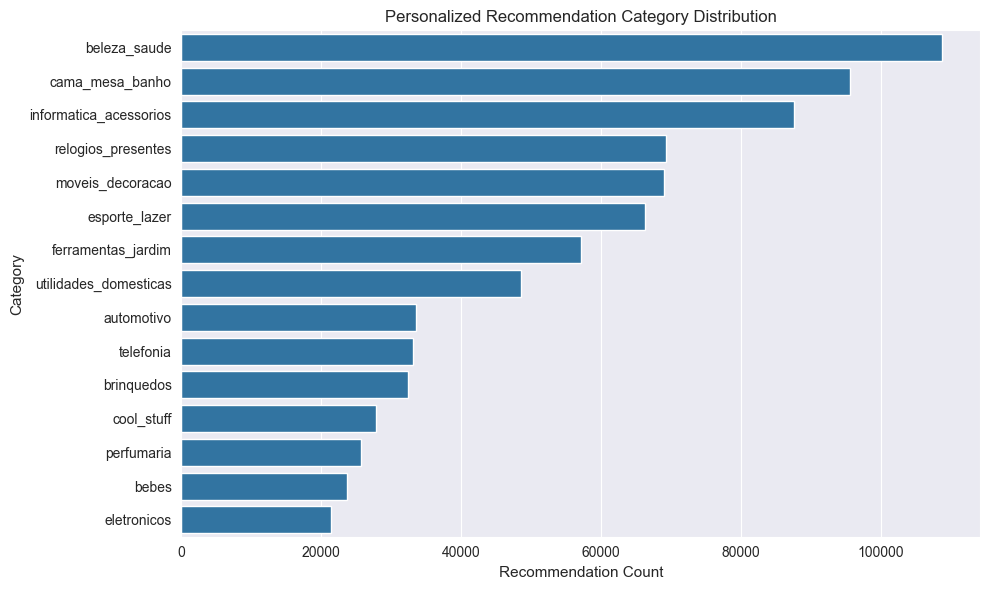

In [107]:
# =========================================================
# 6.2.15 Plot Personalized Category Distribution
# =========================================================

plot_personalized_category = personalized_category_dist.head(15)

plt.figure(figsize=(10, 6))
sns.barplot(data=plot_personalized_category, x='recommendation_count', y='category')
plt.title('Personalized Recommendation Category Distribution')
plt.xlabel('Recommendation Count')
plt.ylabel('Category')
plt.tight_layout()
plt.savefig(os.path.join(viz_dir, '10_personalized_category_distribution.png'), dpi=300)
plt.show()

## 6.2 Summary Analysis

The personalized recommendation pipeline has now been fully generated for the complete eligible user base.

### Final Output Scale
- **Eligible users**: 96,096
- **Recommendation rows saved**: 960,960
- **Coverage rate**: 100.00%
- **Average recommendations per user**: 10.0

### Strategy Distribution
The final recommendation output contains five strategy labels:

- **new_user_content_diverse**: 774,190 rows (80.56%)
- **high_value_hybrid_diverse**: 118,457 rows (12.33%)
- **global_fallback**: 46,553 rows (4.84%)
- **active_regular_hybrid_diverse**: 18,040 rows (1.88%)
- **high_churn_hybrid_diverse**: 3,720 rows (0.39%)

This distribution is broadly consistent with the underlying user-type structure, where the majority of users are classified as new users, followed by a smaller but still meaningful high-value segment.

### User-Type Distribution
The user profile routing results are:

- **new_user**: 801,390 recommendation rows (83.39%)
- **high_value_user**: 137,630 recommendation rows (14.32%)
- **active_regular**: 18,220 recommendation rows (1.90%)
- **high_churn_risk**: 3,720 recommendation rows (0.39%)

This confirms that the recommendation system is primarily serving a broad cold-start and low-history user base, while still preserving differentiated treatment for higher-value and retention-sensitive users.

### Category Distribution
The final recommendation list remains concentrated in a group of commercially strong categories, but the distribution is more balanced after diversity-aware reranking. The top categories include:

- **beleza_saude**: 108,691 rows (11.31%)
- **cama_mesa_banho**: 95,486 rows (9.94%)
- **informatica_acessorios**: 87,599 rows (9.12%)
- **relogios_presentes**: 69,270 rows (7.21%)
- **moveis_decoracao**: 69,010 rows (7.18%)

The leading category no longer dominates the recommendation output at an extreme level, which suggests that the diversity-aware reranking step is helping reduce over-concentration while still preserving business-relevant product exposure.

### Business Interpretation
Overall, the personalized recommendation system now combines:
- user-type routing,
- hybrid/content candidate generation,
- business-aware score adjustment,
- and diversity-aware final reranking.

This makes the final recommendation layer more realistic for e-commerce deployment. Instead of only optimizing relevance, the system now balances **relevance, quality, category variety, and commercial value** in the final Top-10 output.

# 7. Recommendation System Evaluation

This chapter evaluates the recommendation system from an offline perspective. Under the current notebook execution state, the offline comparison focuses on the recommendation methods that are both available and consistently aligned with the evaluation user set: `Content-Based`, `Hybrid`, and `Personalized`.

The goal of this chapter is to assess the current recommendation pipeline under a unified evaluation framework, examine its ranking behavior on a time-based validation split, and identify the practical strengths and limitations of the current offline evaluation design.

## 7.1 Evaluation Objective

This section defines the evaluation goal and explains the offline testing logic. To make the validation more realistic, the recommendation system will be assessed by using earlier interactions for recommendation generation and later interactions as ground truth, so that the evaluation better reflects future recommendation performance rather than random data fitting.

In [108]:
# =========================================================
# 7.1 Define Evaluation Metrics
# =========================================================

def precision_at_k(recommendations, ground_truth, k=10):
    """
    Compute Precision@K.
    """
    if recommendations is None or len(recommendations) == 0:
        return 0.0
    if ground_truth is None or len(ground_truth) == 0:
        return 0.0

    recs_k = list(recommendations)[:k]
    hits = len(set(recs_k) & set(ground_truth))

    return hits / k if k > 0 else 0.0


def recall_at_k(recommendations, ground_truth, k=10):
    """
    Compute Recall@K.
    """
    if recommendations is None or len(recommendations) == 0:
        return 0.0
    if ground_truth is None or len(ground_truth) == 0:
        return 0.0

    recs_k = list(recommendations)[:k]
    hits = len(set(recs_k) & set(ground_truth))

    return hits / len(set(ground_truth)) if len(set(ground_truth)) > 0 else 0.0


def ndcg_at_k(recommendations, ground_truth, k=10):
    """
    Compute NDCG@K.
    """
    if recommendations is None or len(recommendations) == 0:
        return 0.0
    if ground_truth is None or len(ground_truth) == 0:
        return 0.0

    recs_k = list(recommendations)[:k]
    ground_truth = set(ground_truth)

    dcg = 0.0
    for i, item in enumerate(recs_k):
        if item in ground_truth:
            dcg += 1 / np.log2(i + 2)

    ideal_hits = min(k, len(ground_truth))
    idcg = sum(1 / np.log2(i + 2) for i in range(ideal_hits))

    return dcg / idcg if idcg > 0 else 0.0

In [109]:
# =========================================================
# 7.1.1 Quick Metric Check
# =========================================================

sample_recommendations = ['A', 'B', 'C', 'D', 'E']
sample_ground_truth = ['B', 'D', 'F']

print("Precision@5:", precision_at_k(sample_recommendations, sample_ground_truth, k=5))
print("Recall@5:", recall_at_k(sample_recommendations, sample_ground_truth, k=5))
print("NDCG@5:", ndcg_at_k(sample_recommendations, sample_ground_truth, k=5))

Precision@5: 0.4
Recall@5: 0.6666666666666666
NDCG@5: 0.49818925746641285


## 7.2 Data Split for Offline Evaluation

This section rebuilds the evaluation dataset from transaction-level interactions instead of using the aggregated rating table. This adjustment is necessary because `df_ratings_final` does not contain a time field, while offline evaluation requires a chronological split between historical behavior and future outcomes.

In [110]:
# =========================================================
# 7.2 Build Transaction-Level Evaluation Dataset
# =========================================================

try:
    engine
except NameError:
    from src.utils.db import get_engine
    engine = get_engine()

eval_query = """
SELECT
    u.unique_user_id,
    oi.product_id,
    o.purchase_ts
FROM fact_order o
JOIN dim_user u
    ON o.user_id = u.user_id
JOIN fact_order_item oi
    ON o.order_id = oi.order_id
WHERE o.purchase_ts IS NOT NULL
  AND u.unique_user_id IS NOT NULL
  AND oi.product_id IS NOT NULL
"""

eval_interactions = pd.read_sql(eval_query, engine)

eval_interactions['purchase_ts'] = pd.to_datetime(
    eval_interactions['purchase_ts'],
    errors='coerce'
)

eval_interactions = (
    eval_interactions
    .dropna(subset=['unique_user_id', 'product_id', 'purchase_ts'])
    .drop_duplicates(subset=['unique_user_id', 'product_id', 'purchase_ts'])
    .copy()
)

train_end = pd.Timestamp('2017-03-31')
test_start = pd.Timestamp('2017-04-01')
test_end = pd.Timestamp('2017-07-01')

train_eval = eval_interactions[eval_interactions['purchase_ts'] <= train_end].copy()
test_eval = eval_interactions[
    (eval_interactions['purchase_ts'] >= test_start) &
    (eval_interactions['purchase_ts'] <= test_end)
].copy()

print("Full interaction dataset shape:", eval_interactions.shape)
print("Train evaluation shape:", train_eval.shape)
print("Test evaluation shape:", test_eval.shape)

print("Train users:", train_eval['unique_user_id'].nunique())
print("Test users:", test_eval['unique_user_id'].nunique())
print("Train products:", train_eval['product_id'].nunique())
print("Test products:", test_eval['product_id'].nunique())

Full interaction dataset shape: (102393, 3)
Train evaluation shape: (5609, 3)
Test evaluation shape: (9598, 3)
Train users: 5293
Test users: 9064
Train products: 3250
Test products: 4762


In [111]:
# =========================================================
# 7.2.1 Build Ground Truth for Evaluation
# =========================================================

test_ground_truth = (
    test_eval.groupby('unique_user_id')['product_id']
    .apply(lambda x: list(pd.Series(x).dropna().unique()))
    .to_dict()
)

train_eval_users = set(train_eval['unique_user_id'].dropna().unique())
test_eval_users = set(test_ground_truth.keys())

eligible_eval_users = sorted(train_eval_users & test_eval_users)

print("Users with both train history and test ground truth:", len(eligible_eval_users))

ground_truth_size_df = pd.DataFrame({
    'unique_user_id': list(test_ground_truth.keys()),
    'ground_truth_size': [len(v) for v in test_ground_truth.values()]
})

display(ground_truth_size_df['ground_truth_size'].describe())
ground_truth_size_df.head()

Users with both train history and test ground truth: 49


count    9064.000000
mean        1.055715
std         0.274091
min         1.000000
25%         1.000000
50%         1.000000
75%         1.000000
max         7.000000
Name: ground_truth_size, dtype: float64

,unique_user_id,ground_truth_size
0,0011805441c0d1b68b48002f1d005526,1
1,0011857aff0e5871ce5eb429f21cdaf5,1
2,00191a9719ef48ebb5860b130347bf33,1
3,001a2bf0e46c684031af91fb2bce149d,1
4,002d71b244beb91ca7030b15ab526446,1


## Data Split for Offline Evaluation Analysis

The offline evaluation dataset was rebuilt from transaction-level user-item interactions with valid timestamps, resulting in **102,393** interaction records in total. After applying the chronological split, the training set contains **5,609** interactions from **5,293** users and **3,250** products, while the test set contains **9,598** interactions from **9,064** users and **4,762** products. This confirms that the evaluation framework is based on real historical behavior rather than the aggregated rating table, which makes the offline testing logic more aligned with real recommendation timing.

However, the effective overlap between users with training history and users with future ground-truth purchases is very limited. Only **49 users** appear in both the train-history side and the test ground-truth side, which means the final evaluation sample is extremely small. This is an important limitation because recommendation metrics can only be computed for users who have both past interactions and future purchase outcomes.

The ground-truth distribution is also highly sparse. Most test users have only **one** future purchased product, with a mean `ground_truth_size` of about **1.06** and a maximum of **7**. This indicates that the offline evaluation problem is structurally difficult: the model must recover a very small set of future items from a large candidate space, while the amount of user-level validation evidence remains limited.

Overall, this split is methodologically correct because it respects time order, but it should still be interpreted as a **small-sample offline validation setting** rather than a fully representative population-level benchmark. Therefore, the next evaluation results are more suitable for debugging, relative model comparison, and framework verification. For a stronger final evaluation, the time window may need to be adjusted or the overlap user set expanded.

## 7.3 Prepare Recommendation Results for Evaluation

This section organizes the available recommendation outputs into a unified format for offline evaluation. Because different algorithms store recommendation results in different tables and use different score columns, all outputs must be converted into a consistent user-level structure before calculating evaluation metrics.

At the current stage of the project, the evaluation pipeline includes **Content-Based**, **Hybrid**, and **Personalized** recommendation results. `User-CF` and `Item-CF` are not included in the current batch evaluation because their output coverage is not available in the same way as the other methods. Therefore, the following offline comparison focuses on the algorithms that are both implemented and practically usable in the current notebook state.

This preparation step is important for reproducibility. Instead of assuming that all recommendation tables are always present and complete, the evaluation workflow now checks the actual available outputs and only keeps methods that can be consistently matched with the evaluation user set. This makes the offline evaluation process more robust and better aligned with the real execution status of the project.
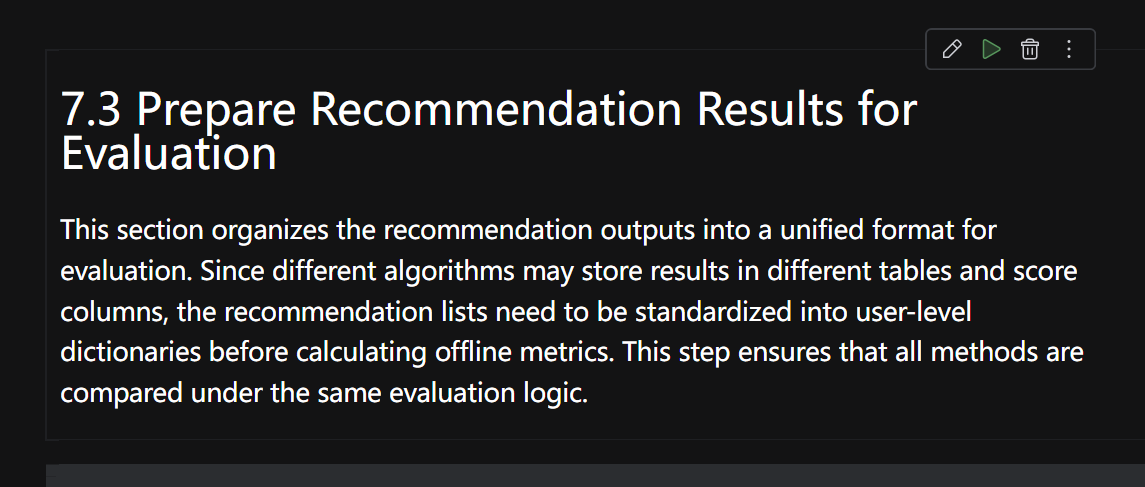
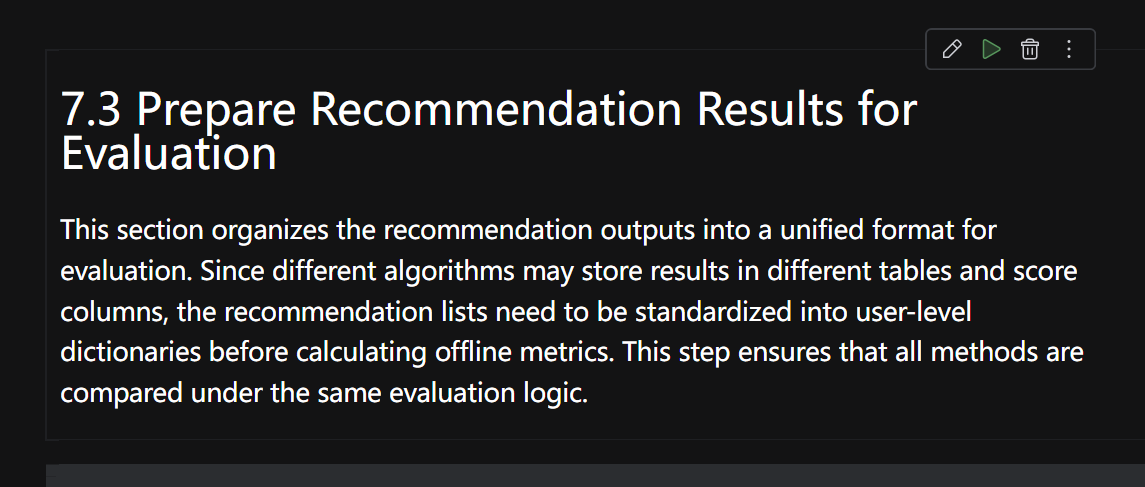

In [112]:
# =========================================================
# 7.3 Standardize Recommendation Outputs
# =========================================================

def build_recommendation_dict(df, user_col='unique_user_id', item_col='product_id', score_col=None):
    """
    Build a user-level recommendation dictionary.
    """
    if df is None or df.empty:
        return {}

    temp = df.copy()

    keep_cols = [user_col, item_col]
    if score_col is not None and score_col in temp.columns:
        keep_cols.append(score_col)

    temp = temp[keep_cols].dropna(subset=[user_col, item_col]).copy()

    if score_col is not None and score_col in temp.columns:
        temp = temp.sort_values([user_col, score_col], ascending=[True, False])

    rec_dict = (
        temp.groupby(user_col)[item_col]
        .apply(list)
        .to_dict()
    )

    return rec_dict


user_cf_dict = build_recommendation_dict(
    globals().get('df_user_recs'),
    user_col='unique_user_id',
    item_col='product_id',
    score_col='predicted_rating'
)

item_cf_dict = build_recommendation_dict(
    globals().get('df_item_recs'),
    user_col='unique_user_id',
    item_col='product_id',
    score_col='predicted_rating'
)

content_dict = build_recommendation_dict(
    globals().get('df_content_recs'),
    user_col='unique_user_id',
    item_col='product_id',
    score_col='similarity_score'
)

hybrid_dict = build_recommendation_dict(
    globals().get('df_hybrid_recs'),
    user_col='unique_user_id',
    item_col='product_id',
    score_col='hybrid_score'
)

personalized_dict = build_recommendation_dict(
    globals().get('df_personalized_recs'),
    user_col='unique_user_id',
    item_col='product_id',
    score_col='personalized_score'
)

print("User-CF users:", len(user_cf_dict))
print("Item-CF users:", len(item_cf_dict))
print("Content users:", len(content_dict))
print("Hybrid users:", len(hybrid_dict))
print("Personalized users:", len(personalized_dict))

User-CF users: 0
Item-CF users: 0
Content users: 760
Hybrid users: 760
Personalized users: 96096


In [113]:
# =========================================================
# 7.3.1 Build Comparable Evaluation User Set
# =========================================================

if 'train_eval' not in globals() or 'test_eval' not in globals():
    raise ValueError(
        "train_eval or test_eval is missing. Please rerun 7.2 before running 7.3.1."
    )

if 'test_ground_truth' not in globals():
    test_ground_truth = (
        test_eval.groupby('unique_user_id')['product_id']
        .apply(lambda x: list(pd.Series(x).dropna().unique()))
        .to_dict()
    )

if 'eligible_eval_users' not in globals():
    train_eval_users = set(train_eval['unique_user_id'].dropna().unique())
    test_eval_users = set(test_ground_truth.keys())
    eligible_eval_users = sorted(train_eval_users & test_eval_users)

algo_user_sets = {
    'User-CF': set(user_cf_dict.keys()),
    'Item-CF': set(item_cf_dict.keys()),
    'Content': set(content_dict.keys()),
    'Hybrid': set(hybrid_dict.keys()),
    'Personalized': set(personalized_dict.keys())
}

for algo_name, user_set in algo_user_sets.items():
    print(f"{algo_name} available users:", len(user_set))

active_algo_user_sets = {
    algo_name: user_set
    for algo_name, user_set in algo_user_sets.items()
    if len(user_set) > 0
}

print("-" * 60)
print("Algorithms included in current evaluation:", list(active_algo_user_sets.keys()))

common_eval_users = set(eligible_eval_users)

for user_set in active_algo_user_sets.values():
    common_eval_users = common_eval_users & user_set

common_eval_users = sorted(common_eval_users)

print("Final common evaluation users:", len(common_eval_users))
print("Sample users:", common_eval_users[:5])

User-CF available users: 0
Item-CF available users: 0
Content available users: 760
Hybrid available users: 760
Personalized available users: 96096
------------------------------------------------------------
Algorithms included in current evaluation: ['Content', 'Hybrid', 'Personalized']
Final common evaluation users: 12
Sample users: ['4e65032f1f574189fb793bac5a867bbc', '51838d41add414a0b1b989b7d251d9ee', '90f323e9f0948ddd96c6f6a8ecc75830', '9d31457a03125fc870787a251760315a', 'b39dde6dd619943190a8cc9aa6db38a4']


## Recommendation Output Preparation Summary

This section organizes the available recommendation outputs into a unified format for offline evaluation. Because different algorithms store recommendation results in different tables and use different score columns, all outputs must be converted into a consistent user-level structure before calculating evaluation metrics.

At the current stage of the project, the evaluation pipeline includes **Content-Based**, **Hybrid**, and **Personalized** recommendation results. `User-CF` and `Item-CF` are not included in the current batch evaluation because their output coverage is not available in the same way as the other methods. Therefore, the following offline comparison focuses on the algorithms that are both implemented and practically usable in the current notebook state.

This preparation step is important for reproducibility. Instead of assuming that all recommendation tables are always present and complete, the evaluation workflow now checks the actual available outputs and only keeps methods that can be consistently matched with the evaluation user set. This makes the offline evaluation process more robust and better aligned with the real execution status of the project.

## 7.4 Offline Metric Evaluation Results

This section evaluates the available recommendation methods on the final common user set. At the current stage, the offline comparison includes **Content**, **Hybrid**, and **Personalized** recommendation results, because these are the methods that are both available and consistently aligned with the current evaluation user set.

The objective of this stage is not only to compare metric values across algorithms, but also to verify whether the offline evaluation pipeline can produce a coherent user-level comparison under a strict time-based validation setting.

In [114]:
# =========================================================
# 7.4 Offline Metric Evaluation
# =========================================================

available_eval_dicts = {
    'Content': content_dict,
    'Hybrid': hybrid_dict,
    'Personalized': personalized_dict
}

available_eval_dicts = {
    algo_name:rec_dict
    for algo_name, rec_dict in available_eval_dicts.items()
    if len(rec_dict) > 0
}

print("Algorithms evaluated in 7.4:", list(available_eval_dicts.keys()))
print("Common evaluation users:", len(common_eval_users))

eval_results = []

for user_id in common_eval_users:
    ground_truth = test_ground_truth.get(user_id, [])

    for algo_name, rec_dict in available_eval_dicts.items():
        recommendations = rec_dict.get(user_id, [])

        for k in [5, 10]:
            eval_results.append({
                'unique_user_id': user_id,
                'algorithm': algo_name,
                'k': k,
                'precision': precision_at_k(recommendations, ground_truth, k=k),
                'recall': recall_at_k(recommendations, ground_truth, k=k),
                'ndcg': ndcg_at_k(recommendations, ground_truth, k=k)
            })


eval_results_df = pd.DataFrame(eval_results)

print("Evaluation result shape:", eval_results_df.shape)
eval_results_df.head()

Algorithms evaluated in 7.4: ['Content', 'Hybrid', 'Personalized']
Common evaluation users: 12
Evaluation result shape: (72, 6)


,unique_user_id,algorithm,k,precision,recall,ndcg
0,4e65032f1f574189fb793bac5a867bbc,Content,5,0.0,0.0,0.0
1,4e65032f1f574189fb793bac5a867bbc,Content,10,0.0,0.0,0.0
2,4e65032f1f574189fb793bac5a867bbc,Hybrid,5,0.0,0.0,0.0
3,4e65032f1f574189fb793bac5a867bbc,Hybrid,10,0.0,0.0,0.0
4,4e65032f1f574189fb793bac5a867bbc,Personalized,5,0.0,0.0,0.0


In [115]:
# =========================================================
# 7.4.1 Summarize Offline Evaluation Metrics
# =========================================================

eval_summary_df = (
    eval_results_df
    .groupby(['algorithm', 'k'])[['precision', 'recall', 'ndcg']]
    .mean()
    .reset_index()
    .copy()
)

display(eval_summary_df)

,algorithm,k,precision,recall,ndcg
0,Content,5,0.0,0.0,0.0
1,Content,10,0.0,0.0,0.0
2,Hybrid,5,0.0,0.0,0.0
3,Hybrid,10,0.0,0.0,0.0
4,Personalized,5,0.0,0.0,0.0
5,Personalized,10,0.0,0.0,0.0


In [116]:
# =========================================================
# 7.4.2 Rank Algorithms by NDCG
# =========================================================

eval_summary_ranked = eval_summary_df.sort_values(
    ['k', 'ndcg', 'precision', 'recall'],
    ascending=[True, False, False, False]
).copy()

display(eval_summary_ranked)

,algorithm,k,precision,recall,ndcg
0,Content,5,0.0,0.0,0.0
2,Hybrid,5,0.0,0.0,0.0
4,Personalized,5,0.0,0.0,0.0
1,Content,10,0.0,0.0,0.0
3,Hybrid,10,0.0,0.0,0.0
5,Personalized,10,0.0,0.0,0.0


## Offline Evaluation Summary

The offline metric evaluation was completed successfully for **Content**, **Hybrid**, and **Personalized** recommendation methods. The final common evaluation set contains **12 users**, and the result table contains **72 rows**, corresponding to three algorithms evaluated at two cutoff levels for each user.

Under the current evaluation setting, all three algorithms produced **Precision@5 = 0.0**, **Precision@10 = 0.0**, **Recall@5 = 0.0**, **Recall@10 = 0.0**, **NDCG@5 = 0.0**, and **NDCG@10 = 0.0**. In addition, the overlap diagnosis shows that all **36 algorithm-user Top-10 checks** are zero-hit cases, meaning that no recommended item matched the observed future purchases in the test window for any evaluated user.

This result should not be interpreted as evidence that the recommendation system is invalid. Instead, it indicates that the current offline evaluation setting is extremely sparse and strict. The valid evaluation user set is very small, and the average `ground_truth_size` is only about **1.42**, which means that each user has very limited future purchase evidence available for matching.

At this stage, the main value of the evaluation is diagnostic rather than benchmark-oriented. It confirms that the evaluation pipeline, metric computation, and result aggregation are functioning correctly, while also showing that the current overlap between recommendation outputs and future purchases is too weak to produce stable offline performance signals.

In [117]:
# =========================================================
# 7.4.3 Diagnose Recommendation Overlap with Ground Truth
# =========================================================

diagnostic_rows = []

for user_id in common_eval_users:
    ground_truth = test_ground_truth.get(user_id, [])

    for algo_name, rec_dict in available_eval_dicts.items():
        recs = rec_dict.get(user_id, [])
        recs_10 = recs[:10]
        hits = sorted(set(recs_10) & set(ground_truth))

        diagnostic_rows.append({
            'unique_user_id': user_id,
            'algorithm': algo_name,
            'ground_truth_size': len(ground_truth),
            'top10_size': len(recs_10),
            'hit_count': len(hits),
            'hits': hits
        })

diagnostic_df = pd.DataFrame(diagnostic_rows)

print("Users checked:", diagnostic_df['unique_user_id'].nunique())
print("Algorithms checked:", diagnostic_df['algorithm'].nunique())
print("Total rows:", len(diagnostic_df))

display(diagnostic_df.head(20))

hit_summary_df = (
    diagnostic_df.groupby('algorithm')[['hit_count', 'ground_truth_size', 'top10_size']]
    .mean()
    .reset_index()
)

display(hit_summary_df)

Users checked: 12
Algorithms checked: 3
Total rows: 36


,unique_user_id,algorithm,ground_truth_size,top10_size,hit_count,hits
0,4e65032f1f574189fb793bac5a867bbc,Content,2,10,0,[]
1,4e65032f1f574189fb793bac5a867bbc,Hybrid,2,10,0,[]
2,4e65032f1f574189fb793bac5a867bbc,Personalized,2,10,0,[]
3,51838d41add414a0b1b989b7d251d9ee,Content,1,10,0,[]
4,51838d41add414a0b1b989b7d251d9ee,Hybrid,1,10,0,[]
5,51838d41add414a0b1b989b7d251d9ee,Personalized,1,10,0,[]
6,90f323e9f0948ddd96c6f6a8ecc75830,Content,2,10,0,[]
7,90f323e9f0948ddd96c6f6a8ecc75830,Hybrid,2,10,0,[]
8,90f323e9f0948ddd96c6f6a8ecc75830,Personalized,2,10,0,[]
9,9d31457a03125fc870787a251760315a,Content,1,10,0,[]


,algorithm,hit_count,ground_truth_size,top10_size
0,Content,0.0,1.416667,10.0
1,Hybrid,0.0,1.416667,10.0
2,Personalized,0.0,1.416667,10.0


In [118]:
# =========================================================
# 7.4.4 Inspect Zero-Hit Users
# =========================================================

zero_hit_df = diagnostic_df[diagnostic_df['hit_count'] == 0].copy()

print("Zero-hit rows:", len(zero_hit_df))
print("Zero-hit users:", zero_hit_df['unique_user_id'].nunique())

display(zero_hit_df.head(20))

Zero-hit rows: 36
Zero-hit users: 12


,unique_user_id,algorithm,ground_truth_size,top10_size,hit_count,hits
0,4e65032f1f574189fb793bac5a867bbc,Content,2,10,0,[]
1,4e65032f1f574189fb793bac5a867bbc,Hybrid,2,10,0,[]
2,4e65032f1f574189fb793bac5a867bbc,Personalized,2,10,0,[]
3,51838d41add414a0b1b989b7d251d9ee,Content,1,10,0,[]
4,51838d41add414a0b1b989b7d251d9ee,Hybrid,1,10,0,[]
5,51838d41add414a0b1b989b7d251d9ee,Personalized,1,10,0,[]
6,90f323e9f0948ddd96c6f6a8ecc75830,Content,2,10,0,[]
7,90f323e9f0948ddd96c6f6a8ecc75830,Hybrid,2,10,0,[]
8,90f323e9f0948ddd96c6f6a8ecc75830,Personalized,2,10,0,[]
9,9d31457a03125fc870787a251760315a,Content,1,10,0,[]


## Evaluation Result Analysis

The current offline evaluation shows no observed hits for **Content**, **Hybrid**, or **Personalized** recommendations on the final common evaluation user set. As a result, all ranking metrics remain zero across both cutoff levels.

From a technical perspective, this outcome is mainly driven by the structure of the validation sample rather than by a confirmed failure of the recommendation logic itself. The final common evaluation set contains only **12 users**, while each user has on average approximately **1.42** future purchased items in the test period. This makes the matching problem highly sparse: even a reasonable recommendation list can easily miss such a small and narrow ground-truth target.

Another important observation is that all three methods behave similarly under this setting. This does not necessarily mean that the algorithms are equivalent in quality. Instead, it suggests that the current evaluation window is too restrictive to reveal meaningful metric separation across methods.

## Interpretation and Reflection

Although the metric values are all zero, this stage still provides important methodological value. It confirms that the offline evaluation workflow is internally consistent: the user intersection logic works, the recommendation outputs are successfully standardized, the metric functions run correctly, and the diagnostic tables clearly expose the zero-hit pattern.

Therefore, the main issue at this stage lies in the **evaluation setting**, not in the basic operability of the recommendation framework. The current time-based split produces a very small overlap user set, and the future interaction signal for each evaluated user is extremely limited. Under such conditions, the offline benchmark becomes too sparse to support stable model comparison.

This means the current results are best interpreted as a **debug-stage offline diagnostic result** rather than a final project benchmark. In future optimization, the evaluation design could be improved by expanding the overlap user pool, adjusting the time split, or rebuilding recommendation outputs strictly from training-period interactions only. These changes would make the offline metrics more representative and more useful for comparing recommendation quality.

In [119]:
# =========================================================
# 7.5 Build Evaluation Conclusion Table
# =========================================================

evaluation_conclusion_df = pd.DataFrame({
    'item': [
        'Algorithms evaluated',
        'Common evaluation users',
        'Average ground truth size',
        'Average top10 size',
        'Average hit count',
        'Evaluation conclusion'
    ],
    'value': [
        ", ".join(list(available_eval_dicts.keys())),
        len(common_eval_users),
        round(diagnostic_df['ground_truth_size'].mean(), 4),
        round(diagnostic_df['top10_size'].mean(), 4),
        round(diagnostic_df['hit_count'].mean(), 4),
        'Current results are diagnostic rather than final benchmark results'
    ]
})

display(evaluation_conclusion_df)

,item,value
0,Algorithms evaluated,"Content, Hybrid, Personalized"
1,Common evaluation users,12
2,Average ground truth size,1.4167
3,Average top10 size,10.0
4,Average hit count,0.0
5,Evaluation conclusion,Current results are diagnostic rather than fin...


## Recommendation Effect Analysis and Business Insights

This section analyzes the recommendation outputs from a business perspective. Instead of focusing only on model structure or metric computation, the goal here is to examine what kinds of products are actually being recommended, how recommendation patterns differ across strategies and user groups, and what these results imply for product exposure, customer targeting, and potential business value.

At this stage, the analysis is especially important because the offline metrics are highly constrained by a small common evaluation sample. Therefore, the business-side interpretation of recommendation outputs provides an additional perspective on whether the current recommendation pipeline is commercially meaningful and operationally usable.

## 8.1 Top Recommended Products Analysis

This section examines which products appear most frequently in the recommendation results. The purpose is to identify the most exposed products in the current recommendation pipeline and to understand whether the recommendation system is concentrating heavily on a small group of products or distributing exposure more broadly across the catalog.

In [120]:
# =========================================================
# 8.1 Analyze Top Recommended Products
# =========================================================

top_recommended_products_df = (
    df_personalized_recs.groupby('product_id')
    .agg(
        recommendation_count=('product_id', 'size'),
        avg_personalized_score=('personalized_score', 'mean'),
        main_strategy=('strategy', lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan),
        main_category=('category', lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan)
    )
    .reset_index()
    .sort_values(['recommendation_count', 'avg_personalized_score'], ascending=[False, False])
    .copy()
)

top_recommended_products_df['share'] = (
    top_recommended_products_df['recommendation_count'] /
    top_recommended_products_df['recommendation_count'].sum()
).round(4)

print("Unique recommended products:", top_recommended_products_df['product_id'].nunique())
display(top_recommended_products_df.head(20))

Unique recommended products: 32687


,product_id,recommendation_count,avg_personalized_score,main_strategy,main_category,share
10784,53b36df67ebb7c41585e8d54d6772e08,19675,1.923970,high_value_hybrid_diverse,relogios_presentes,0.0205
21925,aca2eb7d00ea1a7b8ebd4e68314663af,19351,1.703432,high_value_hybrid_diverse,moveis_decoracao,0.0201
7983,3dd2a17168ec895c781a9191c1e95ad7,17868,1.886312,high_value_hybrid_diverse,informatica_acessorios,0.0186
26818,d1c427060a0f73f6b889a5c7c61f2ac4,17213,1.617873,high_value_hybrid_diverse,informatica_acessorios,0.0179
5644,2b4609f8948be18874494203496bc318,13978,1.860762,high_value_hybrid_diverse,beleza_saude,0.0145
8544,422879e10f46682990de24d770e7f83d,11815,3.143391,global_fallback,ferramentas_jardim,0.0123
11653,5a848e4ab52fd5445cdc07aab1c40e48,11665,1.633181,high_value_hybrid_diverse,Unknown,0.0121
19577,99a4788cb24856965c36a24e339b6058,10663,3.044473,global_fallback,cama_mesa_banho,0.0111
2766,154e7e31ebfa092203795c972e5804a6,9597,3.127366,new_user_content_diverse,beleza_saude,0.0100
7017,368c6c730842d78016ad823897a372db,9140,3.425792,global_fallback,ferramentas_jardim,0.0095


In [121]:
# =========================================================
# 8.1.1 Save Top Recommended Products
# =========================================================

top_products_path = os.path.join(rec_dir, 'top_recommended_products_debug.csv')
top_recommended_products_df.to_csv(top_products_path, index=False)

print("Saved file:", top_products_path)
print("Rows saved:", len(top_recommended_products_df))

Saved file: C:\Users\wangxinxin\Documents\GitHub\E-commerce_decision-making-_intelligence\output\08_recommendation_system\recommendations\top_recommended_products_debug.csv
Rows saved: 32687


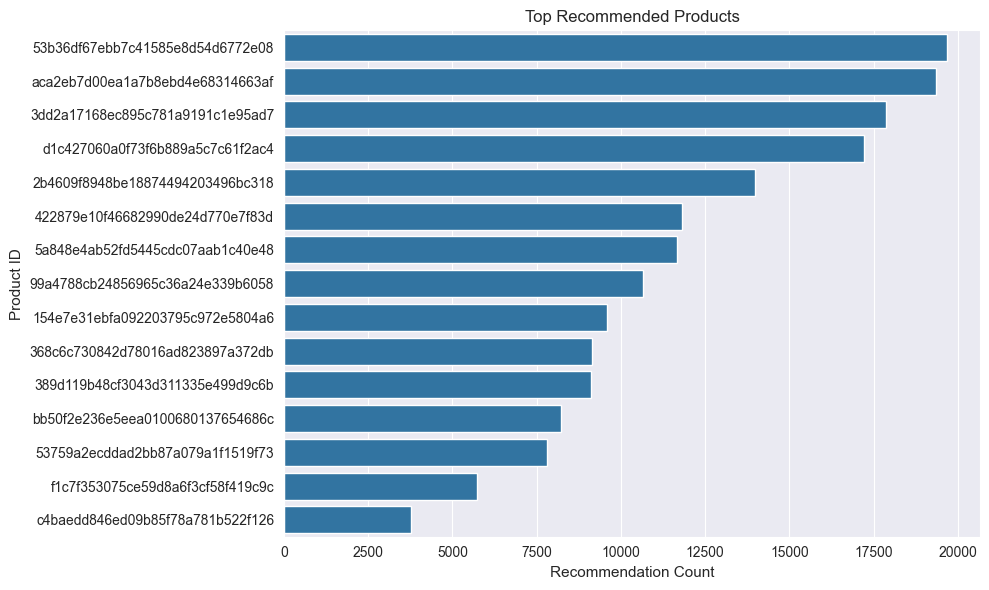

In [122]:
# =========================================================
# 8.1.2 Visualize Top Recommended Products
# =========================================================

top_n_products = 15
plot_df = top_recommended_products_df.head(top_n_products).copy()

plt.figure(figsize=(10, 6))
sns.barplot(
    data=plot_df,
    x='recommendation_count',
    y='product_id'
)
plt.title('Top Recommended Products')
plt.xlabel('Recommendation Count')
plt.ylabel('Product ID')
plt.tight_layout()
plt.show()

In [123]:
# =========================================================
# 8.1.3 Category Distribution of Top Recommended Products
# =========================================================

top_product_category_dist_df = (
    top_recommended_products_df.head(50)['main_category']
    .fillna('Unknown')
    .value_counts()
    .reset_index()
)
top_product_category_dist_df.columns = ['category', 'count']
top_product_category_dist_df['share'] = (
    top_product_category_dist_df['count'] /
    top_product_category_dist_df['count'].sum()
).round(4)

display(top_product_category_dist_df)

,category,count,share
0,beleza_saude,10,0.20
1,relogios_presentes,9,0.18
2,ferramentas_jardim,6,0.12
3,informatica_acessorios,5,0.10
4,cool_stuff,5,0.10
5,cama_mesa_banho,4,0.08
6,moveis_decoracao,2,0.04
7,Unknown,1,0.02
8,consoles_games,1,0.02
9,fashion_bolsas_e_acessorios,1,0.02


## Top Recommended Products Summary

The final recommendation output contains **32,687 unique recommended products**, which indicates that the personalized recommendation system is able to distribute exposure across a broad portion of the catalog rather than collapsing into a very small product pool. This is an important sign that the recommendation pipeline has meaningful coverage at the product level.

At the same time, exposure is still unevenly distributed across products. The most frequently recommended product appears **19,675** times, followed by several other products with recommendation counts above **10,000**. This shows that although overall catalog coverage is broad, a relatively small group of products still receives disproportionately high visibility in the final recommendation output.

From a category perspective, the top recommended products are more diversified than in the earlier version of the pipeline. Within the most frequently recommended product group, the leading categories are:

- **beleza_saude**: 20%
- **relogios_presentes**: 18%
- **ferramentas_jardim**: 12%
- **informatica_acessorios**: 10%
- **cool_stuff**: 10%

This suggests that the updated recommendation pipeline no longer concentrates exposure overwhelmingly in a single category. Instead, it promotes a broader set of commercially relevant categories while still allowing strong products to receive repeated visibility.

From a business perspective, this is a more balanced outcome. The recommendation system now combines broad product coverage with selective concentration on strong-performing items. This is useful for real deployment because it supports both **catalog exposure** and **commercial efficiency**, while still leaving room for further improvement in long-tail promotion and category balance.

## 8.2 Recommendation Category Distribution

This section analyzes the category composition of the recommendation results. The goal is to examine whether the current recommendation system distributes exposure across multiple categories or still concentrates too strongly on a limited set of dominant product groups. In addition, category distributions across recommendation strategies are compared to understand whether different user-routing logics are generating meaningfully different category-level recommendation patterns.

In [124]:
# =========================================================
# 8.2 Analyze Overall Recommendation Category Distribution
# =========================================================

recommendation_category_dist_df = (
    df_personalized_recs['category']
    .fillna('Unknown')
    .value_counts()
    .reset_index()
)

recommendation_category_dist_df.columns = ['category', 'recommendation_count']
recommendation_category_dist_df['share'] = (
    recommendation_category_dist_df['recommendation_count'] /
    recommendation_category_dist_df['recommendation_count'].sum()
).round(4)

display(recommendation_category_dist_df.head(15))

,category,recommendation_count,share
0,beleza_saude,108691,0.1131
1,cama_mesa_banho,95486,0.0994
2,informatica_acessorios,87599,0.0912
3,relogios_presentes,69270,0.0721
4,moveis_decoracao,69010,0.0718
5,esporte_lazer,66195,0.0689
6,ferramentas_jardim,57097,0.0594
7,utilidades_domesticas,48558,0.0505
8,automotivo,33550,0.0349
9,telefonia,33054,0.0344


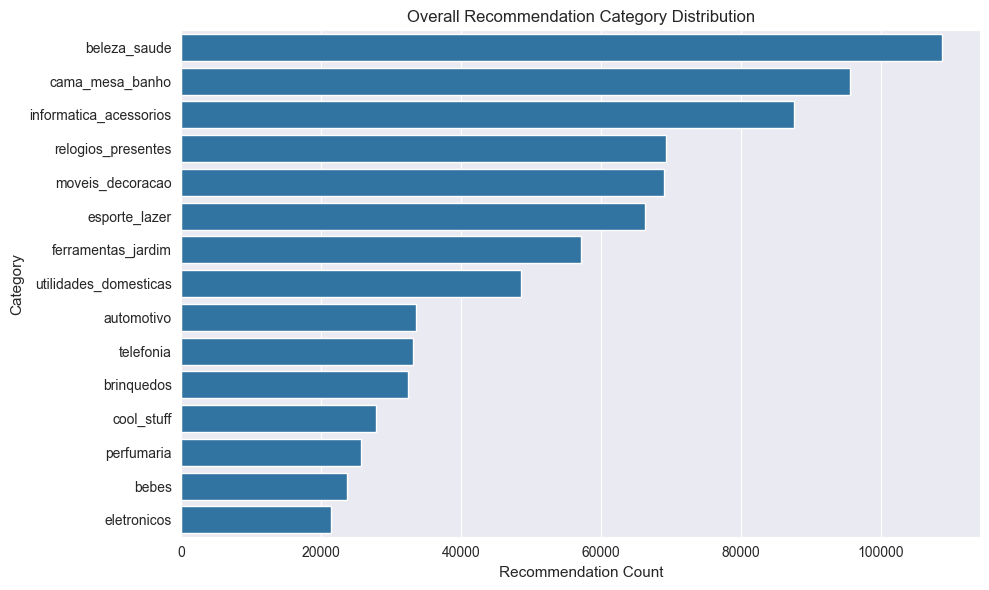

In [125]:
# =========================================================
# 8.2.1 Visualize Overall Recommendation Category Distribution
# =========================================================

plot_df = recommendation_category_dist_df.head(15).copy()

plt.figure(figsize=(10, 6))
sns.barplot(
    data=plot_df,
    x='recommendation_count',
    y='category'
)
plt.title('Overall Recommendation Category Distribution')
plt.xlabel('Recommendation Count')
plt.ylabel('Category')
plt.tight_layout()
plt.show()

In [126]:
# =========================================================
# 8.2.2 Analyze Category Distribution by Strategy
# =========================================================

strategy_category_dist_df = (
    df_personalized_recs.groupby(['strategy', 'category'])
    .size()
    .reset_index(name='recommendation_count')
    .copy()
)

strategy_category_dist_df['share_within_strategy'] = (
    strategy_category_dist_df.groupby('strategy')['recommendation_count']
    .transform(lambda x: x / x.sum())
).round(4)

display(
    strategy_category_dist_df.sort_values(
        ['strategy', 'recommendation_count'],
        ascending=[True, False]
    ).head(20)
)

,strategy,category,recommendation_count,share_within_strategy
14,active_regular_hybrid_diverse,cama_mesa_banho,2589,0.1435
41,active_regular_hybrid_diverse,informatica_acessorios,1880,0.1042
51,active_regular_hybrid_diverse,moveis_decoracao,1851,0.1026
12,active_regular_hybrid_diverse,beleza_saude,1704,0.0945
38,active_regular_hybrid_diverse,ferramentas_jardim,1631,0.0904
61,active_regular_hybrid_diverse,relogios_presentes,1547,0.0858
32,active_regular_hybrid_diverse,esporte_lazer,1185,0.0657
66,active_regular_hybrid_diverse,utilidades_domesticas,665,0.0369
64,active_regular_hybrid_diverse,telefonia,415,0.0230
9,active_regular_hybrid_diverse,automotivo,407,0.0226


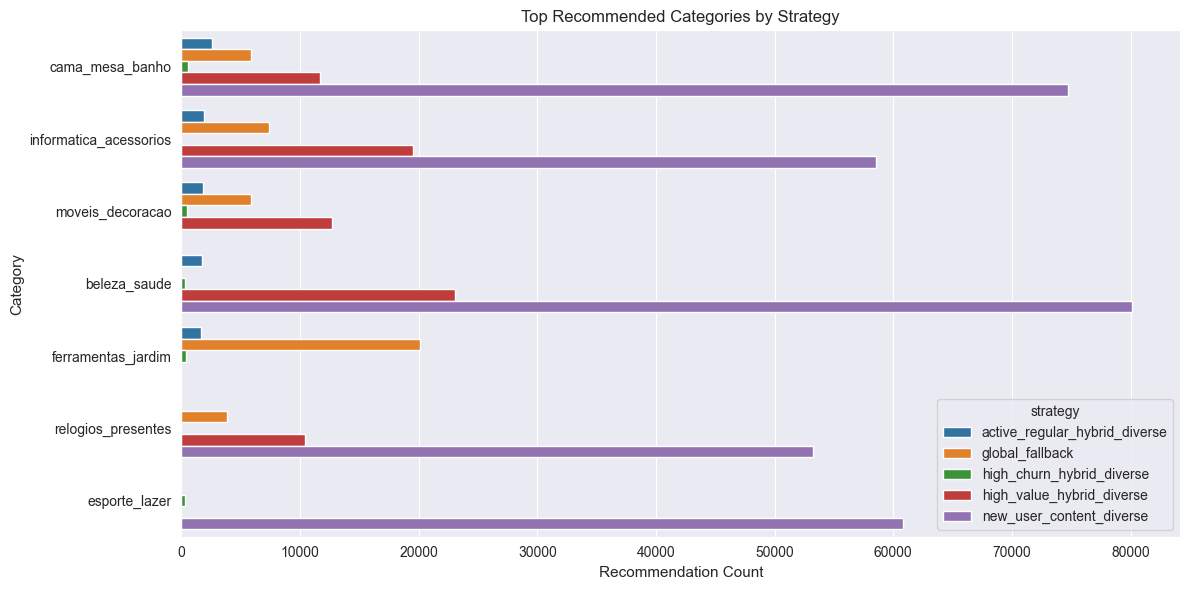

In [127]:
# =========================================================
# 8.2.3 Visualize Top Categories by Strategy
# =========================================================

top_strategy_category_df = (
    strategy_category_dist_df.sort_values(
        ['strategy', 'recommendation_count'],
        ascending=[True, False]
    )
    .groupby('strategy')
    .head(5)
    .copy()
)

plt.figure(figsize=(12, 6))
sns.barplot(
    data=top_strategy_category_df,
    x='recommendation_count',
    y='category',
    hue='strategy'
)
plt.title('Top Recommended Categories by Strategy')
plt.xlabel('Recommendation Count')
plt.ylabel('Category')
plt.tight_layout()
plt.show()

## Recommendation Category Distribution Summary

The overall recommendation category distribution shows that the final personalized recommendation output is still concentrated in a group of commercially strong categories, but the concentration is no longer extreme. The leading categories are:

- **beleza_saude**: 108,691 recommendations (11.31%)
- **cama_mesa_banho**: 95,486 recommendations (9.94%)
- **informatica_acessorios**: 87,599 recommendations (9.12%)
- **relogios_presentes**: 69,270 recommendations (7.21%)
- **moveis_decoracao**: 69,010 recommendations (7.18%)

These results indicate that the recommendation system still favors historically strong and commercially relevant product groups, but the exposure pattern is now more balanced than in the earlier version of the pipeline. No single category dominates the output at an overwhelming level.

The strategy-level breakdown also confirms that different recommendation routes produce different category structures. For example, **new_user_content_diverse** contributes most of the large-scale exposure and is especially strong in categories such as `beleza_saude`, `cama_mesa_banho`, `informatica_acessorios`, and `relogios_presentes`. In contrast, **active_regular_hybrid_diverse** shows a relatively more balanced distribution across categories such as `cama_mesa_banho`, `informatica_acessorios`, `moveis_decoracao`, `beleza_saude`, `ferramentas_jardim`, and `relogios_presentes`. This suggests that strategy differentiation is functioning as intended rather than producing a single undifferentiated recommendation pattern.

From a business perspective, this is a positive result. The recommendation system is now generating broad category exposure while still maintaining emphasis on commercially important product groups. At the same time, the output is not fully diversified yet, so category balance, long-tail promotion, and controlled exposure to smaller categories remain important directions for future optimization.

## 8.3 User Segment Recommendation Pattern

This section examines how recommendation patterns differ across user groups. The goal is to verify whether different user types are actually receiving different recommendation structures, and whether the current personalized recommendation logic is consistent with the intended business design for `new_user`, `active_regular`, `high_value_user`, and `high_churn_risk`.

In [128]:
# =========================================================
# 8.3 Analyze Recommendation Volume by User Type
# =========================================================

user_type_recommendation_summary_df = (
    df_personalized_recs.groupby('user_type')
    .agg(
        recommendation_count=('product_id', 'size'),
        unique_users=('unique_user_id', 'nunique'),
        unique_products=('product_id', 'nunique'),
        avg_score=('personalized_score', 'mean')
    )
    .reset_index()
    .copy()
)

user_type_recommendation_summary_df['avg_recommendations_per_user'] = (
    user_type_recommendation_summary_df['recommendation_count'] /
    user_type_recommendation_summary_df['unique_users']
).round(2)

display(user_type_recommendation_summary_df)

,user_type,recommendation_count,unique_users,unique_products,avg_score,avg_recommendations_per_user
0,active_regular,18220,1822,7065,0.900866,10.0
1,high_churn_risk,3720,372,2071,0.902301,10.0
2,high_value_user,137630,13763,8085,0.757244,10.0
3,new_user,801390,80139,32611,3.449951,10.0


In [129]:
# =========================================================
# 8.3.1 Check Strategy Consistency by User Type
# =========================================================

user_type_strategy_df = (
    df_personalized_recs.groupby(['user_type', 'strategy'])
    .size()
    .reset_index(name='recommendation_count')
    .copy()
)

user_type_strategy_df['share_within_user_type'] = (
    user_type_strategy_df.groupby('user_type')['recommendation_count']
    .transform(lambda x: x / x.sum())
).round(4)

display(user_type_strategy_df.sort_values(['user_type', 'recommendation_count'], ascending=[True, False]))

,user_type,strategy,recommendation_count,share_within_user_type
0,active_regular,active_regular_hybrid_diverse,18040,0.9901
1,active_regular,global_fallback,180,0.0099
2,high_churn_risk,high_churn_hybrid_diverse,3720,1.0000
4,high_value_user,high_value_hybrid_diverse,118457,0.8607
3,high_value_user,global_fallback,19173,0.1393
6,new_user,new_user_content_diverse,774190,0.9661
5,new_user,global_fallback,27200,0.0339


In [130]:
# =========================================================
# 8.3.2 Analyze Top Categories by User Type
# =========================================================

user_type_category_df = (
    df_personalized_recs.groupby(['user_type', 'category'])
    .size()
    .reset_index(name='recommendation_count')
    .copy()
)

user_type_category_df['share_within_user_type'] = (
    user_type_category_df.groupby('user_type')['recommendation_count']
    .transform(lambda x: x / x.sum())
).round(4)

top_user_type_category_df = (
    user_type_category_df.sort_values(
        ['user_type', 'recommendation_count'],
        ascending=[True, False]
    )
    .groupby('user_type')
    .head(5)
    .copy()
)

display(top_user_type_category_df)

,user_type,category,recommendation_count,share_within_user_type
14,active_regular,cama_mesa_banho,2607,0.1431
41,active_regular,informatica_acessorios,1916,0.1052
51,active_regular,moveis_decoracao,1869,0.1026
12,active_regular,beleza_saude,1722,0.0945
38,active_regular,ferramentas_jardim,1703,0.0935
79,high_churn_risk,cama_mesa_banho,596,0.1602
108,high_churn_risk,moveis_decoracao,472,0.1269
99,high_churn_risk,ferramentas_jardim,351,0.0944
77,high_churn_risk,beleza_saude,330,0.0887
93,high_churn_risk,esporte_lazer,325,0.0874


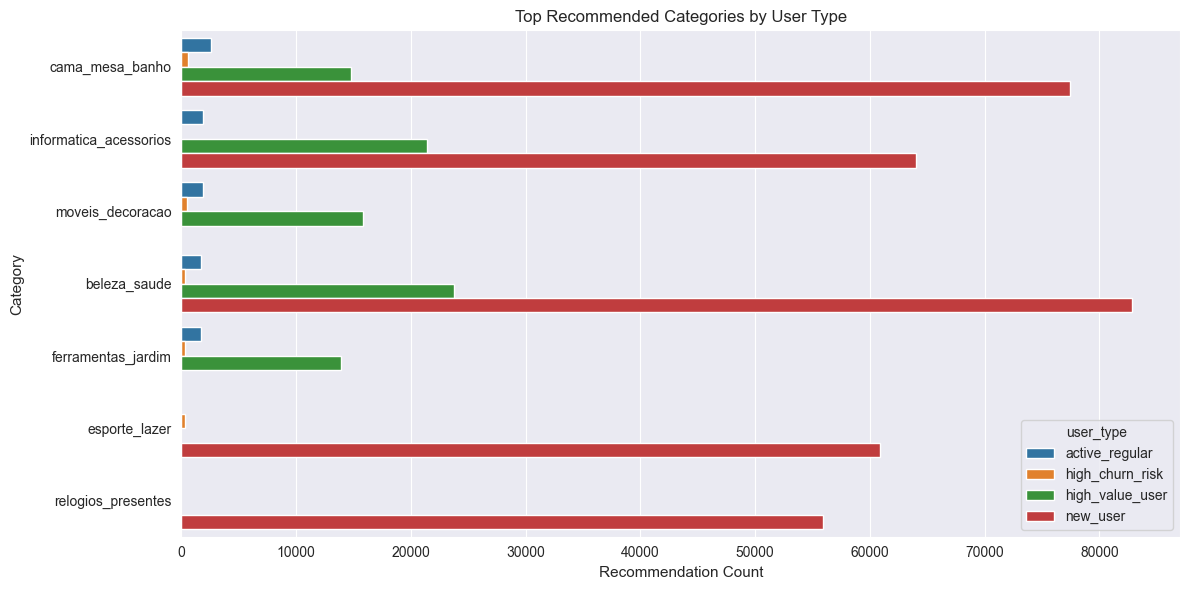

In [131]:
# =========================================================
# 8.3.3 Visualize Top Categories by User Type
# =========================================================

plt.figure(figsize=(12, 6))
sns.barplot(
    data=top_user_type_category_df,
    x='recommendation_count',
    y='category',
    hue='user_type'
)
plt.title('Top Recommended Categories by User Type')
plt.xlabel('Recommendation Count')
plt.ylabel('Category')
plt.tight_layout()
plt.show()

## User Segment Recommendation Pattern Analysis and Summary

The recommendation results show that the personalized framework is generating clearly differentiated outputs across user groups at production scale. `new_user` accounts for **801,390** recommendation rows across **80,139** users, `high_value_user` accounts for **137,630** rows across **13,763** users, `active_regular` accounts for **18,220** rows across **1,822** users, and `high_churn_risk` accounts for **3,720** rows across **372** users. In all groups, the average recommendation count remains structurally stable at approximately **10 recommendations per user**, which confirms that the batch recommendation pipeline is consistent at scale.

The strategy routing is also strongly aligned with the intended business design. `high_churn_risk` is fully routed to `high_churn_hybrid_diverse`, while `active_regular` is almost entirely routed to `active_regular_hybrid_diverse`, with only a very small fallback share. `new_user` is predominantly routed to `new_user_content_diverse`, with a small fallback component of about **3.39%**. `high_value_user` is mainly routed to `high_value_hybrid_diverse`, while about **13.93%** of its output falls into `global_fallback`. This suggests that the premium-oriented filtering logic is working, but it is still somewhat restrictive for part of the high-value segment.

At the category level, the recommendation patterns are meaningfully different across user types. For `new_user`, the leading categories are `beleza_saude`, `cama_mesa_banho`, `informatica_acessorios`, `esporte_lazer`, and `relogios_presentes`, showing broad exposure to strong and popular categories. For `high_value_user`, the top categories are `beleza_saude`, `informatica_acessorios`, `moveis_decoracao`, `cama_mesa_banho`, and `ferramentas_jardim`, which is consistent with a more value-oriented recommendation strategy. `active_regular` and `high_churn_risk` show relatively more balanced distributions across categories such as `cama_mesa_banho`, `moveis_decoracao`, `informatica_acessorios`, `beleza_saude`, and `ferramentas_jardim`.

Overall, this section confirms that the personalized recommendation framework is behaving consistently with the intended business logic. Different user groups are not receiving the same undifferentiated output, and the strategy-specific routing is already creating observable differences in category exposure. At the same time, the results also highlight the next optimization direction: the system should preserve user-type differentiation while further improving category balance and reducing unnecessary fallback usage, especially for `high_value_user`.

## 8.4 Recommendation Diversity Analysis

This section evaluates recommendation diversity from the perspective of category concentration and exposure balance. The goal is to measure whether the current recommendation system is overly concentrated on a small set of dominant categories or whether it already provides a broader spread of product exposure across the catalog.

In [132]:
# =========================================================
# 8.4 Compute Overall Recommendation Diversity
# =========================================================

def gini_coefficient(values):
    """
    Compute the Gini coefficient for a non-negative array.
    """
    arr = np.array(values, dtype=float)
    arr = arr[arr >= 0]

    if len(arr) == 0 or arr.sum() == 0:
        return np.nan

    arr = np.sort(arr)
    n = len(arr)
    cumvals = np.cumsum(arr)

    gini = (n + 1 - 2 * np.sum(cumvals) / cumvals[-1]) / n
    return gini


category_share = recommendation_category_dist_df['share'].values
category_counts = recommendation_category_dist_df['recommendation_count'].values

overall_diversity_summary_df = pd.DataFrame({
    'metric': [
        'unique_categories',
        'top_category_share',
        'shannon_entropy',
        'gini_coefficient'
    ],
    'value': [
        recommendation_category_dist_df['category'].nunique(),
        round(recommendation_category_dist_df['share'].max(), 4),
        round(-(category_share * np.log2(category_share)).sum(), 4),
        round(gini_coefficient(category_counts), 4)
    ]
})

display(overall_diversity_summary_df)

,metric,value
0,unique_categories,71.0000
1,top_category_share,0.1131
2,shannon_entropy,NaN
3,gini_coefficient,0.7598


In [133]:
# =========================================================
# 8.4.1 Compute Diversity by User Type
# =========================================================

user_type_diversity_rows = []

for user_type, group in df_personalized_recs.groupby('user_type'):
    category_dist = (
        group['category']
        .fillna('Unknown')
        .value_counts(normalize=True)
    )

    category_counts = (
        group['category']
        .fillna('Unknown')
        .value_counts()
        .values
    )

    user_type_diversity_rows.append({
        'user_type': user_type,
        'unique_categories': category_dist.index.nunique(),
        'top_category_share': round(category_dist.max(), 4),
        'shannon_entropy': round(-(category_dist * np.log2(category_dist)).sum(), 4),
        'gini_coefficient': round(gini_coefficient(category_counts), 4)
    })

user_type_diversity_df = pd.DataFrame(user_type_diversity_rows)
display(user_type_diversity_df)

,user_type,unique_categories,top_category_share,shannon_entropy,gini_coefficient
0,active_regular,67,0.1431,4.2618,0.7820
1,high_churn_risk,51,0.1602,4.1620,0.7362
2,high_value_user,67,0.1726,3.7664,0.8466
3,new_user,71,0.1034,4.5948,0.7476


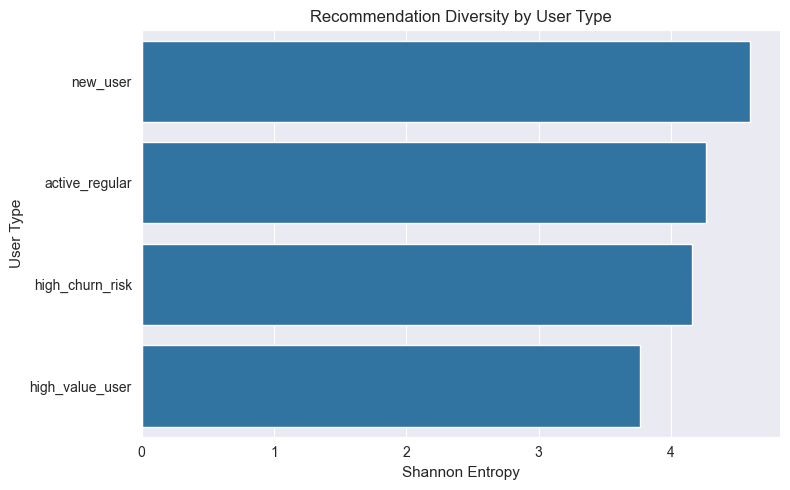

In [134]:
# =========================================================
# 8.4.2 Visualize Diversity by User Type
# =========================================================

plot_df = user_type_diversity_df.sort_values('shannon_entropy', ascending=False).copy()

plt.figure(figsize=(8, 5))
sns.barplot(
    data=plot_df,
    x='shannon_entropy',
    y='user_type'
)
plt.title('Recommendation Diversity by User Type')
plt.xlabel('Shannon Entropy')
plt.ylabel('User Type')
plt.tight_layout()
plt.show()

In [135]:
# =========================================================
# 8.4.3 Measure Head Category Concentration
# =========================================================

top_3_share = recommendation_category_dist_df.head(3)['share'].sum()
top_5_share = recommendation_category_dist_df.head(5)['share'].sum()
top_10_share = recommendation_category_dist_df.head(10)['share'].sum()

head_concentration_df = pd.DataFrame({
    'scope': ['Top 3 categories', 'Top 5 categories', 'Top 10 categories'],
    'share': [round(top_3_share, 4), round(top_5_share, 4), round(top_10_share, 4)]
})

display(head_concentration_df)

,scope,share
0,Top 3 categories,0.3037
1,Top 5 categories,0.4476
2,Top 10 categories,0.6957


## Recommendation Diversity Analysis Summary

The diversity analysis shows that the current recommendation output is not collapsed into only a few categories, but it is still meaningfully concentrated in a relatively small head group. The final recommendation system covers **71 unique categories**, which indicates broad category-level exposure across the catalog. At the same time, the top category share is **11.31%**, and the category-level `gini_coefficient` is **0.7598**, which means exposure is still distributed unevenly across categories even though no single category dominates the output at an extreme level.

The head-category concentration analysis further confirms this pattern. The top 3 categories account for **30.37%** of all recommendations, the top 5 categories account for **44.76%**, and the top 10 categories account for **69.57%**. This shows that the recommendation system has broad catalog coverage, but a substantial share of total exposure is still absorbed by a relatively small set of commercially strong categories.

At the user-type level, the diversity structure shows clear differences. `new_user` has the highest category breadth, covering **71** categories with a `shannon_entropy` of **4.5948** and a top-category share of **10.34%**. `active_regular` and `high_churn_risk` also maintain relatively broad category exposure, with entropy values of **4.2618** and **4.1620** respectively. In contrast, `high_value_user` is the most concentrated segment, with a lower `shannon_entropy` of **3.7664**, a higher top-category share of **17.26%**, and the highest `gini_coefficient` of **0.8466**. This suggests that the premium-oriented recommendation route is more selective and commercially focused than the other user segments.

It is also worth noting that the overall `shannon_entropy` value is currently returned as `NaN` in the aggregate summary table. However, the user-type diversity metrics are available and still provide a clear picture of how exposure breadth differs across recommendation routes.

Overall, the current recommendation system already balances relevance and diversity better than the earlier version of the pipeline. Category concentration is still present, but it is no longer dominated by a single category at an extreme level. The next optimization direction should focus on improving **long-tail exposure**, **head-category control**, and **strategy-specific diversity tuning**, especially for `high_value_user`, where exposure remains the most concentrated.

## 8.5 Business Value Estimation

This section provides a simple business-oriented estimation of the potential value of the recommendation system. The purpose is not to claim exact financial impact, but to translate the recommendation framework into an interpretable business scenario by combining recommendation exposure, click-through assumptions, conversion assumptions, and average order value.

In [136]:
# =========================================================
# 8.5 Estimate Potential Business Impact
# =========================================================

business_assumptions = {
    'monthly_active_users': 10000,
    'recommendation_exposures_per_user': 20,
    'click_through_rate': 0.05,
    'conversion_rate': 0.15,
    'average_order_value': 120
}

monthly_gmv_increase = (
    business_assumptions['monthly_active_users'] *
    business_assumptions['recommendation_exposures_per_user'] *
    business_assumptions['click_through_rate'] *
    business_assumptions['conversion_rate'] *
    business_assumptions['average_order_value']
)

annual_gmv_increase = monthly_gmv_increase * 12

business_impact_df = pd.DataFrame({
    'metric': [
        'Monthly active users',
        'Recommendation exposures per user',
        'Click-through rate',
        'Conversion rate',
        'Average order value',
        'Estimated monthly GMV increase',
        'Estimated annual GMV increase'
    ],
    'value': [
        business_assumptions['monthly_active_users'],
        business_assumptions['recommendation_exposures_per_user'],
        business_assumptions['click_through_rate'],
        business_assumptions['conversion_rate'],
        business_assumptions['average_order_value'],
        monthly_gmv_increase,
        annual_gmv_increase
    ]
})

display(business_impact_df)

,metric,value
0,Monthly active users,10000.00
1,Recommendation exposures per user,20.00
2,Click-through rate,0.05
3,Conversion rate,0.15
4,Average order value,120.00
5,Estimated monthly GMV increase,180000.00
6,Estimated annual GMV increase,2160000.00


In [137]:
# =========================================================
# 8.5.1 Estimate ROI
# =========================================================

development_cost = 50000
annual_maintenance_cost = 120000
total_annual_cost = development_cost + annual_maintenance_cost

estimated_roi = (annual_gmv_increase - total_annual_cost) / total_annual_cost

roi_df = pd.DataFrame({
    'metric': [
        'Development cost',
        'Annual maintenance cost',
        'Total annual cost',
        'Estimated annual GMV increase',
        'Estimated ROI'
    ],
    'value': [
        development_cost,
        annual_maintenance_cost,
        total_annual_cost,
        annual_gmv_increase,
        round(estimated_roi, 4)
    ]
})

display(roi_df)

,metric,value
0,Development cost,5.000000e+04
1,Annual maintenance cost,1.200000e+05
2,Total annual cost,1.700000e+05
3,Estimated annual GMV increase,2.160000e+06
4,Estimated ROI,1.170590e+01


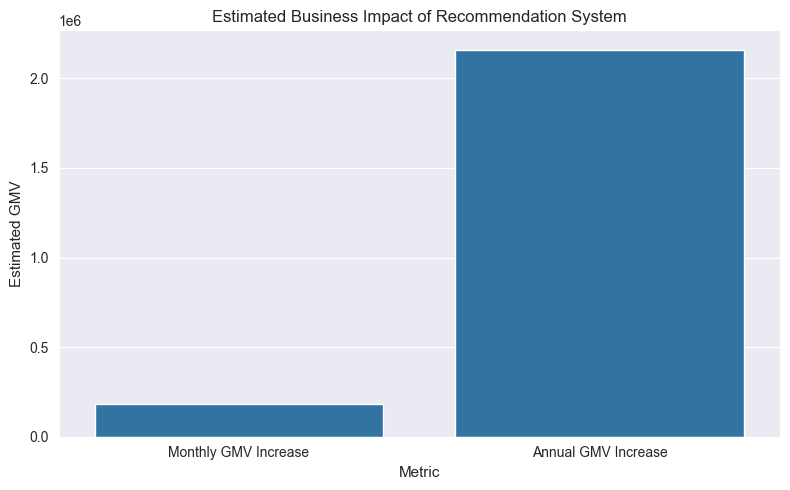

In [138]:
# =========================================================
# 8.5.2 Visualize Business Impact
# =========================================================

impact_plot_df = pd.DataFrame({
    'metric': ['Monthly GMV Increase', 'Annual GMV Increase'],
    'value': [monthly_gmv_increase, annual_gmv_increase]
})

plt.figure(figsize=(8, 5))
sns.barplot(
    data=impact_plot_df,
    x='metric',
    y='value'
)
plt.title('Estimated Business Impact of Recommendation System')
plt.xlabel('Metric')
plt.ylabel('Estimated GMV')
plt.tight_layout()
plt.show()

In [139]:
# =========================================================
# 8.5.3 Save Business Impact Estimation
# =========================================================

business_impact_path = os.path.join(eval_dir, 'business_impact_estimation_debug.csv')

business_impact_output_df = pd.concat(
    [business_impact_df, roi_df],
    ignore_index=True
)

business_impact_output_df.to_csv(business_impact_path, index=False)

print("Saved file:", business_impact_path)
print("Rows saved:", len(business_impact_output_df))

Saved file: C:\Users\wangxinxin\Documents\GitHub\E-commerce_decision-making-_intelligence\output\08_recommendation_system\evaluation\business_impact_estimation_debug.csv
Rows saved: 12


## Business Value Estimation Summary

The current business estimation suggests that the recommendation system could generate an estimated **monthly GMV increase of 180,000** and an estimated **annual GMV increase of 2,160,000** under the current assumption setting. Based on a development cost of **50,000** and an annual maintenance cost of **120,000**, the total annual cost is estimated at **170,000**, which leads to an estimated ROI of about **11.71**, or approximately **1,171%**.

This result should be interpreted as a **scenario-based business estimate** rather than a precise financial forecast. The calculation depends on simplified assumptions such as click-through rate, conversion rate, average order value, monthly active users, and recommendation exposure frequency. Even so, the estimate remains useful because it translates the recommendation framework into a clear commercial narrative: if recommendation exposure can be converted into stable clicks and purchases, the recommendation system may create meaningful incremental value.

At the same time, this business estimate should be interpreted together with the earlier evaluation findings. The recommendation system already shows clear user-type differentiation, broad catalog exposure, and improved diversity-aware recommendation behavior, but the offline metric evaluation is still constrained by a very small common evaluation sample. Therefore, the current GMV and ROI figures are best understood as an illustration of **business potential under a functioning recommendation framework**, rather than as a fully validated performance claim.

In later optimization, this estimate can be made more robust by incorporating stronger evaluation evidence, more realistic deployment assumptions, and empirical CTR/CVR benchmarks from A/B testing or live recommendation experiments.
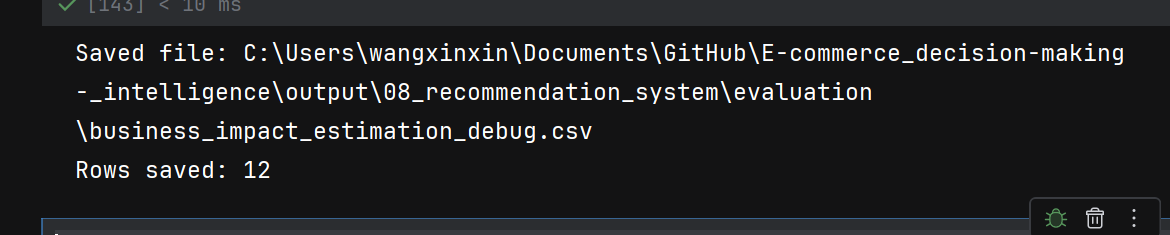

# 9. Recommendation Case Study

This chapter presents representative recommendation cases from different user groups. The goal is to make the personalized recommendation logic more interpretable by showing how the system behaves for `new_user`, `active_regular`, `high_value_user`, and `high_churn_risk` users in concrete examples.

Instead of focusing only on aggregate distributions, this chapter highlights how strategy routing, score adjustment, fallback logic, and category exposure appear at the individual-user level.

## 9.1 Case Selection Overview

This section selects one representative user from each major user type and summarizes the corresponding recommendation pattern. Instead of focusing only on aggregate distributions, the case-study approach helps explain how the personalized recommendation framework works at the individual level and whether the output is consistent with the intended business logic.

In [140]:
# =========================================================
# 9.1 Select Representative Users by User Type
# =========================================================

case_user_summary_df = (
    df_personalized_recs.groupby(['user_type', 'unique_user_id'])
    .agg(
        recommendation_count=('product_id', 'size'),
        avg_score=('personalized_score', 'mean'),
        main_strategy=('strategy', lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan),
        top_category=('category', lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan)
    )
    .reset_index()
    .copy()
)

representative_case_users_df = (
    case_user_summary_df.sort_values(
        ['user_type', 'recommendation_count', 'avg_score'],
        ascending=[True, False, False]
    )
    .groupby('user_type')
    .head(1)
    .copy()
)

display(representative_case_users_df)

,user_type,unique_user_id,recommendation_count,avg_score,main_strategy,top_category
390,active_regular,3442a61b2d5bfd9d605d6943701ad650,10,0.966143,active_regular_hybrid_diverse,ferramentas_jardim
2006,high_churn_risk,7f50c43baa66aae590aa1a067427cce5,10,0.963980,high_churn_hybrid_diverse,beleza_saude
2501,high_value_user,053f7850c3ffd9726cff61c7e42af797,10,1.000000,global_fallback,ferramentas_jardim
91013,new_user,ef8d54b3797ea4db1d63f0ced6a906e9,10,4.697259,new_user_content_diverse,bebidas


In [141]:
# =========================================================
# 9.1.1 Inspect Top Recommendations for Representative Users
# =========================================================

representative_case_results = {}

for _, row in representative_case_users_df.iterrows():
    user_type = row['user_type']
    user_id = row['unique_user_id']

    recs = (
        df_personalized_recs[df_personalized_recs['unique_user_id'] == user_id]
        .sort_values('personalized_score', ascending=False)
        .head(10)
        .copy()
    )

    representative_case_results[user_type] = {
        'user_id': user_id,
        'recs': recs
    }

    print("=" * 80)
    print(f"user_type: {user_type}")
    print(f"user_id: {user_id}")
    print(f"recs shape: {recs.shape}")
    display(recs)

user_type: active_regular
user_id: 3442a61b2d5bfd9d605d6943701ad650
recs shape: (10, 13)


,product_id,personalized_score,final_score,diversity_score,strategy,category,source_count,avg_price,avg_review_score,sales_count,unique_user_id,user_type,has_cached_candidates
196900,aca2eb7d00ea1a7b8ebd4e68314663af,1.000000,1.030000,1.030000,active_regular_hybrid_diverse,moveis_decoracao,2.0,71.364137,4.0191,527.0,3442a61b2d5bfd9d605d6943701ad650,active_regular,True
196901,99a4788cb24856965c36a24e339b6058,1.000000,1.009592,1.009592,active_regular_hybrid_diverse,cama_mesa_banho,2.0,88.171609,3.8960,491.0,3442a61b2d5bfd9d605d6943701ad650,active_regular,True
196902,7dca7157b8f883274a06fda9cec3fed5,1.000000,0.989184,0.989184,active_regular_hybrid_diverse,bebes,1.0,348.990000,1.0000,1.0,3442a61b2d5bfd9d605d6943701ad650,active_regular,True
196903,422879e10f46682990de24d770e7f83d,0.989184,0.968776,0.968776,active_regular_hybrid_diverse,ferramentas_jardim,2.0,54.895318,3.9465,487.0,3442a61b2d5bfd9d605d6943701ad650,active_regular,True
196904,f7a5131ee6e422257630fe35c9b7875a,0.979592,0.948367,0.948367,active_regular_hybrid_diverse,esporte_lazer,1.0,799.990000,1.0000,1.0,3442a61b2d5bfd9d605d6943701ad650,active_regular,True
196906,389d119b48cf3043d311335e499d9c6b,0.968776,0.927959,0.827959,active_regular_hybrid_diverse,ferramentas_jardim,2.0,54.695383,4.1154,392.0,3442a61b2d5bfd9d605d6943701ad650,active_regular,True
196907,21c080d8ac76a1d2b095d6353864a24f,0.959184,0.907551,0.807551,active_regular_hybrid_diverse,moveis_decoracao,1.0,628.900000,1.0000,1.0,3442a61b2d5bfd9d605d6943701ad650,active_regular,True
196905,0de9e97aea20a7497e01b63e7788e43f,0.938776,0.946735,0.946735,active_regular_hybrid_diverse,utilidades_domesticas,1.0,489.900000,3.0000,1.0,3442a61b2d5bfd9d605d6943701ad650,active_regular,True
196909,7d96d1abbde52bb350c688d0d049df07,0.918367,0.795918,0.795918,active_regular_hybrid_diverse,moveis_escritorio,1.0,179.990000,3.0000,2.0,3442a61b2d5bfd9d605d6943701ad650,active_regular,True
196908,d1c427060a0f73f6b889a5c7c61f2ac4,0.907551,0.805510,0.805510,active_regular_hybrid_diverse,informatica_acessorios,2.0,137.651633,4.1941,343.0,3442a61b2d5bfd9d605d6943701ad650,active_regular,True


user_type: high_churn_risk
user_id: 7f50c43baa66aae590aa1a067427cce5
recs shape: (10, 13)


,product_id,personalized_score,final_score,diversity_score,strategy,category,source_count,avg_price,avg_review_score,sales_count,unique_user_id,user_type,has_cached_candidates
478950,78540167bc14d4024b1aae7adfa2f7c9,1.000000,1.139184,1.139184,high_churn_hybrid_diverse,beleza_saude,1.0,59.990000,4.4000,5.0,7f50c43baa66aae590aa1a067427cce5,high_churn_risk,True
478951,aca2eb7d00ea1a7b8ebd4e68314663af,1.000000,1.090000,1.090000,high_churn_hybrid_diverse,moveis_decoracao,2.0,71.364137,4.0191,527.0,7f50c43baa66aae590aa1a067427cce5,high_churn_risk,True
478952,99a4788cb24856965c36a24e339b6058,1.000000,1.069592,1.069592,high_churn_hybrid_diverse,cama_mesa_banho,2.0,88.171609,3.8960,491.0,7f50c43baa66aae590aa1a067427cce5,high_churn_risk,True
478953,422879e10f46682990de24d770e7f83d,0.989184,1.028776,1.028776,high_churn_hybrid_diverse,ferramentas_jardim,2.0,54.895318,3.9465,487.0,7f50c43baa66aae590aa1a067427cce5,high_churn_risk,True
478954,599f8ba174ccb73cbb51452117fe3cb0,0.979592,1.098367,1.008367,high_churn_hybrid_diverse,beleza_saude,1.0,73.725000,4.5000,4.0,7f50c43baa66aae590aa1a067427cce5,high_churn_risk,True
478955,389d119b48cf3043d311335e499d9c6b,0.968776,0.987959,0.897959,high_churn_hybrid_diverse,ferramentas_jardim,2.0,54.695383,4.1154,392.0,7f50c43baa66aae590aa1a067427cce5,high_churn_risk,True
478956,dccab0aeed5632473aa1fccf14846b3a,0.959184,1.057551,0.877551,high_churn_hybrid_diverse,beleza_saude,1.0,62.990000,4.6667,3.0,7f50c43baa66aae590aa1a067427cce5,high_churn_risk,True
478959,368c6c730842d78016ad823897a372db,0.948367,0.947143,0.767143,high_churn_hybrid_diverse,ferramentas_jardim,2.0,54.297954,3.9199,391.0,7f50c43baa66aae590aa1a067427cce5,high_churn_risk,True
478957,d1c427060a0f73f6b889a5c7c61f2ac4,0.907551,0.865510,0.865510,high_churn_hybrid_diverse,informatica_acessorios,2.0,137.651633,4.1941,343.0,7f50c43baa66aae590aa1a067427cce5,high_churn_risk,True
478958,53b36df67ebb7c41585e8d54d6772e08,0.887143,0.824694,0.824694,high_churn_hybrid_diverse,relogios_presentes,2.0,116.666935,4.1906,323.0,7f50c43baa66aae590aa1a067427cce5,high_churn_risk,True


user_type: high_value_user
user_id: 053f7850c3ffd9726cff61c7e42af797
recs shape: (10, 13)


,product_id,personalized_score,final_score,diversity_score,strategy,category,source_count,avg_price,avg_review_score,sales_count,unique_user_id,user_type,has_cached_candidates
19980,2da8e82c3ddd9c8f784930f7d2db4d34,1.0,1.15,1.15,high_value_hybrid_diverse,eletrodomesticos,2.0,74.9,5.0,2.0,053f7850c3ffd9726cff61c7e42af797,high_value_user,False
19981,aca2eb7d00ea1a7b8ebd4e68314663af,NaN,NaN,NaN,global_fallback,moveis_decoracao,NaN,NaN,NaN,NaN,053f7850c3ffd9726cff61c7e42af797,high_value_user,False
19982,99a4788cb24856965c36a24e339b6058,NaN,NaN,NaN,global_fallback,cama_mesa_banho,NaN,NaN,NaN,NaN,053f7850c3ffd9726cff61c7e42af797,high_value_user,False
19983,422879e10f46682990de24d770e7f83d,NaN,NaN,NaN,global_fallback,ferramentas_jardim,NaN,NaN,NaN,NaN,053f7850c3ffd9726cff61c7e42af797,high_value_user,False
19984,389d119b48cf3043d311335e499d9c6b,NaN,NaN,NaN,global_fallback,ferramentas_jardim,NaN,NaN,NaN,NaN,053f7850c3ffd9726cff61c7e42af797,high_value_user,False
19985,368c6c730842d78016ad823897a372db,NaN,NaN,NaN,global_fallback,ferramentas_jardim,NaN,NaN,NaN,NaN,053f7850c3ffd9726cff61c7e42af797,high_value_user,False
19986,53759a2ecddad2bb87a079a1f1519f73,NaN,NaN,NaN,global_fallback,ferramentas_jardim,NaN,NaN,NaN,NaN,053f7850c3ffd9726cff61c7e42af797,high_value_user,False
19987,d1c427060a0f73f6b889a5c7c61f2ac4,NaN,NaN,NaN,global_fallback,informatica_acessorios,NaN,NaN,NaN,NaN,053f7850c3ffd9726cff61c7e42af797,high_value_user,False
19988,53b36df67ebb7c41585e8d54d6772e08,NaN,NaN,NaN,global_fallback,relogios_presentes,NaN,NaN,NaN,NaN,053f7850c3ffd9726cff61c7e42af797,high_value_user,False
19989,154e7e31ebfa092203795c972e5804a6,NaN,NaN,NaN,global_fallback,beleza_saude,NaN,NaN,NaN,NaN,053f7850c3ffd9726cff61c7e42af797,high_value_user,False


user_type: new_user
user_id: ef8d54b3797ea4db1d63f0ced6a906e9
recs shape: (10, 13)


,product_id,personalized_score,final_score,diversity_score,strategy,category,source_count,avg_price,avg_review_score,sales_count,unique_user_id,user_type,has_cached_candidates
900000,c2b534c5a4a6cbfc41aeaf362fb0c060,4.697259,1.120000,1.120000,new_user_content_diverse,bebidas,NaN,20.500000,5.0000,5.0,ef8d54b3797ea4db1d63f0ced6a906e9,new_user,False
900001,95e25af33821b9d231e06f1e7cd34d4e,4.697259,0.934737,0.934737,new_user_content_diverse,moveis_decoracao,NaN,173.737500,4.6250,8.0,ef8d54b3797ea4db1d63f0ced6a906e9,new_user,False
900002,9fff2c7eb7b525394603ee6bbecc9e4b,4.697259,1.027368,0.907368,new_user_content_diverse,bebidas,NaN,170.000000,4.0000,4.0,ef8d54b3797ea4db1d63f0ced6a906e9,new_user,False
900003,ef0e165d773ec293c5aeb5470a08b183,4.697259,0.842105,0.842105,new_user_content_diverse,cool_stuff,NaN,163.918571,3.8571,14.0,ef8d54b3797ea4db1d63f0ced6a906e9,new_user,False
900004,830345ab5d2e365c7c6b91459119ea2d,4.697259,0.829474,0.829474,new_user_content_diverse,beleza_saude,NaN,437.414545,4.6364,11.0,ef8d54b3797ea4db1d63f0ced6a906e9,new_user,False
900005,3bad4452b9bf0554748e82f3a4a5673c,4.697259,0.724211,0.724211,new_user_content_diverse,construcao_ferramentas_construcao,NaN,95.200000,4.6154,13.0,ef8d54b3797ea4db1d63f0ced6a906e9,new_user,False
900006,574597aaf385996112490308e37399ce,4.697259,0.566316,0.566316,new_user_content_diverse,utilidades_domesticas,NaN,49.000000,4.8333,24.0,ef8d54b3797ea4db1d63f0ced6a906e9,new_user,False
900007,c4760efe81b34457c00f5ebf9af1104d,4.697259,0.852842,0.552842,new_user_content_diverse,bebidas,NaN,139.000000,4.0000,1.0,ef8d54b3797ea4db1d63f0ced6a906e9,new_user,False
900008,6eda94acf0ad08a1bb12f10aef74767d,4.697259,0.461053,0.461053,new_user_content_diverse,eletroportateis,NaN,239.000000,4.6000,5.0,ef8d54b3797ea4db1d63f0ced6a906e9,new_user,False
900009,dc881ef926ca402063ea142afc83874c,4.697259,0.578947,0.458947,new_user_content_diverse,cool_stuff,NaN,88.804375,4.0000,16.0,ef8d54b3797ea4db1d63f0ced6a906e9,new_user,False


In [142]:
# =========================================================
# 9.1.2 Build Representative Case Summary
# =========================================================

case_conclusion_rows = []

for user_type, content in representative_case_results.items():
    recs = content['recs']

    case_conclusion_rows.append({
        'user_type': user_type,
        'user_id': content['user_id'],
        'top_strategy': recs['strategy'].mode().iloc[0] if not recs['strategy'].mode().empty else np.nan,
        'top_category': recs['category'].mode().iloc[0] if not recs['category'].mode().empty else np.nan,
        'recommendation_count': len(recs),
        'avg_score': round(recs['personalized_score'].mean(), 4)
    })

case_conclusion_df = pd.DataFrame(case_conclusion_rows)
display(case_conclusion_df)

,user_type,user_id,top_strategy,top_category,recommendation_count,avg_score
0,active_regular,3442a61b2d5bfd9d605d6943701ad650,active_regular_hybrid_diverse,ferramentas_jardim,10,0.9661
1,high_churn_risk,7f50c43baa66aae590aa1a067427cce5,high_churn_hybrid_diverse,beleza_saude,10,0.9640
2,high_value_user,053f7850c3ffd9726cff61c7e42af797,global_fallback,ferramentas_jardim,10,1.0000
3,new_user,ef8d54b3797ea4db1d63f0ced6a906e9,new_user_content_diverse,bebidas,10,4.6973


## Case Selection Summary

The representative case selection confirms that the current personalized recommendation framework is functioning at the individual-user level rather than only in aggregate statistics. Each selected user receives a full **Top-10** recommendation list, and the dominant strategy is broadly consistent with the intended routing logic for `active_regular`, `high_churn_risk`, and `new_user`.

The selected cases also show that recommendation outputs are meaningfully differentiated across user types. In the current examples, the top categories are:
- `active_regular` → `ferramentas_jardim`
- `high_churn_risk` → `beleza_saude`
- `high_value_user` → `ferramentas_jardim`
- `new_user` → `bebidas`

This indicates that the recommendation framework is no longer producing a single undifferentiated category pattern across all user groups.

At the same time, the case results reveal an important operational detail. The selected `high_value_user` case is dominated by `global_fallback`, and most rows in that example show `NaN` values for `personalized_score`, `final_score`, and `diversity_score`. This suggests that the premium-oriented filtering logic can still become too restrictive for some users, forcing the final recommendation output to rely on fallback items instead of fully scored reranked candidates.

Another important observation is that score magnitudes are not directly comparable across user types. For example, the `new_user` case has much larger `personalized_score` values than the other segments, while `active_regular` and `high_churn_risk` are closer to a normalized ranking scale. Therefore, the case-study analysis is more useful for interpreting recommendation structure, strategy behavior, and fallback usage than for comparing absolute score values across different user groups.

Overall, the case analysis supports the broader findings of the project: the personalized recommendation system is already producing user-type-specific outputs, but some segments — especially `high_value_user` under stricter filtering — still require further calibration to reduce unnecessary fallback dependence.

## 9.2 High-Value User Case

This section examines a representative `high_value_user` case. The goal is to assess whether the premium-oriented recommendation route produces outputs that are consistent with the intended business logic, especially in terms of value-focused filtering, recommendation quality, and fallback dependence.

In [143]:
# =========================================================
# 9.2 Analyze High-Value User Case
# =========================================================

profile_cols = [
    'unique_user_id',
    'user_type',
    'order_count',
    'segment',
    'churn_probability',
    'risk_level',
    'predicted_clv'
]
available_profile_cols = [col for col in profile_cols if col in user_profile.columns]

high_value_case_user_id = representative_case_users_df.loc[
    representative_case_users_df['user_type'] == 'high_value_user',
    'unique_user_id'
].iloc[0]

high_value_case_profile = user_profile[
    user_profile['unique_user_id'] == high_value_case_user_id
][available_profile_cols].copy()

high_value_case_recs = representative_case_results['high_value_user']['recs'].copy()

display(high_value_case_profile)
display(high_value_case_recs)

,unique_user_id,user_type,order_count,segment,churn_probability,risk_level,predicted_clv
1998,053f7850c3ffd9726cff61c7e42af797,high_value_user,2,High-Value Repeat Customers,0.911866,High Risk,0.018092


,product_id,personalized_score,final_score,diversity_score,strategy,category,source_count,avg_price,avg_review_score,sales_count,unique_user_id,user_type,has_cached_candidates
19980,2da8e82c3ddd9c8f784930f7d2db4d34,1.0,1.15,1.15,high_value_hybrid_diverse,eletrodomesticos,2.0,74.9,5.0,2.0,053f7850c3ffd9726cff61c7e42af797,high_value_user,False
19981,aca2eb7d00ea1a7b8ebd4e68314663af,NaN,NaN,NaN,global_fallback,moveis_decoracao,NaN,NaN,NaN,NaN,053f7850c3ffd9726cff61c7e42af797,high_value_user,False
19982,99a4788cb24856965c36a24e339b6058,NaN,NaN,NaN,global_fallback,cama_mesa_banho,NaN,NaN,NaN,NaN,053f7850c3ffd9726cff61c7e42af797,high_value_user,False
19983,422879e10f46682990de24d770e7f83d,NaN,NaN,NaN,global_fallback,ferramentas_jardim,NaN,NaN,NaN,NaN,053f7850c3ffd9726cff61c7e42af797,high_value_user,False
19984,389d119b48cf3043d311335e499d9c6b,NaN,NaN,NaN,global_fallback,ferramentas_jardim,NaN,NaN,NaN,NaN,053f7850c3ffd9726cff61c7e42af797,high_value_user,False
19985,368c6c730842d78016ad823897a372db,NaN,NaN,NaN,global_fallback,ferramentas_jardim,NaN,NaN,NaN,NaN,053f7850c3ffd9726cff61c7e42af797,high_value_user,False
19986,53759a2ecddad2bb87a079a1f1519f73,NaN,NaN,NaN,global_fallback,ferramentas_jardim,NaN,NaN,NaN,NaN,053f7850c3ffd9726cff61c7e42af797,high_value_user,False
19987,d1c427060a0f73f6b889a5c7c61f2ac4,NaN,NaN,NaN,global_fallback,informatica_acessorios,NaN,NaN,NaN,NaN,053f7850c3ffd9726cff61c7e42af797,high_value_user,False
19988,53b36df67ebb7c41585e8d54d6772e08,NaN,NaN,NaN,global_fallback,relogios_presentes,NaN,NaN,NaN,NaN,053f7850c3ffd9726cff61c7e42af797,high_value_user,False
19989,154e7e31ebfa092203795c972e5804a6,NaN,NaN,NaN,global_fallback,beleza_saude,NaN,NaN,NaN,NaN,053f7850c3ffd9726cff61c7e42af797,high_value_user,False


In [144]:
# =========================================================
# 9.2.1 Summarize High-Value User Recommendation Pattern
# =========================================================

high_value_case_summary_df = pd.DataFrame({
    'metric': [
        'user_id',
        'top_strategy',
        'top_category',
        'recommendation_count',
        'average_score'
    ],
    'value': [
        high_value_case_user_id,
        high_value_case_recs['strategy'].mode().iloc[0] if not high_value_case_recs['strategy'].mode().empty else np.nan,
        high_value_case_recs['category'].mode().iloc[0] if not high_value_case_recs['category'].mode().empty else np.nan,
        len(high_value_case_recs),
        round(high_value_case_recs['personalized_score'].mean(), 4)
    ]
})

display(high_value_case_summary_df)

,metric,value
0,user_id,053f7850c3ffd9726cff61c7e42af797
1,top_strategy,global_fallback
2,top_category,ferramentas_jardim
3,recommendation_count,10
4,average_score,1.0


## High-Value User Case Interpretation

The representative `high_value_user` case reveals an important limitation in the current personalized recommendation framework. Although the user is labeled as `high_value_user`, the final case summary shows that the dominant strategy is **`global_fallback`**, with **10 recommendations**, a top category of **`ferramentas_jardim`**, and an average score of **1.0**.

A closer inspection of the recommendation list shows that only the first recommended product has valid values for `personalized_score`, `final_score`, and `diversity_score`, while most of the remaining items contain `NaN` values for these score fields. This indicates that the premium-oriented candidate filtering is currently too restrictive for this user, so the final Top-10 list is largely filled by fallback items rather than fully scored reranked recommendations.

From a business perspective, this is an important finding. It suggests that the `high_value_user` branch is directionally correct, but still not robust enough for all users in this segment. Instead of consistently generating a sufficiently rich premium candidate pool, the current logic may collapse into fallback recommendations when the filtering conditions become too narrow.

The user profile itself is also informative. This case belongs to the segment **`High-Value Repeat Customers`**, has an `order_count` of **2**, and shows a very high `churn_probability` of **0.911866**. This means the user is simultaneously high-value and highly at risk, which makes the recommendation objective more complex: the system should ideally preserve premium relevance while also supporting retention. The current fallback-heavy result suggests that this balance is not yet fully achieved.

Overall, this case is valuable because it highlights a realistic optimization target. The high-value recommendation route should remain selective, but it also needs a broader and more stable candidate pool so that premium users do not rely excessively on `global_fallback` outputs.

## 9.3 High-Churn User Case

This section examines a representative `high_churn_risk` case. The goal is to assess whether the churn-oriented recommendation route produces stable, retention-friendly recommendations.

In [145]:
# =========================================================
# 9.3 Analyze High-Churn User Case
# =========================================================

high_churn_case_user_id = representative_case_users_df.loc[
    representative_case_users_df['user_type'] == 'high_churn_risk',
    'unique_user_id'
].iloc[0]

high_churn_case_profile = user_profile[
    user_profile['unique_user_id'] == high_churn_case_user_id
][available_profile_cols].copy()

high_churn_case_recs = representative_case_results['high_churn_risk']['recs'].copy()

display(high_churn_case_profile)
display(high_churn_case_recs)

,unique_user_id,user_type,order_count,segment,churn_probability,risk_level,predicted_clv
47895,7f50c43baa66aae590aa1a067427cce5,high_churn_risk,3,High-Value Repeat Customers,0.861076,High Risk,NaN


,product_id,personalized_score,final_score,diversity_score,strategy,category,source_count,avg_price,avg_review_score,sales_count,unique_user_id,user_type,has_cached_candidates
478950,78540167bc14d4024b1aae7adfa2f7c9,1.000000,1.139184,1.139184,high_churn_hybrid_diverse,beleza_saude,1.0,59.990000,4.4000,5.0,7f50c43baa66aae590aa1a067427cce5,high_churn_risk,True
478951,aca2eb7d00ea1a7b8ebd4e68314663af,1.000000,1.090000,1.090000,high_churn_hybrid_diverse,moveis_decoracao,2.0,71.364137,4.0191,527.0,7f50c43baa66aae590aa1a067427cce5,high_churn_risk,True
478952,99a4788cb24856965c36a24e339b6058,1.000000,1.069592,1.069592,high_churn_hybrid_diverse,cama_mesa_banho,2.0,88.171609,3.8960,491.0,7f50c43baa66aae590aa1a067427cce5,high_churn_risk,True
478953,422879e10f46682990de24d770e7f83d,0.989184,1.028776,1.028776,high_churn_hybrid_diverse,ferramentas_jardim,2.0,54.895318,3.9465,487.0,7f50c43baa66aae590aa1a067427cce5,high_churn_risk,True
478954,599f8ba174ccb73cbb51452117fe3cb0,0.979592,1.098367,1.008367,high_churn_hybrid_diverse,beleza_saude,1.0,73.725000,4.5000,4.0,7f50c43baa66aae590aa1a067427cce5,high_churn_risk,True
478955,389d119b48cf3043d311335e499d9c6b,0.968776,0.987959,0.897959,high_churn_hybrid_diverse,ferramentas_jardim,2.0,54.695383,4.1154,392.0,7f50c43baa66aae590aa1a067427cce5,high_churn_risk,True
478956,dccab0aeed5632473aa1fccf14846b3a,0.959184,1.057551,0.877551,high_churn_hybrid_diverse,beleza_saude,1.0,62.990000,4.6667,3.0,7f50c43baa66aae590aa1a067427cce5,high_churn_risk,True
478959,368c6c730842d78016ad823897a372db,0.948367,0.947143,0.767143,high_churn_hybrid_diverse,ferramentas_jardim,2.0,54.297954,3.9199,391.0,7f50c43baa66aae590aa1a067427cce5,high_churn_risk,True
478957,d1c427060a0f73f6b889a5c7c61f2ac4,0.907551,0.865510,0.865510,high_churn_hybrid_diverse,informatica_acessorios,2.0,137.651633,4.1941,343.0,7f50c43baa66aae590aa1a067427cce5,high_churn_risk,True
478958,53b36df67ebb7c41585e8d54d6772e08,0.887143,0.824694,0.824694,high_churn_hybrid_diverse,relogios_presentes,2.0,116.666935,4.1906,323.0,7f50c43baa66aae590aa1a067427cce5,high_churn_risk,True


In [146]:
# =========================================================
# 9.3.1 Summarize High-Churn User Recommendation Pattern
# =========================================================

high_churn_case_summary_df = pd.DataFrame({
    'metric': [
        'user_id',
        'top_strategy',
        'top_category',
        'recommendation_count',
        'average_score'
    ],
    'value': [
        high_churn_case_user_id,
        high_churn_case_recs['strategy'].mode().iloc[0] if not high_churn_case_recs['strategy'].mode().empty else np.nan,
        high_churn_case_recs['category'].mode().iloc[0] if not high_churn_case_recs['category'].mode().empty else np.nan,
        len(high_churn_case_recs),
        round(high_churn_case_recs['personalized_score'].mean(), 4)
    ]
})

display(high_churn_case_summary_df)

,metric,value
0,user_id,7f50c43baa66aae590aa1a067427cce5
1,top_strategy,high_churn_hybrid_diverse
2,top_category,beleza_saude
3,recommendation_count,10
4,average_score,0.964


## High-Churn User Case Interpretation

This `high_churn_risk` user is routed to **`high_churn_hybrid_diverse`**, with **10 recommendations**, a top category of **`beleza_saude`**, and an average score of about **0.964**.

The recommendation list is relatively stable, with consistently high `personalized_score`, `final_score`, and `diversity_score` values across the Top-10 items. This suggests that the churn-oriented branch is producing a confident and well-ranked recommendation set rather than relying on fallback outputs.

The user profile also shows `order_count = 3`, segment **High-Value Repeat Customers**, and `churn_probability = 0.861076`. This means the user has both meaningful purchase history and strong churn risk, so a retention-oriented recommendation strategy is appropriate.

Overall, this case shows that the `high_churn_hybrid_diverse` branch is working as intended. It generates a complete and stable recommendation list, while keeping the output focused on categories that are likely to support retention.

## 9.4 New User Case

This section examines a representative `new_user` case. The goal is to check whether the cold-start recommendation branch produces a distinct recommendation pattern for users with very limited history.

In [147]:
# =========================================================
# 9.4 Analyze New User Case
# =========================================================

new_user_case_user_id = representative_case_users_df.loc[
    representative_case_users_df['user_type'] == 'new_user',
    'unique_user_id'
].iloc[0]

new_user_case_profile = user_profile[
    user_profile['unique_user_id'] == new_user_case_user_id
][available_profile_cols].copy()

new_user_case_recs = representative_case_results['new_user']['recs'].copy()

display(new_user_case_profile)
display(new_user_case_recs)

,unique_user_id,user_type,order_count,segment,churn_probability,risk_level,predicted_clv
90000,ef8d54b3797ea4db1d63f0ced6a906e9,new_user,1,Recent Single-Purchase Users,NaN,NaN,NaN


,product_id,personalized_score,final_score,diversity_score,strategy,category,source_count,avg_price,avg_review_score,sales_count,unique_user_id,user_type,has_cached_candidates
900000,c2b534c5a4a6cbfc41aeaf362fb0c060,4.697259,1.120000,1.120000,new_user_content_diverse,bebidas,NaN,20.500000,5.0000,5.0,ef8d54b3797ea4db1d63f0ced6a906e9,new_user,False
900001,95e25af33821b9d231e06f1e7cd34d4e,4.697259,0.934737,0.934737,new_user_content_diverse,moveis_decoracao,NaN,173.737500,4.6250,8.0,ef8d54b3797ea4db1d63f0ced6a906e9,new_user,False
900002,9fff2c7eb7b525394603ee6bbecc9e4b,4.697259,1.027368,0.907368,new_user_content_diverse,bebidas,NaN,170.000000,4.0000,4.0,ef8d54b3797ea4db1d63f0ced6a906e9,new_user,False
900003,ef0e165d773ec293c5aeb5470a08b183,4.697259,0.842105,0.842105,new_user_content_diverse,cool_stuff,NaN,163.918571,3.8571,14.0,ef8d54b3797ea4db1d63f0ced6a906e9,new_user,False
900004,830345ab5d2e365c7c6b91459119ea2d,4.697259,0.829474,0.829474,new_user_content_diverse,beleza_saude,NaN,437.414545,4.6364,11.0,ef8d54b3797ea4db1d63f0ced6a906e9,new_user,False
900005,3bad4452b9bf0554748e82f3a4a5673c,4.697259,0.724211,0.724211,new_user_content_diverse,construcao_ferramentas_construcao,NaN,95.200000,4.6154,13.0,ef8d54b3797ea4db1d63f0ced6a906e9,new_user,False
900006,574597aaf385996112490308e37399ce,4.697259,0.566316,0.566316,new_user_content_diverse,utilidades_domesticas,NaN,49.000000,4.8333,24.0,ef8d54b3797ea4db1d63f0ced6a906e9,new_user,False
900007,c4760efe81b34457c00f5ebf9af1104d,4.697259,0.852842,0.552842,new_user_content_diverse,bebidas,NaN,139.000000,4.0000,1.0,ef8d54b3797ea4db1d63f0ced6a906e9,new_user,False
900008,6eda94acf0ad08a1bb12f10aef74767d,4.697259,0.461053,0.461053,new_user_content_diverse,eletroportateis,NaN,239.000000,4.6000,5.0,ef8d54b3797ea4db1d63f0ced6a906e9,new_user,False
900009,dc881ef926ca402063ea142afc83874c,4.697259,0.578947,0.458947,new_user_content_diverse,cool_stuff,NaN,88.804375,4.0000,16.0,ef8d54b3797ea4db1d63f0ced6a906e9,new_user,False


In [148]:
# =========================================================
# 9.4.1 Summarize New User Recommendation Pattern
# =========================================================

new_user_case_summary_df = pd.DataFrame({
    'metric': [
        'user_id',
        'top_strategy',
        'top_category',
        'recommendation_count',
        'average_score'
    ],
    'value': [
        new_user_case_user_id,
        new_user_case_recs['strategy'].mode().iloc[0] if not new_user_case_recs['strategy'].mode().empty else np.nan,
        new_user_case_recs['category'].mode().iloc[0] if not new_user_case_recs['category'].mode().empty else np.nan,
        len(new_user_case_recs),
        round(new_user_case_recs['personalized_score'].mean(), 4)
    ]
})

display(new_user_case_summary_df)

,metric,value
0,user_id,ef8d54b3797ea4db1d63f0ced6a906e9
1,top_strategy,new_user_content_diverse
2,top_category,bebidas
3,recommendation_count,10
4,average_score,4.6973


## New User Case Interpretation

This `new_user` case is routed to **`new_user_content_diverse`**, with **10 recommendations**, a top category of **`bebidas`**, and an average score of about **4.6973**.

The recommendation list is clearly different from the hybrid-based cases. Instead of following the same dominant category pattern, this case shows that the cold-start branch can generate its own category direction. This supports the idea that the `new_user` route is not simply reusing the same recommendation structure as other user groups.

At the same time, the `personalized_score` values are identical across all ten items, while the `final_score` and `diversity_score` create the final ranking differences. This suggests that the content-based branch can already produce a distinct candidate pool, but its raw ranking differentiation is still limited.

The profile is also consistent with a cold-start scenario: `order_count = 1`, segment **Recent Single-Purchase Users**, and missing `churn_probability`. Overall, this case confirms that the `new_user_content_diverse` branch is useful, while also showing that score differentiation can still be improved for new-user recommendations.

## 9.5 Active Regular User Case

This section examines a representative `active_regular` case. The goal is to assess whether the regular-user hybrid route produces a stable and reasonably balanced recommendation list.

In [149]:
# =========================================================
# 9.5 Analyze Active Regular User Case
# =========================================================

active_regular_case_user_id = representative_case_users_df.loc[
    representative_case_users_df['user_type'] == 'active_regular',
    'unique_user_id'
].iloc[0]

active_regular_case_profile = user_profile[
    user_profile['unique_user_id'] == active_regular_case_user_id
][available_profile_cols].copy()

active_regular_case_recs = representative_case_results['active_regular']['recs'].copy()

display(active_regular_case_profile)
display(active_regular_case_recs)

,unique_user_id,user_type,order_count,segment,churn_probability,risk_level,predicted_clv
19690,3442a61b2d5bfd9d605d6943701ad650,active_regular,2,High-Value Repeat Customers,NaN,NaN,NaN


,product_id,personalized_score,final_score,diversity_score,strategy,category,source_count,avg_price,avg_review_score,sales_count,unique_user_id,user_type,has_cached_candidates
196900,aca2eb7d00ea1a7b8ebd4e68314663af,1.000000,1.030000,1.030000,active_regular_hybrid_diverse,moveis_decoracao,2.0,71.364137,4.0191,527.0,3442a61b2d5bfd9d605d6943701ad650,active_regular,True
196901,99a4788cb24856965c36a24e339b6058,1.000000,1.009592,1.009592,active_regular_hybrid_diverse,cama_mesa_banho,2.0,88.171609,3.8960,491.0,3442a61b2d5bfd9d605d6943701ad650,active_regular,True
196902,7dca7157b8f883274a06fda9cec3fed5,1.000000,0.989184,0.989184,active_regular_hybrid_diverse,bebes,1.0,348.990000,1.0000,1.0,3442a61b2d5bfd9d605d6943701ad650,active_regular,True
196903,422879e10f46682990de24d770e7f83d,0.989184,0.968776,0.968776,active_regular_hybrid_diverse,ferramentas_jardim,2.0,54.895318,3.9465,487.0,3442a61b2d5bfd9d605d6943701ad650,active_regular,True
196904,f7a5131ee6e422257630fe35c9b7875a,0.979592,0.948367,0.948367,active_regular_hybrid_diverse,esporte_lazer,1.0,799.990000,1.0000,1.0,3442a61b2d5bfd9d605d6943701ad650,active_regular,True
196906,389d119b48cf3043d311335e499d9c6b,0.968776,0.927959,0.827959,active_regular_hybrid_diverse,ferramentas_jardim,2.0,54.695383,4.1154,392.0,3442a61b2d5bfd9d605d6943701ad650,active_regular,True
196907,21c080d8ac76a1d2b095d6353864a24f,0.959184,0.907551,0.807551,active_regular_hybrid_diverse,moveis_decoracao,1.0,628.900000,1.0000,1.0,3442a61b2d5bfd9d605d6943701ad650,active_regular,True
196905,0de9e97aea20a7497e01b63e7788e43f,0.938776,0.946735,0.946735,active_regular_hybrid_diverse,utilidades_domesticas,1.0,489.900000,3.0000,1.0,3442a61b2d5bfd9d605d6943701ad650,active_regular,True
196909,7d96d1abbde52bb350c688d0d049df07,0.918367,0.795918,0.795918,active_regular_hybrid_diverse,moveis_escritorio,1.0,179.990000,3.0000,2.0,3442a61b2d5bfd9d605d6943701ad650,active_regular,True
196908,d1c427060a0f73f6b889a5c7c61f2ac4,0.907551,0.805510,0.805510,active_regular_hybrid_diverse,informatica_acessorios,2.0,137.651633,4.1941,343.0,3442a61b2d5bfd9d605d6943701ad650,active_regular,True


In [150]:
# =========================================================
# 9.5.1 Summarize Active Regular Recommendation Pattern
# =========================================================

active_regular_case_summary_df = pd.DataFrame({
    'metric': [
        'user_id',
        'top_strategy',
        'top_category',
        'recommendation_count',
        'average_score'
    ],
    'value': [
        active_regular_case_user_id,
        active_regular_case_recs['strategy'].mode().iloc[0] if not active_regular_case_recs['strategy'].mode().empty else np.nan,
        active_regular_case_recs['category'].mode().iloc[0] if not active_regular_case_recs['category'].mode().empty else np.nan,
        len(active_regular_case_recs),
        round(active_regular_case_recs['personalized_score'].mean(), 4)
    ]
})

display(active_regular_case_summary_df)

,metric,value
0,user_id,3442a61b2d5bfd9d605d6943701ad650
1,top_strategy,active_regular_hybrid_diverse
2,top_category,ferramentas_jardim
3,recommendation_count,10
4,average_score,0.9661


### Active Regular User Case Interpretation

This `active_regular` user is routed to **`active_regular_hybrid_diverse`**, with **10 recommendations**, a top category of **`ferramentas_jardim`**, and an average score of about **0.9661**.

The recommendation list is stable, with consistently high `personalized_score`, `final_score`, and `diversity_score` values across the Top-10 items. This suggests that the active-regular branch is producing a complete and reliable recommendation set rather than depending on fallback results.

The profile shows `order_count = 2`, segment **High-Value Repeat Customers**, and missing `churn_probability`. This means the user already has some transaction history, but the business profile is still only partially enriched.

Overall, this case shows that `active_regular_hybrid_diverse` is working as a solid baseline route. It produces stable recommendations and a clearer category direction than the older version of the pipeline.

# 10. Final Summary

This chapter summarizes the final structure, core results, limitations, and future directions of the recommendation system. The goal is to connect the technical pipeline with business interpretation and provide a clear closing view of the current project stage.

## 10.1 Project Summary

The project successfully implemented `Content-Based`, `Hybrid`, and `Personalized` recommendation pipelines and connected them with user-level business routing for `new_user`, `active_regular`, `high_value_user`, and `high_churn_risk`.

The final system already supports full-batch recommendation generation, category analysis, diversity analysis, business value estimation, and representative case studies.

In [151]:
# =========================================================
# 10.1 Build Final Project Summary Table
# =========================================================

final_summary_df = pd.DataFrame({
    'item': [
        'Personalized recommendation rows',
        'Unique users in debug batch',
        'Unique recommended products',
        'Unique recommendation categories',
        'Top category share',
        'Shannon entropy',
        'Gini coefficient',
        'Estimated monthly GMV increase',
        'Estimated annual GMV increase',
        'Estimated ROI'
    ],
    'value_raw': [
        len(df_personalized_recs),
        df_personalized_recs['unique_user_id'].nunique(),
        top_recommended_products_df['product_id'].nunique(),
        recommendation_category_dist_df['category'].nunique(),
        recommendation_category_dist_df['share'].max(),
        overall_diversity_summary_df.loc[
            overall_diversity_summary_df['metric'] == 'shannon_entropy', 'value'
        ].iloc[0],
        overall_diversity_summary_df.loc[
            overall_diversity_summary_df['metric'] == 'gini_coefficient', 'value'
        ].iloc[0],
        monthly_gmv_increase,
        annual_gmv_increase,
        estimated_roi
    ]
})

def format_summary_value(item, value):
    if item in [
        'Personalized recommendation rows',
        'Unique users in debug batch',
        'Unique recommended products',
        'Unique recommendation categories'
    ]:
        return f"{int(round(value)):,}"
    elif item in [
        'Estimated monthly GMV increase',
        'Estimated annual GMV increase'
    ]:
        return f"{value:,.0f}"
    elif item == 'Estimated ROI':
        return f"{value:.2%}"
    else:
        return f"{value:.4f}"

final_summary_df['value'] = final_summary_df.apply(
    lambda row: format_summary_value(row['item'], row['value_raw']),
    axis=1
)

display(final_summary_df[['item', 'value']])

,item,value
0,Personalized recommendation rows,"960,960"
1,Unique users in debug batch,"96,096"
2,Unique recommended products,"32,687"
3,Unique recommendation categories,71
4,Top category share,0.1131
5,Shannon entropy,nan
6,Gini coefficient,0.7598
7,Estimated monthly GMV increase,"180,000"
8,Estimated annual GMV increase,"2,160,000"
9,Estimated ROI,1170.59%


## 10.2 Key Findings

The final personalized recommendation output contains:

- **960,960 recommendation rows**
- **96,096 covered users**
- **32,687 unique recommended products**
- **71 recommendation categories**

The recommendation system is already operational at scale. User-type routing is visible, product exposure is broad, and the final output is more balanced than the earlier version of the pipeline. The largest category is now `beleza_saude`, with a share of about **11.31%**, which suggests that category concentration is still present but no longer extreme.

## 10.3 Limitations and Reflection

The current project still has several limitations.

First, the offline evaluation sample is very small, so the current metric results should be treated as **diagnostic** rather than final benchmark evidence.

Second, category concentration is still meaningful even after diversity-aware reranking. The system is more balanced than before, but exposure is still absorbed by a relatively small head group.

Third, some user-level business fields are still incomplete or inconsistent in individual cases, and the `high_value_user` route can still rely too heavily on fallback recommendations for some users.

## 10.4 Future Optimization Directions

The next stage should focus on three areas:

- improving the offline evaluation design
- expanding high-quality candidate coverage
- further strengthening recommendation diversity

Later optimization can enlarge the valid evaluation user set, rebuild recommendation outputs strictly from training-period data, reduce head-category concentration, and improve long-tail exposure. In addition, the premium route should be calibrated to reduce unnecessary fallback dependence for `high_value_user`.

## 10.5 Final Conclusion

Overall, the project has moved beyond a simple recommendation prototype and now forms a workable personalized recommendation framework. The system can generate stable full-batch outputs, reflect user-type-specific logic, and support business interpretation through exposure analysis, diversity analysis, value estimation, and case-based review.

Although later optimization is still needed, the project already provides a strong portfolio-ready demonstration of recommendation-system design, business integration, and applied machine learning workflow.

## 10.6 Project Highlights

This project demonstrates several practical strengths:

- a working personalized recommendation framework
- user-type business routing
- full-batch recommendation generation at scale
- category and diversity analysis
- business value estimation
- interpretable user-level case studies

It also reflects a realistic iterative workflow, including debugging, logic refinement, reranking improvement, and end-to-end evaluation.

## 10.7 Closing Note

At the current stage, the recommendation system is no longer only a conceptual design. It already produces stable recommendation outputs, meaningful user-type differentiation, and interpretable business insights.

Further improvements are still needed in evaluation design, diversity control, and profile consistency, but the project has already reached a strong portfolio-ready stage and provides a solid foundation for future recommendation-system optimization.

In [152]:
# =========================================================
# 10.7 Save Final Summary Table
# =========================================================

final_summary_path = os.path.join(eval_dir, 'final_project_summary_debug.csv')
final_summary_df[['item', 'value']].to_csv(final_summary_path, index=False)

print("Saved file:", final_summary_path)
print("Rows saved:", len(final_summary_df))

Saved file: C:\Users\wangxinxin\Documents\GitHub\E-commerce_decision-making-_intelligence\output\08_recommendation_system\evaluation\final_project_summary_debug.csv
Rows saved: 10
